In [1]:
## 0. Environment & Data Setup

In [2]:
from pathlib import Path
import os

IN_COLAB = Path("/content").exists()

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    DATA_ROOT = Path(
        "/content/drive/MyDrive/MT-Hackathon-2026/data"
    )
else:
    # notebook находится в ml/notebooks/
    DATA_ROOT = Path("../../data").resolve()

print("Environment:", "Colab" if IN_COLAB else "Local")
print("DATA_ROOT:", DATA_ROOT)

Environment: Local
DATA_ROOT: D:\Development\Projects\MT-Hackathon-2026\data


In [3]:
RAW_DIR = DATA_ROOT / "raw"
LABELS_DIR = RAW_DIR / "labels"

LABELS_TRAIN_PATH = LABELS_DIR / "labels_day_train.csv"
LABELS_TEST_PATH = LABELS_DIR / "labels_day_test.csv"

In [4]:
paths = [LABELS_TRAIN_PATH, LABELS_TEST_PATH]

for path in paths:
    print(path.name, "->", path.exists())

labels_day_train.csv -> True
labels_day_test.csv -> True


In [5]:
import pandas as pd

ROUTES = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)
KEYS = ["route", "date", "hour"]

labels_train = pd.read_csv(LABELS_TRAIN_PATH, sep=";", parse_dates=["date"])
labels_test = pd.read_csv(LABELS_TEST_PATH, sep=";", parse_dates=["date"])

def make_hourly_grid(start, end, sparse_labels):
    dates = pd.date_range(start=start, end=end, freq="D")
    grid = pd.MultiIndex.from_product(
        [ROUTES, dates, range(24)], names=KEYS
    ).to_frame(index=False)
    observed = sparse_labels.loc[
        sparse_labels["date"].between(pd.Timestamp(start), pd.Timestamp(end)),
        KEYS + ["boardings"],
    ].copy()
    if observed.duplicated(KEYS).any():
        raise ValueError("Duplicate historical label keys")
    hourly = grid.merge(observed, on=KEYS, how="left", validate="one_to_one")
    hourly["boardings"] = hourly["boardings"].fillna(0).astype("int64")
    return hourly

train_hourly = make_hourly_grid("2025-01-01", "2025-08-31", labels_train)
valid_hourly = make_hourly_grid("2025-09-01", "2025-10-31", labels_test)

if len(train_hourly) != 58_320 or len(valid_hourly) != 14_640:
    raise ValueError("Unexpected organizer-label grid size")
if train_hourly["date"].max() >= valid_hourly["date"].min():
    raise ValueError("Training and validation periods overlap")


In [6]:
print("train_hourly grid:", train_hourly.shape)
print("valid_hourly grid:", valid_hourly.shape)
print("labels_train sparse:", labels_train.shape)
print("labels_test sparse:", labels_test.shape)
print("Train period:", train_hourly["date"].min().date(), "to", train_hourly["date"].max().date())
print("Validation period:", valid_hourly["date"].min().date(), "to", valid_hourly["date"].max().date())

train_hourly grid: (58320, 4)
valid_hourly grid: (14640, 4)
labels_train sparse: (46234, 4)
labels_test sparse: (11317, 4)
Train period: 2025-01-01 to 2025-08-31
Validation period: 2025-09-01 to 2025-10-31


**ВАЖНО:**
**Ниже не указывайте абсолютные пути Colab/Google Drive.**
**Используйте DATA_ROOT, переменные *_PATH или уже загруженные DataFrames.**

## 1. Frozen LightGBM baseline

Эта секция воспроизводит текущий baseline из `ml/src/lightgbm_baseline.py` и служит неизменяемым эталоном для последующих feature experiments.

| Параметр | Зафиксированный эталон |
|---|---|
| Целевая переменная / единица | `boardings` на `(route, date, hour)` |
| Обучение | январь–август 2025, 58 320 часовых строк |
| Временная валидация | сентябрь–октябрь 2025, непрерывный holdout, 14 640 строк |
| Признаки baseline | `route`, `weekday`, `hour` |
| Предобработка | все три признаки — `pandas.Categorical`; категории: маршруты `(1, 5, 7, 11, 12, 17, 25, 26, 28, 50)`, weekday `0…6`, hour `0…23` |
| LightGBM | `objective="regression_l1"`, `n_estimators=300`, `max_depth=6`, `num_leaves=31`, `learning_rate=0.1`, `random_state=42`, `n_jobs=4`, `verbosity=-1`; прочие параметры — по умолчанию |
| Постобработка | `floor(max(prediction, 0) + 0.5)` |
| Метрика | `WAPE = sum(abs(actual − prediction)) / sum(actual)` |

CSV загружаются через пути из `Environment & Data Setup` и с разделителем `;`. Фактический target validation открывается после построения полного прогноза. Эксперименты с признаками должны сохранять этот baseline, меняя только добавляемые признаки. Результаты появятся после запуска ячеек в Colab.

In [7]:
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor

FROZEN_ROUTES = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)
FROZEN_FEATURES = ("route", "weekday", "hour")

frozen_train = train_hourly.copy()
frozen_validation_keys = valid_hourly[["route", "date", "hour"]].copy()
if len(frozen_train) != 58_320 or len(frozen_validation_keys) != 14_640:
    raise ValueError("Unexpected hourly grid size")
if frozen_train["date"].max() >= frozen_validation_keys["date"].min():
    raise ValueError("Training and validation periods overlap")

def frozen_calendar_features(rows):
    return pd.DataFrame(
        {
            "route": pd.Categorical(rows["route"], categories=FROZEN_ROUTES),
            "weekday": pd.Categorical(rows["date"].dt.weekday, categories=range(7)),
            "hour": pd.Categorical(rows["hour"], categories=range(24)),
        }
    )

In [8]:
frozen_model = LGBMRegressor(
    objective="regression_l1",
    n_estimators=300,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.1,
    random_state=42,
    n_jobs=4,
    verbosity=-1,
)
frozen_model.fit(
    frozen_calendar_features(frozen_train),
    frozen_train["boardings"],
    categorical_feature=list(FROZEN_FEATURES),
)

frozen_predictions = np.floor(
    np.maximum(frozen_model.predict(frozen_calendar_features(frozen_validation_keys)), 0) + 0.5
)

# Open holdout targets only after the full forecast has been generated.
frozen_actual = valid_hourly["boardings"].to_numpy()
if (
    len(frozen_actual) != len(frozen_predictions)
    or frozen_actual.sum() == 0
    or not np.isfinite(frozen_predictions).all()
):
    raise ValueError("Invalid validation targets or predictions")

frozen_absolute_error = np.abs(frozen_actual - frozen_predictions)
frozen_overall_wape = frozen_absolute_error.sum() / frozen_actual.sum()
print(f"Frozen baseline overall WAPE: {frozen_overall_wape:.6f}")

frozen_route_metrics = pd.DataFrame(
    {
        "route": frozen_validation_keys["route"],
        "actual": frozen_actual,
        "absolute_error": frozen_absolute_error,
    }
).groupby("route").agg(
    actual=("actual", "sum"),
    absolute_error=("absolute_error", "sum"),
)
frozen_route_metrics["WAPE"] = (
    frozen_route_metrics["absolute_error"]
    / frozen_route_metrics["actual"].replace(0, np.nan)
)
frozen_route_metrics = (
    frozen_route_metrics.reindex(FROZEN_ROUTES)
    .rename_axis("route")
    .reset_index()
)
print("Frozen baseline WAPE by route (NaN means zero actual boardings):")
display(frozen_route_metrics[["route", "WAPE"]].round(6))

Frozen baseline overall WAPE: 0.132197
Frozen baseline WAPE by route (NaN means zero actual boardings):


,route,WAPE
0,1,0.115082
1,5,NaN
2,7,0.154455
3,11,0.112397
4,12,0.093815
5,17,0.108190
6,25,0.198484
7,26,0.126199
8,28,0.154426
9,50,0.246582


## Hypothesis → Analysis

**H2.** Взаимодействия `route × hour` и `hour × weekend` могут отражать разные суточные профили маршрутов и типов дней.

Анализ: только `labels_day_train.csv` (январь–август 2025), без обучения модели. Восстанавливаем отсутствующие часы как нулевые посадки согласно рабочей семантике данных. Сравниваем среднюю долю каждого часа в суточных посадках: это отделяет форму профиля от общего объёма маршрута. День маршрута с нулевой суммой не имеет определённого профиля и исключается; его число выводится ниже. Маршрут 5 отсутствует в исторических labels.

Различия профилей покажут, что взаимодействия описывают данные; улучшение прогноза можно проверить только отдельным сравнением моделей на временной валидации.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Use labels_train loaded by the Environment & Data Setup section.
labels = labels_train.copy()
required = ["route", "date", "hour", "boardings"]

# Setup may read a semicolon-delimited CSV as one column; normalize the loaded DataFrame if needed.
if not set(required).issubset(labels.columns):
    if labels.shape[1] != 1 or ";" not in str(labels.columns[0]):
        raise ValueError(f"Unexpected labels_train schema: {labels.columns.tolist()}")
    column_names = str(labels.columns[0]).lstrip("\ufeff").split(";")
    labels = labels.iloc[:, 0].astype("string").str.split(";", expand=True)
    labels.columns = column_names

labels = labels[required].copy()
labels["route"] = pd.to_numeric(labels["route"], errors="raise").astype(int)
labels["date"] = pd.to_datetime(labels["date"], errors="raise")
labels["hour"] = pd.to_numeric(labels["hour"], errors="raise").astype(int)
labels["boardings"] = pd.to_numeric(labels["boardings"], errors="raise")

assert not labels.duplicated(["route", "date", "hour"]).any(), "Duplicate route/date/hour keys"
assert labels["hour"].between(0, 23).all() and labels["boardings"].ge(0).all()
assert labels["date"].between("2025-01-01", "2025-08-31").all(), "Expected labels from January through August 2025"

routes = sorted(labels["route"].unique())
dates = pd.date_range(labels["date"].min(), labels["date"].max(), freq="D")
grid = pd.MultiIndex.from_product([routes, dates, range(24)], names=["route", "date", "hour"])
full = (
    labels.set_index(["route", "date", "hour"])["boardings"]
    .reindex(grid, fill_value=0)
    .rename("boardings")
    .reset_index()
)
full["daily_total"] = full.groupby(["route", "date"])["boardings"].transform("sum")
full["is_weekend"] = full["date"].dt.dayofweek >= 5
zero_days = full.loc[full["daily_total"].eq(0), ["route", "date"]].drop_duplicates()
shares = full.loc[full["daily_total"].gt(0)].copy()
shares["share"] = shares["boardings"] / shares["daily_total"]

print(f"Routes: {len(routes)}; dates: {len(dates)}; hourly rows: {len(full):,}")
print(f"Route-days with zero boardings, excluded from share profiles: {len(zero_days)}")

Routes: 9; dates: 243; hourly rows: 52,488
Route-days with zero boardings, excluded from share profiles: 0


### `route × hour`

Тепловая карта показывает отклонение средней часовой доли каждого маршрута от общего профиля. Метрика — среднее по маршрутам расстояние полной вариации между суточными профилями, в процентных пунктах; 0 означает совпадение форм.

Mean route-to-overall profile distance: 2.85 pp
Range across routes: 1.43–5.51 pp


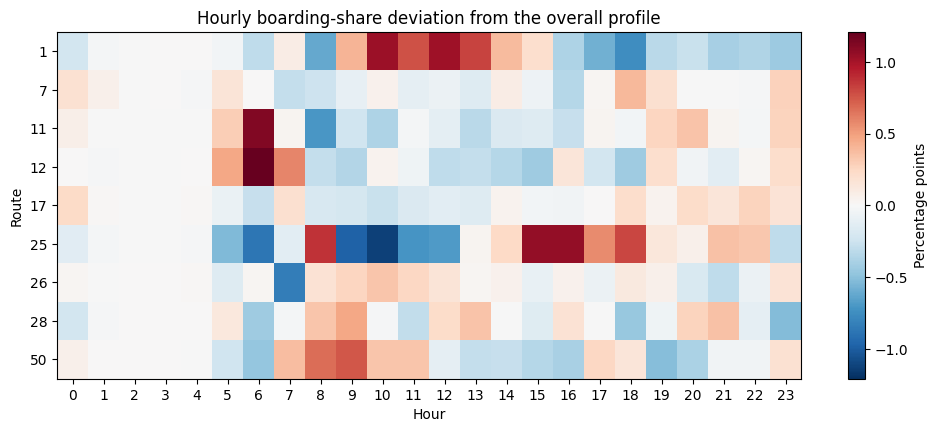

In [10]:
route_profile = shares.groupby(["route", "hour"])["share"].mean().unstack("hour")
overall_profile = shares.groupby("hour")["share"].mean()
route_delta_pp = route_profile.sub(overall_profile, axis="columns") * 100
route_distance_pp = route_delta_pp.abs().sum(axis=1) / 2
print(f"Mean route-to-overall profile distance: {route_distance_pp.mean():.2f} pp")
print(f"Range across routes: {route_distance_pp.min():.2f}–{route_distance_pp.max():.2f} pp")

fig, ax = plt.subplots(figsize=(12, 4.5))
heatmap_data = route_delta_pp.to_numpy(dtype=float)
limit = max(np.nanmax(np.abs(heatmap_data)), 0.01)
heatmap = ax.imshow(heatmap_data, aspect="auto", cmap="RdBu_r", vmin=-limit, vmax=limit)
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(route_profile)), labels=route_profile.index)
ax.set_xlabel("Hour")
ax.set_ylabel("Route")
ax.set_title("Hourly boarding-share deviation from the overall profile")
fig.colorbar(heatmap, ax=ax, label="Percentage points")
plt.show()

### `hour × weekend`

Средние часовые доли по всем дням маршрутов, отдельно для будней и выходных. Метрика расстояния полной вариации суммирует перераспределение суточной доли между часами; максимум абсолютного разрыва показывает самый различающийся час.

Route-days: weekdays 1557, weekends 630
Distance between profiles: 13.37 pp
Largest hourly gap: 4.87 pp at 08:00


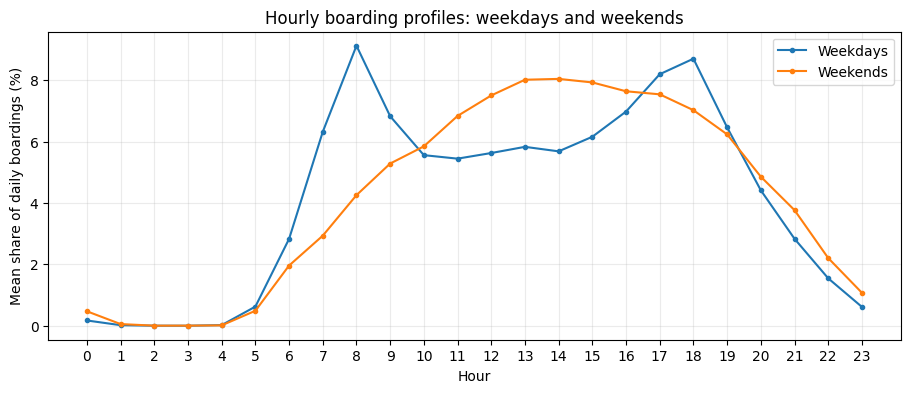

In [11]:
day_type_counts = (
    shares[["route", "date", "is_weekend"]].drop_duplicates()
    .groupby("is_weekend").size()
)
day_profile = shares.groupby(["is_weekend", "hour"])["share"].mean().unstack("hour")
assert {False, True}.issubset(day_profile.index), "Both weekdays and weekends are required"
gap_pp = (day_profile.loc[True] - day_profile.loc[False]) * 100
print(f"Route-days: weekdays {day_type_counts[False]}, weekends {day_type_counts[True]}")
print(f"Distance between profiles: {gap_pp.abs().sum() / 2:.2f} pp")
print(f"Largest hourly gap: {gap_pp.abs().max():.2f} pp at {gap_pp.abs().idxmax():02d}:00")

fig, ax = plt.subplots(figsize=(11, 4))
for is_weekend, label in [(False, "Weekdays"), (True, "Weekends")]:
    ax.plot(day_profile.columns, day_profile.loc[is_weekend] * 100, marker="o", ms=3, label=label)
ax.set_xticks(range(24))
ax.set_xlabel("Hour")
ax.set_ylabel("Mean share of daily boardings (%)")
ax.set_title("Hourly boarding profiles: weekdays and weekends")
ax.grid(alpha=0.25)
ax.legend()
plt.show()

### Conclusion

На 9 маршрутах и 243 днях (январь–август 2025; 0 дней маршрута исключено как полностью нулевые) суточные профили различаются. Среднее расстояние профиля маршрута от общего составило 2.85 п.п. и лежало в диапазоне 1.43–5.51 п.п. Различие профилей будней и выходных составило 13.37 п.п.; наибольший почасовой разрыв — 4.87 п.п. в 08:00. Эти результаты поддерживают наличие различий, описываемых взаимодействиями `route × hour` и `hour × weekend`.

### Decision

Оставить оба взаимодействия кандидатами для следующего сравнения признаков. Эти агрегированные профили сами по себе не показывают, улучшат ли взаимодействия точность прогноза; это потребует отдельной временной валидации модели.

## Feature experiment — interaction features

Сравниваем четыре варианта одной и той же модели LightGBM: текущий baseline, добавление `route × hour`, добавление `hour × weekend` и добавление обоих признаков. Во всех вариантах сохраняются baseline-признаки `route`, `weekday`, `hour`, параметры модели, seed, округление прогноза и временное разделение: обучение на январе–августе 2025, проверка на сентябре–октябре 2025.

Каждое взаимодействие кодируется отдельным категориальным признаком с фиксированным словарём категорий для train и validation. Для загрузки используются пути из `Environment & Data Setup`; CSV читаются с разделителем `;`, как в `lightgbm_baseline.py`. Фактические `boardings` валидации читаются только после получения всех прогнозов.

WAPE и `delta_WAPE_vs_baseline` выводятся как доли; отрицательная дельта означает меньшую ошибку. WAPE маршрута с нулевой суммой фактических посадок не определён и отображается как `NaN`.

In [12]:
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor

ROUTES = (1, 5, 7, 11, 12, 17, 25, 26, 28, 50)
BASELINE_FEATURES = ("route", "weekday", "hour")
EXPERIMENTS = (
    ("baseline", ()),
    ("route_hour", ("route_hour",)),
    ("hour_weekend", ("hour_weekend",)),
    ("both", ("route_hour", "hour_weekend")),
)

train = train_hourly.copy()
validation_keys = valid_hourly[["route", "date", "hour"]].copy()
if len(train) != 58_320 or len(validation_keys) != 14_640:
    raise ValueError("Unexpected hourly grid size")
if train["date"].max() >= validation_keys["date"].min():
    raise ValueError("Training and validation periods overlap")

def calendar_features(rows, added_features=()):
    features = pd.DataFrame(
        {
            "route": pd.Categorical(rows["route"], categories=ROUTES),
            "weekday": pd.Categorical(rows["date"].dt.weekday, categories=range(7)),
            "hour": pd.Categorical(rows["hour"], categories=range(24)),
        }
    )
    if "route_hour" in added_features:
        features["route_hour"] = pd.Categorical(
            rows["route"] * 24 + rows["hour"],
            categories=[route * 24 + hour for route in ROUTES for hour in range(24)],
        )
    if "hour_weekend" in added_features:
        features["hour_weekend"] = pd.Categorical(
            rows["hour"] * 2 + rows["date"].dt.weekday.ge(5).astype(int),
            categories=range(48),
        )
    return features.loc[:, list(BASELINE_FEATURES + added_features)]

In [13]:
predictions_by_experiment = {}
for experiment, added_features in EXPERIMENTS:
    feature_columns = BASELINE_FEATURES + added_features
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        calendar_features(train, added_features),
        train["boardings"],
        categorical_feature=list(feature_columns),
    )
    prediction = np.floor(
        np.maximum(model.predict(calendar_features(validation_keys, added_features)), 0) + 0.5
    )
    predictions_by_experiment[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

baseline: 14,640 validation predictions
route_hour: 14,640 validation predictions
hour_weekend: 14,640 validation predictions
both: 14,640 validation predictions


In [14]:
actual = valid_hourly["boardings"].to_numpy()
if len(actual) != len(validation_keys) or actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(actual) or not np.isfinite(prediction).all()
    for prediction in predictions_by_experiment.values()
):
    raise ValueError("Invalid validation predictions")

summary_rows = []
route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
for experiment, added_features in EXPERIMENTS:
    absolute_error = np.abs(actual - predictions_by_experiment[experiment])
    summary_rows.append(
        {
            "experiment": experiment,
            "added_features": ", ".join(added_features) or "none",
            "WAPE": absolute_error.sum() / actual.sum(),
        }
    )
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    route_wape[experiment] = route_error / route_totals.replace(0, np.nan)

summary = pd.DataFrame(summary_rows)
baseline_wape = summary.loc[summary["experiment"].eq("baseline"), "WAPE"].iloc[0]
summary["delta_WAPE_vs_baseline"] = summary["WAPE"] - baseline_wape
print("Overall validation WAPE:")
display(summary.round(6))
print("WAPE by route (NaN means zero actual boardings):")
display(route_wape.reset_index().round(6))

Overall validation WAPE:
WAPE by route (NaN means zero actual boardings):


,experiment,added_features,WAPE,delta_WAPE_vs_baseline
0,baseline,none,0.132197,0.000000
1,route_hour,route_hour,0.127824,-0.004373
2,hour_weekend,hour_weekend,0.125208,-0.006989
3,both,"route_hour, hour_weekend",0.124202,-0.007995


,route,baseline,route_hour,hour_weekend,both
0,1,0.115082,0.117248,0.109434,0.109786
1,5,NaN,NaN,NaN,NaN
2,7,0.154455,0.154608,0.155678,0.157190
3,11,0.112397,0.108842,0.106721,0.106459
4,12,0.093815,0.092247,0.091393,0.088728
5,17,0.108190,0.090728,0.085823,0.086434
6,25,0.198484,0.203067,0.196025,0.198598
7,26,0.126199,0.131403,0.124002,0.127354
8,28,0.154426,0.159332,0.155351,0.154627
9,50,0.246582,0.247136,0.245947,0.240803


### Conclusion

На пересчитанном Sep–Oct holdout baseline WAPE составил 0.132197.
- `route_hour`: WAPE 0.127824, Δ -0.004373; лучше/хуже на маршрутах 3/6 из 9.
- `hour_weekend`: WAPE 0.125208, Δ -0.006989; лучше/хуже на маршрутах 7/2 из 9.
- `both`: WAPE 0.124202, Δ -0.007995; лучше/хуже на маршрутах 5/4 из 9.

### Decision

- `baseline` — **KEEP**, WAPE 0.132197.
- `route_hour` — **INCONCLUSIVE**, WAPE 0.127824.
- `hour_weekend` — **KEEP**, WAPE 0.125208.
- `both` — **KEEP**, WAPE 0.124202.

## Feature experiment roadmap

Инвентаризация всех кандидатов из `data/Features.md`. Статусы и результат H2 взяты из сохранённых outputs текущего notebook. Значения известны для Nov–Dec, если детерминированы ключами prediction grid или сформированы из источника, опубликованного до inference.

### A. Безопасные / известные заранее

| Кандидат — исходная гипотеза | Данные → известно на Nov–Dec? | Leakage / open-loop | Тип | Статус в notebook | Порядок |
|---|---|---|---|---|---|
| `route`, `hour`, `dow`: задают базовые различия маршрута, часа и дня недели | `route/date/hour` из grid → да | Нет; не требуется | Календарь/время, известные заранее | **KEEP** — frozen baseline | Эталон |
| `month`: сезонный дрейф | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **REJECT**: H3, WAPE 0.215849 против 0.124202 у принятой модели; хуже на 9/9 маршрутов | Проверено в H3 |
| `day`: внутримесячная динамика | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **REJECT**: H4, WAPE 0.132626 против 0.124202 у принятой модели; хуже на 9/9 маршрутов | Проверено в H4 |
| `weekofyear`: тонкая сезонная динамика | `date` → да | Нет; рекурсия не требуется | Календарь/время, известные заранее | **REJECT**: H5, WAPE 0.181782 против 0.124202 у принятой модели; хуже на 9/9 маршрутов | Проверено в H5 |
| `is_weekend`: профиль выходных отличается | `date` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H6, WAPE 0.124220 против 0.124202 у принятой модели; overall улучшение минимально; флаг полностью избыточен | Проверено в H6; отдельно не добавлять |
| `is_night`: отдельный ночной режим | `hour` → да | Нет; не требуется | Календарь/время, известные заранее | **KEEP**: H7, WAPE 0.123793 против 0.124202 у принятой модели до H7; overall WAPE улучшился | Проверено в H7; включать в следующие accepted sets |
| `is_peak`: отдельный пиковый режим | `hour` → да | Нет; не требуется | Календарь/время, известные заранее | **INCONCLUSIVE**: H8, WAPE 0.123569 против 0.123793 у принятой модели; по per-route таблице эффект неоднородный и мал | Проверено в H8; не добавлять автоматически |
| `hour_sin/cos`: циклическая форма суточного профиля | `hour` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H9, WAPE 0.124220 против 0.123793 у принятой модели; overall WAPE ухудшился | Проверено в H9; пару не добавлять |
| `dow_sin/cos`: циклическая форма недельного профиля | `date` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H10, WAPE 0.124590 против 0.123793 у принятой модели; overall WAPE ухудшился | Проверено в H10; пару не добавлять |
| `month_sin/cos`: циклическая форма годового профиля | `date` → да | Нет; не требуется | Календарь/время, известные заранее | **REJECT**: H11, WAPE 0.213680 против 0.123793 у принятой модели; хуже на 9/9 маршрутов | Проверено в H11; пару не добавлять |
| `hour_weekend` (`hour × weekend`): суточный профиль зависит от типа дня | `hour/date` → да | Нет; не требуется | Взаимодействие | **KEEP** — проверено моделью: WAPE 0.125233, Δ −0.006990; лучше baseline на 7/9 маршрутов с определённым WAPE | Уже проверено |
| `hour_weekend_sin/cos`: циклический профиль выходного часа | `hour/date` → да | Нет; не требуется | Взаимодействие | **REJECT** — H12: WAPE 0.124319 против 0.123793 у принятой модели; overall WAPE ухудшился | Проверено в H12 |
| `peak_weekday`, `peak_weekend`: пик зависит от типа дня | `hour/date` → да | Нет; не требуется | Взаимодействие | **REJECT** — H13: WAPE 0.124161 против 0.123793 у принятой модели; overall WAPE ухудшился | Проверено в H13; пару не добавлять |
| `route_hour` (`route × hour`): у маршрутов разные суточные профили | `route/hour` → да; для route 5 значение строится, но нет положительной истории для обучения его профиля | Нет; не требуется. У route 5 есть cold-start риск, не leakage | Взаимодействие | **INCONCLUSIVE** отдельно в H2; **KEEP** в pilot составе после final ablation: без него WAPE +0.000844 | Pilot: оставить; отдельный эффект можно проверять на других temporal cutoffs |
| `route_hour_sin/cos`: циклическое кодирование route-specific профиля | `route/hour` + фиксированный `route_idx` mapping → да; route 5 остаётся cold start | Нет; не требуется. Порядок route_idx искусственный и требует проверки | Взаимодействие | **REJECT** — H14: WAPE 0.124149 против 0.123793 у принятой модели; overall WAPE ухудшился | Проверено в H14; пару не добавлять |
| `route_dow`: реакция на день недели различается по маршрутам | `route/date` → да; route 5 остаётся cold start | Нет; не требуется | Взаимодействие | **REJECT** — H15: WAPE 0.124239 против 0.123793 у принятой модели; overall WAPE ухудшился | Проверено в H15; не добавлять |
| `route_hour + hour_weekend`: совместно описывают маршрутный и недельный профили | `route/hour/date` → да | Нет; не требуется | Взаимодействие | **KEEP** — проверено моделью: лучший overall WAPE 0.124202, Δ −0.007995 относительно baseline; per-route результаты см. в таблице H2 | Уже проверено; детали сравнения по маршрутам не дублировать |
| `days_since_start`: отражает временной дрейф | `date` и фиксированная start date → да | Нет; не требуется. Риск — экстраполяция дерева за диапазон train | Календарь/время, известные заранее (trend) | **REJECT** — H16: WAPE 0.179140 против 0.123793 у принятой модели; хуже по overall WAPE | Проверено в H16; не добавлять |
| H17: `route_dow` + общий или разделённый пиковый режим | `route/date/hour` → да; route 5 остаётся cold start | Нет; рекурсия не требуется | Группа взаимодействий | **REJECT** — оба варианта: WAPE 0.123978 и 0.125696 против 0.123793 у принятой модели | Проверено в H17; группы не добавлять |

Проверка сигнала H2 в notebook: расстояние между weekend/weekday профилями — 13.37 п.п.; максимальный почасовой разрыв — 4.87 п.п. в 08:00. Это описательный сигнал; статусы проверено моделью выше опираются на отдельный контролируемый эксперимент.

### B. Исторические / производные от target

В `data/Features.md` пока нет конкретных гипотез для исторических агрегатов или лагов и скользящих агрегатов от target. EDA и контекст прогнозирования упоминают лаги/агрегаты, но это ещё не зарегистрированные кандидаты. Перед проверкой нужно определить окно и способ построения. Источник — прошлые `boardings`; leakage возникает при использовании фактического target validation или будущего периода или глобальных агрегатов. Для validation и Nov–Dec требуется open-loop оценка: лаги/окна, попадающие внутрь прогнозного горизонта, рассчитывать рекурсивно по предыдущим predictions. Порядок — после safe calendar candidates и регистрации точной гипотезы в Features.md.

### C. Внешние / пока недоступные

| Кандидат — исходная гипотеза | Данные → известно на Nov–Dec? | Leakage / open-loop | Тип | Статус в notebook | Порядок |
|---|---|---|---|---|---|
| `is_holiday`: праздники объясняют часть провалов пассажиропотока | Официальный календарь праздников + `date` → будет известно заранее, если календарь подтверждён до inference; такого источника в текущем setup не найдено | Нет при заранее зафиксированном календаре; leakage, если метки выводить из наблюдаемого target постфактум. Open-loop не требуется | Внешние метаданные + known-in-advance calendar/time | **BLOCKED** до предоставления/подтверждения календаря | После подтверждения источника |

EDA также упоминает погоду и заранее известные изменения движения, но таких feature-кандидатов пока нет в `data/Features.md`; они не включены в эту инвентаризацию.

## H3 — month

### Hypothesis

Числовой календарный месяц может отражать медленные изменения пассажиропотока сверх принятого набора признаков `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только `date.month`.

### Availability / leakage

Месяц известен из ключа `(route, date, hour)` для всего периода Nov–Dec. Не нужны будущий target, внешние данные или рекурсия. Train охватывает январь–август, validation — сентябрь–октябрь, а inference — ноябрь–декабрь. Значения месяца на validation и inference выходят за диапазон train. Дерево LightGBM не экстраполирует тренд за обученные пороги; по одному году нельзя установить повторяющуюся годовую сезонность.


### Analysis

Используются только данные train за январь–август. Сравниваются помесячные средние посадок и средние остатки после учёта `route`, `weekday` и `hour`. Остаток служит только для описательной проверки и не становится признаком модели.


In [15]:
month_analysis = train[["route", "date", "hour", "boardings"]].copy()
month_analysis["month"] = month_analysis["date"].dt.month
month_analysis["weekday"] = month_analysis["date"].dt.weekday
context_mean = month_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
month_analysis["context_residual"] = month_analysis["boardings"] - context_mean
monthly_signal = month_analysis.groupby("month").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only monthly signal:")
display(monthly_signal.round(3))
print(
    "Range of monthly context residual means:",
    round(monthly_signal["mean_context_residual"].max()
          - monthly_signal["mean_context_residual"].min(), 3),
)


Training-only monthly signal:
Range of monthly context residual means: 201.871


,observations,mean_boardings,mean_context_residual
month,,,
1,7440,748.296,-66.877
2,6720,883.151,77.743
3,7440,903.048,111.787
4,7200,891.441,77.497
5,7440,806.575,2.846
6,7200,771.526,-27.079
7,7440,726.838,-90.084
8,7440,713.707,-76.682


### Correlation / redundancy

Для числового `month` рассчитываются Pearson и Spearman с target и описательным остатком. Число месяцев внутри каждого сочетания `route/weekday/hour` показывает структурную избыточность. Pearson для кодов категориальных признаков здесь неинформативен. Корреляция сама по себе не определяет решение о включении признака.


In [16]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"month vs {target_name}",
        "Pearson": month_analysis["month"].corr(month_analysis[target_name], method="pearson"),
        "Spearman": month_analysis["month"].corr(month_analysis[target_name], method="spearman"),
    })
print("Numeric month diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
months_per_context = month_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["month"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple months:",
    f"{months_per_context.gt(1).sum()} / {len(months_per_context)}",
)


Numeric month diagnostics on training data:
Route/weekday/hour contexts observed in multiple months: 1680 / 1680


,pair,Pearson,Spearman
0,month vs boardings,-0.0428,-0.0217
1,month vs context_residual,-0.1382,-0.2178


### LightGBM experiment

Сравниваются принятый набор и тот же набор с числовым `month`. Сохраняются frozen модель, гиперпараметры, обработка категориальных признаков, temporal split январь–август / сентябрь–октябрь, seed и постобработка прогнозов. Сначала нужно выполнить ячейки `Environment & Data Setup`, frozen baseline и setup H2. Фактический target validation читается только после построения обоих прогнозов.


In [17]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
MONTH_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_month", True),
)

def month_experiment_features(rows, add_month):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_month:
        features["month"] = rows["date"].dt.month.to_numpy(dtype="int16")
    return features

month_models = {}
month_predictions = {}
for experiment, add_month in MONTH_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        month_experiment_features(train, add_month),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(month_experiment_features(validation_keys, add_month)), 0
        ) + 0.5
    )
    month_models[experiment] = model
    month_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_month: 14,640 validation predictions


### Feature importance

Gain importance показывает, как модель с кандидатом использовала `month`. Сам по себе этот показатель не является основанием оставить признак.


In [18]:
candidate_model = month_models["current_accepted_plus_month"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("month")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
3,month,68012.987,4


,feature,gain,rank
0,route_hour,2385372.568,1
1,route,561267.100,2
2,hour_weekend,526923.327,3
3,month,68012.987,4
4,weekday,29453.828,5


### Results

Для WAPE меньшее значение лучше, для WAPE-score — большее. Абсолютная и относительная дельты WAPE рассчитаны относительно текущего принятого набора; отдельная дельта — относительно исходного frozen baseline. Отрицательная дельта WAPE означает улучшение. WAPE маршрута не определён, если сумма его фактических посадок равна нулю.


In [19]:
month_actual = valid_hourly["boardings"].to_numpy()
if len(month_actual) != len(validation_keys) or month_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(month_actual) or not np.isfinite(prediction).all()
    for prediction in month_predictions.values()
):
    raise ValueError("Invalid validation predictions")

month_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": month_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
month_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
month_result_rows = []
for experiment, add_month in MONTH_EXPERIMENTS:
    absolute_error = np.abs(month_actual - month_predictions[experiment])
    overall_wape = absolute_error.sum() / month_actual.sum()
    month_result_rows.append({
        "experiment": experiment,
        "added_features": "month" if add_month else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    month_route_wape[experiment] = route_error / month_route_totals.replace(0, np.nan)

month_results = pd.DataFrame(month_result_rows)
accepted_wape = month_results.loc[
    month_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
month_results["delta_WAPE_vs_accepted"] = month_results["WAPE"] - accepted_wape
month_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * month_results["delta_WAPE_vs_accepted"] / accepted_wape
)
month_results["delta_WAPE_vs_frozen_baseline"] = (
    month_results["WAPE"] - frozen_overall_wape
)
month_route_wape["delta_month_vs_accepted"] = (
    month_route_wape["current_accepted_plus_month"]
    - month_route_wape["current_accepted"]
)
print("Overall validation results:")
display(month_results.round(6))
print("Validation WAPE by route:")
display(month_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124202,0.875798,0.000000,0.000000,-0.007995
1,current_accepted_plus_month,month,0.215849,0.784151,0.091648,73.789429,0.083653


,route,current_accepted,current_accepted_plus_month,delta_month_vs_accepted
0,1,0.109786,0.201230,0.091444
1,5,NaN,NaN,NaN
2,7,0.157190,0.374630,0.217440
3,11,0.106459,0.170107,0.063648
4,12,0.088728,0.150524,0.061797
5,17,0.086434,0.144836,0.058401
6,25,0.198598,0.312821,0.114223
7,26,0.127354,0.260402,0.133048
8,28,0.154627,0.271343,0.116716
9,50,0.240803,0.309844,0.069041


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `month`: WAPE текущего набора 0.124202, WAPE с кандидатом 0.215849 (Δ +0.091648; относительная Δ +73.789429%); WAPE-score 0.875798 → 0.784151. По маршрутам улучшение/ухудшение: 0/9 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT** для числового `month`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`; `month` в него не добавляется.

## H4 — day

### Hypothesis

Числовой день месяца (`date.day`, 1–31) может отражать повторяющийся внутримесячный профиль спроса сверх принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только этот кандидат.

### Availability / leakage

День месяца известен из даты на всём горизонте Nov–Dec. Не нужны target, внешние данные или рекурсия. Все значения дня встречаются в train за январь–август, хотя для последних дней месяца наблюдений меньше. Target validation не используется при построении признака.


### Analysis

Используются только данные train за январь–август. Для каждого дня месяца рассматриваются средние посадки и средние остатки после учёта `route`, `weekday` и `hour`, вместе с числом наблюдений. Это проверка сигнала; описательный остаток не поступает в модель.


In [20]:
day_analysis = train[["route", "date", "hour", "boardings"]].copy()
day_analysis["day"] = day_analysis["date"].dt.day
day_analysis["weekday"] = day_analysis["date"].dt.weekday
context_mean = day_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
day_analysis["context_residual"] = day_analysis["boardings"] - context_mean
daily_signal = day_analysis.groupby("day").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only daily signal:")
display(daily_signal.round(3))
print(
    "Range of daily context residual means:",
    round(daily_signal["mean_context_residual"].max()
          - daily_signal["mean_context_residual"].min(), 3),
)


Training-only daily signal:
Range of daily context residual means: 215.162


,observations,mean_boardings,mean_context_residual
day,,,
1,1920,619.215,-160.285
2,1920,655.240,-109.131
3,1920,795.029,-21.533
4,1920,822.739,2.760
5,1920,790.240,9.307
6,1920,772.776,-35.458
7,1920,840.614,-27.662
8,1920,666.756,-112.744
9,1920,722.328,-42.043


### Correlation / redundancy

Для числового дня рассчитываются Pearson и Spearman с посадками и описательным остатком. Дополнительно подсчитывается число разных дней внутри каждого сочетания `route/weekday/hour`. Коды категориальных признаков не трактуются как непрерывные величины. Одна корреляция не определяет, включать ли признак.


In [21]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"day vs {target_name}",
        "Pearson": day_analysis["day"].corr(day_analysis[target_name], method="pearson"),
        "Spearman": day_analysis["day"].corr(day_analysis[target_name], method="spearman"),
    })
print("Numeric day diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
days_per_context = day_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["day"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple days:",
    f"{days_per_context.gt(1).sum()} / {len(days_per_context)}",
)


Numeric day diagnostics on training data:
Route/weekday/hour contexts observed in multiple days: 1680 / 1680


,pair,Pearson,Spearman
0,day vs boardings,0.0409,0.0318
1,day vs context_residual,0.1311,0.1147


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой `day`. Сохраняются frozen параметры LightGBM, обработка категориальных признаков, seed, train за январь–август, holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Target holdout читается только после завершения обоих прогнозов.


In [22]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
DAY_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_day", True),
)

def day_experiment_features(rows, add_day):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_day:
        features["day"] = rows["date"].dt.day.to_numpy(dtype="int16")
    return features

day_models = {}
day_predictions = {}
for experiment, add_day in DAY_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        day_experiment_features(train, add_day),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(day_experiment_features(validation_keys, add_day)), 0
        ) + 0.5
    )
    day_models[experiment] = model
    day_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_day: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, как модель использовала `day`; это дополнительная диагностика к temporal WAPE.


In [23]:
candidate_model = day_models["current_accepted_plus_day"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("day")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
3,day,24038.92,4


,feature,gain,rank
0,route_hour,2933608.454,1
1,hour_weekend,491161.614,2
2,weekday,44698.693,3
3,day,24038.920,4
4,route,11002.358,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Если сумма фактических посадок маршрута равна нулю, его WAPE не определён.


In [24]:
day_actual = valid_hourly["boardings"].to_numpy()
if len(day_actual) != len(validation_keys) or day_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(day_actual) or not np.isfinite(prediction).all()
    for prediction in day_predictions.values()
):
    raise ValueError("Invalid validation predictions")

day_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": day_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
day_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
day_result_rows = []
for experiment, add_day in DAY_EXPERIMENTS:
    absolute_error = np.abs(day_actual - day_predictions[experiment])
    overall_wape = absolute_error.sum() / day_actual.sum()
    day_result_rows.append({
        "experiment": experiment,
        "added_features": "day" if add_day else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    day_route_wape[experiment] = route_error / day_route_totals.replace(0, np.nan)

day_results = pd.DataFrame(day_result_rows)
accepted_wape = day_results.loc[
    day_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
day_results["delta_WAPE_vs_accepted"] = day_results["WAPE"] - accepted_wape
day_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * day_results["delta_WAPE_vs_accepted"] / accepted_wape
)
day_results["delta_WAPE_vs_frozen_baseline"] = (
    day_results["WAPE"] - frozen_overall_wape
)
day_route_wape["delta_day_vs_accepted"] = (
    day_route_wape["current_accepted_plus_day"]
    - day_route_wape["current_accepted"]
)
print("Overall validation results:")
display(day_results.round(6))
print("Validation WAPE by route:")
display(day_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124202,0.875798,0.000000,0.00000,-0.007995
1,current_accepted_plus_day,day,0.132626,0.867374,0.008424,6.78247,0.000429


,route,current_accepted,current_accepted_plus_day,delta_day_vs_accepted
0,1,0.109786,0.120110,0.010324
1,5,NaN,NaN,NaN
2,7,0.157190,0.160113,0.002922
3,11,0.106459,0.114958,0.008499
4,12,0.088728,0.098566,0.009838
5,17,0.086434,0.094477,0.008042
6,25,0.198598,0.204020,0.005423
7,26,0.127354,0.136333,0.008979
8,28,0.154627,0.163191,0.008564
9,50,0.240803,0.252645,0.011842


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `day`: WAPE текущего набора 0.124202, WAPE с кандидатом 0.132626 (Δ +0.008424; относительная Δ +6.782470%); WAPE-score 0.875798 → 0.867374. По маршрутам улучшение/ухудшение: 0/9 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT** для числового `day`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`; `day` в него не добавляется.

## H5 — weekofyear

### Hypothesis

Числовая ISO-неделя года (`date.isocalendar().week`) может отражать более тонкие сезонные изменения спроса сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Добавляется только `weekofyear`.

### Availability / leakage

Номер ISO-недели известен из даты для всего горизонта Nov–Dec; будущий target, внешние данные и рекурсия не нужны. Train содержит январь–август, validation — сентябрь–октябрь. Все номера недель validation выходят за диапазон train; деревья LightGBM не экстраполируют временной тренд за обученные пороги. В конце декабря дата может относиться к ISO-неделе 1 следующего года, поэтому числовое кодирование имеет разрыв на границе года. Один год данных не подтверждает повторяемую сезонность.


### Analysis

Используются только данные train за январь–август. Для каждой ISO-недели рассматриваются число наблюдений, средние посадки и средние остатки после учёта `route`, `weekday` и `hour`. Это проверка наличия сигнала; описательный остаток не поступает в модель.


In [25]:
weekofyear_analysis = train[["route", "date", "hour", "boardings"]].copy()
weekofyear_analysis["weekofyear"] = weekofyear_analysis["date"].dt.isocalendar().week.astype("int16")
weekofyear_analysis["weekday"] = weekofyear_analysis["date"].dt.weekday
context_mean = weekofyear_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
weekofyear_analysis["context_residual"] = weekofyear_analysis["boardings"] - context_mean
weekly_signal = weekofyear_analysis.groupby("weekofyear").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
)
print("Training-only weekly signal:")
display(weekly_signal.round(3))
print(
    "Range of weekly context residual means:",
    round(weekly_signal["mean_context_residual"].max()
          - weekly_signal["mean_context_residual"].min(), 3),
)


Training-only weekly signal:
Range of weekly context residual means: 477.837


,observations,mean_boardings,mean_context_residual
weekofyear,,,
1,1200,412.414,-344.099
2,1680,592.944,-212.464
3,1680,866.901,61.493
4,1680,858.604,53.196
5,1680,854.764,49.356
6,1680,863.978,58.570
7,1680,891.072,85.664
8,1680,885.324,79.917
9,1680,905.117,99.709


### Correlation / redundancy

Для числового `weekofyear` рассчитываются Pearson и Spearman с посадками и описательным остатком. Дополнительно проверяется, в скольких сочетаниях `route/weekday/hour` встречается больше одной недели. Коды категориальных признаков не трактуются как непрерывные величины. Корреляция сама по себе не является правилом отбора признака.


In [26]:
correlation_rows = []
for target_name in ("boardings", "context_residual"):
    correlation_rows.append({
        "pair": f"weekofyear vs {target_name}",
        "Pearson": weekofyear_analysis["weekofyear"].corr(weekofyear_analysis[target_name], method="pearson"),
        "Spearman": weekofyear_analysis["weekofyear"].corr(weekofyear_analysis[target_name], method="spearman"),
    })
print("Numeric weekofyear diagnostics on training data:")
display(pd.DataFrame(correlation_rows).round(4))
weeks_per_context = weekofyear_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["weekofyear"].nunique()
print(
    "Route/weekday/hour contexts observed in multiple weeks:",
    f"{weeks_per_context.gt(1).sum()} / {len(weeks_per_context)}",
)


Numeric weekofyear diagnostics on training data:
Route/weekday/hour contexts observed in multiple weeks: 1680 / 1680


,pair,Pearson,Spearman
0,weekofyear vs boardings,-0.0331,-0.0143
1,weekofyear vs context_residual,-0.1213,-0.2004


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой `weekofyear`. Frozen LightGBM, гиперпараметры, обработка категориальных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов сохраняются. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [27]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
WEEKOFYEAR_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_weekofyear", True),
)

def weekofyear_experiment_features(rows, add_weekofyear):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_weekofyear:
        features["weekofyear"] = rows["date"].dt.isocalendar().week.astype("int16").to_numpy(dtype="int16")
    return features

weekofyear_models = {}
weekofyear_predictions = {}
for experiment, add_weekofyear in WEEKOFYEAR_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        weekofyear_experiment_features(train, add_weekofyear),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(weekofyear_experiment_features(validation_keys, add_weekofyear)), 0
        ) + 0.5
    )
    weekofyear_models[experiment] = model
    weekofyear_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_weekofyear: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, как модель использовала `weekofyear`. Это дополнительная диагностика, а не самостоятельное основание оставить признак.


In [28]:
candidate_model = weekofyear_models["current_accepted_plus_weekofyear"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("weekofyear")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
3,weekofyear,65035.696,4


,feature,gain,rank
0,route_hour,2753397.503,1
1,hour_weekend,545975.106,2
2,route,242854.877,3
3,weekofyear,65035.696,4
4,weekday,46767.806,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [29]:
weekofyear_actual = valid_hourly["boardings"].to_numpy()
if len(weekofyear_actual) != len(validation_keys) or weekofyear_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(weekofyear_actual) or not np.isfinite(prediction).all()
    for prediction in weekofyear_predictions.values()
):
    raise ValueError("Invalid validation predictions")

weekofyear_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": weekofyear_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
weekofyear_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
weekofyear_result_rows = []
for experiment, add_weekofyear in WEEKOFYEAR_EXPERIMENTS:
    absolute_error = np.abs(weekofyear_actual - weekofyear_predictions[experiment])
    overall_wape = absolute_error.sum() / weekofyear_actual.sum()
    weekofyear_result_rows.append({
        "experiment": experiment,
        "added_features": "weekofyear" if add_weekofyear else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    weekofyear_route_wape[experiment] = route_error / weekofyear_route_totals.replace(0, np.nan)

weekofyear_results = pd.DataFrame(weekofyear_result_rows)
accepted_wape = weekofyear_results.loc[
    weekofyear_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
weekofyear_results["delta_WAPE_vs_accepted"] = weekofyear_results["WAPE"] - accepted_wape
weekofyear_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * weekofyear_results["delta_WAPE_vs_accepted"] / accepted_wape
)
weekofyear_results["delta_WAPE_vs_frozen_baseline"] = (
    weekofyear_results["WAPE"] - frozen_overall_wape
)
weekofyear_route_wape["delta_weekofyear_vs_accepted"] = (
    weekofyear_route_wape["current_accepted_plus_weekofyear"]
    - weekofyear_route_wape["current_accepted"]
)
print("Overall validation results:")
display(weekofyear_results.round(6))
print("Validation WAPE by route:")
display(weekofyear_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124202,0.875798,0.00000,0.000000,-0.007995
1,current_accepted_plus_weekofyear,weekofyear,0.181782,0.818218,0.05758,46.360143,0.049585


,route,current_accepted,current_accepted_plus_weekofyear,delta_weekofyear_vs_accepted
0,1,0.109786,0.169106,0.059320
1,5,NaN,NaN,NaN
2,7,0.157190,0.284386,0.127196
3,11,0.106459,0.153820,0.047361
4,12,0.088728,0.129560,0.040832
5,17,0.086434,0.117546,0.031111
6,25,0.198598,0.243401,0.044804
7,26,0.127354,0.218897,0.091543
8,28,0.154627,0.211696,0.057069
9,50,0.240803,0.304004,0.063200


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `weekofyear`: WAPE текущего набора 0.124202, WAPE с кандидатом 0.181782 (Δ +0.057580; относительная Δ +46.360143%); WAPE-score 0.875798 → 0.818218. По маршрутам улучшение/ухудшение: 0/9 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT** для числового `weekofyear`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`; `weekofyear` в него не добавляется.

## H6 — is_weekend

### Hypothesis

Явный флаг выходного `is_weekend` может помочь LightGBM выделять общий эффект типа дня сверх принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Проверяется только этот бинарный признак; ранее проверенное взаимодействие остаётся в обеих версиях модели.

### Availability / leakage

Флаг однозначно определяется датой для всего горизонта Nov–Dec. Будущий target, внешние данные и рекурсия не требуются. Признак потенциально полностью избыточен по информации: он вычисляется из `weekday` и из уже принятого `hour_weekend`. Отдельное влияние на LightGBM оценивается temporal experiment, а не одной логикой признака.


### Analysis

На train за январь–август проверяются средние посадки в будни и выходные и часы с наибольшей разницей средних. Это описательная проверка сигнала, без использования target validation. Ранее в H2 уже выявлено различие суточных профилей типов дней; здесь рассматривается именно отдельный флаг.


In [30]:
weekend_analysis = train[["route", "date", "hour", "boardings"]].copy()
weekend_analysis["is_weekend"] = weekend_analysis["date"].dt.weekday.ge(5)
weekend_summary = weekend_analysis.groupby("is_weekend").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
)
print("Training-only weekday versus weekend signal:")
display(weekend_summary.round(3))

weekend_hourly = weekend_analysis.groupby(
    ["hour", "is_weekend"]
)["boardings"].mean().unstack("is_weekend")
weekend_hourly = weekend_hourly.rename(columns={False: "weekday", True: "weekend"})
weekend_hourly["weekend_minus_weekday"] = (
    weekend_hourly["weekend"] - weekend_hourly["weekday"]
)
largest_hour_gaps = weekend_hourly.loc[
    weekend_hourly["weekend_minus_weekday"].abs().nlargest(5).index
].sort_index()
print("Hours with the largest absolute mean gap:")
display(largest_hour_gaps.round(3))


Training-only weekday versus weekend signal:
Hours with the largest absolute mean gap:


,observations,mean_boardings
is_weekend,,
False,41520,914.696
True,16800,531.817


is_weekend,weekday,weekend,weekend_minus_weekday
hour,,,
7,1435.021,377.437,-1057.584
8,2009.545,529.219,-1480.326
9,1516.550,660.896,-855.655
17,1789.494,971.826,-817.668
18,1916.139,891.926,-1024.213


### Correlation / redundancy

Флаг бинарный, а принятые `weekday` и `hour_weekend` категориальные. Обычная Pearson matrix для их числовых кодов неинформативна. Вместо неё проверяется точное совпадение флага с `weekday >= 5` и с младшим битом `hour_weekend` на train. Полная информационная избыточность не заменяет проверку WAPE: явный флаг может изменить разбиения дерева.


In [31]:
accepted_train_features = calendar_features(
    train, ("route_hour", "hour_weekend")
)
weekend_flag = train["date"].dt.weekday.ge(5).astype("int8").to_numpy()
from_weekday = accepted_train_features["weekday"].astype(int).ge(5).astype("int8").to_numpy()
from_hour_weekend = (
    accepted_train_features["hour_weekend"].astype(int).mod(2).astype("int8").to_numpy()
)
print("Weekend mismatches against accepted weekday feature:", (weekend_flag != from_weekday).sum())
print(
    "Weekend mismatches against accepted hour_weekend feature:",
    (weekend_flag != from_hour_weekend).sum(),
)


Weekend mismatches against accepted weekday feature: 0
Weekend mismatches against accepted hour_weekend feature: 0


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой бинарный `is_weekend`. В обеих версиях сохраняются категориальный `hour_weekend`, frozen LightGBM, гиперпараметры, обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [32]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
IS_WEEKEND_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_is_weekend", True),
)

def is_weekend_experiment_features(rows, add_is_weekend):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_is_weekend:
        features["is_weekend"] = rows["date"].dt.weekday.ge(5).astype("int8").to_numpy(dtype="int8")
    return features

is_weekend_models = {}
is_weekend_predictions = {}
for experiment, add_is_weekend in IS_WEEKEND_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        is_weekend_experiment_features(train, add_is_weekend),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(is_weekend_experiment_features(validation_keys, add_is_weekend)), 0
        ) + 0.5
    )
    is_weekend_models[experiment] = model
    is_weekend_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_is_weekend: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, использовала ли модель добавленный `is_weekend` при уже имеющемся `hour_weekend`. Это только дополнительная диагностика к temporal WAPE.


In [33]:
candidate_model = is_weekend_models["current_accepted_plus_is_weekend"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("is_weekend")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
2,is_weekend,56476.401,3


,feature,gain,rank
0,route_hour,2291035.762,1
1,hour_weekend,1145774.806,2
2,is_weekend,56476.401,3
3,hour,43031.395,4
4,route,24172.320,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [34]:
is_weekend_actual = valid_hourly["boardings"].to_numpy()
if len(is_weekend_actual) != len(validation_keys) or is_weekend_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(is_weekend_actual) or not np.isfinite(prediction).all()
    for prediction in is_weekend_predictions.values()
):
    raise ValueError("Invalid validation predictions")

is_weekend_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": is_weekend_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
is_weekend_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
is_weekend_result_rows = []
for experiment, add_is_weekend in IS_WEEKEND_EXPERIMENTS:
    absolute_error = np.abs(is_weekend_actual - is_weekend_predictions[experiment])
    overall_wape = absolute_error.sum() / is_weekend_actual.sum()
    is_weekend_result_rows.append({
        "experiment": experiment,
        "added_features": "is_weekend" if add_is_weekend else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    is_weekend_route_wape[experiment] = route_error / is_weekend_route_totals.replace(0, np.nan)

is_weekend_results = pd.DataFrame(is_weekend_result_rows)
accepted_wape = is_weekend_results.loc[
    is_weekend_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
is_weekend_results["delta_WAPE_vs_accepted"] = is_weekend_results["WAPE"] - accepted_wape
is_weekend_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * is_weekend_results["delta_WAPE_vs_accepted"] / accepted_wape
)
is_weekend_results["delta_WAPE_vs_frozen_baseline"] = (
    is_weekend_results["WAPE"] - frozen_overall_wape
)
is_weekend_route_wape["delta_is_weekend_vs_accepted"] = (
    is_weekend_route_wape["current_accepted_plus_is_weekend"]
    - is_weekend_route_wape["current_accepted"]
)
print("Overall validation results:")
display(is_weekend_results.round(6))
print("Validation WAPE by route:")
display(is_weekend_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124202,0.875798,0.000000,0.00000,-0.007995
1,current_accepted_plus_is_weekend,is_weekend,0.124220,0.875780,0.000019,0.01515,-0.007976


,route,current_accepted,current_accepted_plus_is_weekend,delta_is_weekend_vs_accepted
0,1,0.109786,0.109561,-0.000224
1,5,NaN,NaN,NaN
2,7,0.157190,0.158000,0.000810
3,11,0.106459,0.107295,0.000836
4,12,0.088728,0.088943,0.000215
5,17,0.086434,0.085396,-0.001039
6,25,0.198598,0.197679,-0.000919
7,26,0.127354,0.127835,0.000482
8,28,0.154627,0.154418,-0.000209
9,50,0.240803,0.241342,0.000539


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `is_weekend`: WAPE текущего набора 0.124202, WAPE с кандидатом 0.124220 (Δ +0.000019; относительная Δ +0.015150%); WAPE-score 0.875798 → 0.875780. По маршрутам улучшение/ухудшение: 4/5 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT** отдельное добавление `is_weekend` к текущему принятому набору. Принятыми остаются `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Тип дня продолжает использоваться внутри принятого взаимодействия `hour_weekend`.

## H7 — is_night

### Hypothesis

Явный флаг ночных часов `is_night` (00:00–05:00) может помочь LightGBM выделять ночной режим сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour` и `hour_weekend`. Проверяется только этот флаг; граница ночи зафиксирована в `data/Features.md` до эксперимента.

### Availability / leakage

Флаг однозначно определяется значением `hour` из prediction grid на всём горизонте Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Информация уже содержится в категориальных `hour` и `route_hour`; отдельный флаг может лишь изменить удобство разбиения дерева. Его пользу определяет temporal WAPE.


### Analysis

На train за январь–август сравниваются число наблюдений, средние посадки и доля всех посадок для ночных и остальных часов. Это описательная проверка сигнала без target validation; различие уровней само по себе не подтверждает пользу нового признака при уже принятом `hour`.


In [35]:
night_analysis = train[["hour", "boardings"]].copy()
night_analysis["is_night"] = night_analysis["hour"].between(0, 5)
night_summary = night_analysis.groupby("is_night").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    total_boardings=("boardings", "sum"),
)
night_summary["share_of_total"] = (
    night_summary["total_boardings"] / night_summary["total_boardings"].sum()
)
print("Training-only night versus other hours:")
display(night_summary.round(4))


Training-only night versus other hours:


,observations,mean_boardings,total_boardings,share_of_total
is_night,,,,
False,43740,1062.2803,46464139,0.9904
True,14580,30.7662,448571,0.0096


### Correlation / redundancy

Флаг бинарный, а принятые `hour` и `route_hour` категориальные. Pearson для их числовых кодов неинформативен. Вместо него проверяется точное совпадение `is_night` с индикатором часов 0–5, восстановленным из каждого принятого признака. Полная информационная избыточность не заменяет контролируемое сравнение WAPE.


In [36]:
accepted_train_features = calendar_features(
    train, ("route_hour", "hour_weekend")
)
night_flag = train["hour"].between(0, 5).astype("int8").to_numpy()
from_hour = accepted_train_features["hour"].astype(int).between(0, 5).astype("int8").to_numpy()
from_route_hour = (
    accepted_train_features["route_hour"].astype(int).mod(24)
    .between(0, 5).astype("int8").to_numpy()
)
print("Night mismatches against accepted hour feature:", (night_flag != from_hour).sum())
print(
    "Night mismatches against accepted route_hour feature:",
    (night_flag != from_route_hour).sum(),
)


Night mismatches against accepted hour feature: 0
Night mismatches against accepted route_hour feature: 0


### LightGBM experiment

Сравниваются текущий принятый набор и тот же набор плюс числовой бинарный `is_night`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, обработка категориальных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [37]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
IS_NIGHT_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_is_night", True),
)

def is_night_experiment_features(rows, add_is_night):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    if add_is_night:
        features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    return features

is_night_models = {}
is_night_predictions = {}
for experiment, add_is_night in IS_NIGHT_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        is_night_experiment_features(train, add_is_night),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(is_night_experiment_features(validation_keys, add_is_night)), 0
        ) + 0.5
    )
    is_night_models[experiment] = model
    is_night_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_is_night: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, использовала ли модель добавленный `is_night` при уже имеющихся `hour` и `route_hour`. Это дополнительная диагностика к temporal WAPE.


In [38]:
candidate_model = is_night_models["current_accepted_plus_is_night"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("is_night")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
2,is_night,30845.364,3


,feature,gain,rank
0,route_hour,2560333.957,1
1,hour_weekend,559500.942,2
2,is_night,30845.364,3
3,weekday,24539.034,4
4,route,13226.341,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [39]:
is_night_actual = valid_hourly["boardings"].to_numpy()
if len(is_night_actual) != len(validation_keys) or is_night_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(is_night_actual) or not np.isfinite(prediction).all()
    for prediction in is_night_predictions.values()
):
    raise ValueError("Invalid validation predictions")

is_night_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": is_night_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
is_night_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
is_night_result_rows = []
for experiment, add_is_night in IS_NIGHT_EXPERIMENTS:
    absolute_error = np.abs(is_night_actual - is_night_predictions[experiment])
    overall_wape = absolute_error.sum() / is_night_actual.sum()
    is_night_result_rows.append({
        "experiment": experiment,
        "added_features": "is_night" if add_is_night else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    is_night_route_wape[experiment] = route_error / is_night_route_totals.replace(0, np.nan)

is_night_results = pd.DataFrame(is_night_result_rows)
accepted_wape = is_night_results.loc[
    is_night_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
is_night_results["delta_WAPE_vs_accepted"] = is_night_results["WAPE"] - accepted_wape
is_night_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * is_night_results["delta_WAPE_vs_accepted"] / accepted_wape
)
is_night_results["delta_WAPE_vs_frozen_baseline"] = (
    is_night_results["WAPE"] - frozen_overall_wape
)
is_night_route_wape["delta_is_night_vs_accepted"] = (
    is_night_route_wape["current_accepted_plus_is_night"]
    - is_night_route_wape["current_accepted"]
)
print("Overall validation results:")
display(is_night_results.round(6))
print("Validation WAPE by route:")
display(is_night_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.124202,0.875798,0.000000,0.000000,-0.007995
1,current_accepted_plus_is_night,is_night,0.123793,0.876207,-0.000408,-0.328888,-0.008403


,route,current_accepted,current_accepted_plus_is_night,delta_is_night_vs_accepted
0,1,0.109786,0.109409,-0.000377
1,5,NaN,NaN,NaN
2,7,0.157190,0.157333,0.000143
3,11,0.106459,0.105455,-0.001004
4,12,0.088728,0.088066,-0.000662
5,17,0.086434,0.085894,-0.000540
6,25,0.198598,0.199599,0.001001
7,26,0.127354,0.125388,-0.001966
8,28,0.154627,0.153739,-0.000888
9,50,0.240803,0.240656,-0.000147


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `is_night`: WAPE текущего набора 0.124202, WAPE с кандидатом 0.123793 (Δ -0.000408; относительная Δ -0.328888%); WAPE-score 0.875798 → 0.876207. По маршрутам улучшение/ухудшение: 7/2 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**KEEP** `is_night` для текущего последовательного набора: overall WAPE ниже и 7 из 9 маршрутов с определённой метрикой улучшились. Следующие feature experiments должны сравнивать кандидатов с принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`.

## H8 — is_peak

### Hypothesis

Явный флаг часов пик `is_peak` (07:00, 08:00, 09:00, 17:00, 18:00, 19:00) может помочь LightGBM выделять пиковый режим сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend` и `is_night`. Проверяется только этот флаг; часы пик зафиксированы в `data/Features.md` до эксперимента.

### Availability / leakage

Флаг однозначно определяется значением `hour` из prediction grid на всём горизонте Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Информация уже содержится в категориальных `hour` и `route_hour`; дополнительный флаг проверяется на том же temporal holdout, что и текущий принятый набор.


### Analysis

На train за январь–август сравниваются число наблюдений, средние посадки и доля всех посадок для фиксированных пиковых и остальных часов. Отдельная небольшая таблица показывает средние по типу дня, чтобы проверить, не скрывает ли общий итог разные режимы будней и выходных. Это описательная проверка без target validation.


In [40]:
peak_analysis = train[["date", "hour", "boardings"]].copy()
peak_analysis["is_peak"] = peak_analysis["hour"].isin((7, 8, 9, 17, 18, 19))
peak_analysis["is_weekend"] = peak_analysis["date"].dt.weekday.ge(5)
peak_summary = peak_analysis.groupby("is_peak").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    total_boardings=("boardings", "sum"),
)
peak_summary["share_of_total"] = (
    peak_summary["total_boardings"] / peak_summary["total_boardings"].sum()
)
print("Training-only peak versus other hours:")
display(peak_summary.round(4))
print("Mean boardings by peak and day type:")
display(
    peak_analysis.groupby(["is_weekend", "is_peak"])["boardings"]
    .mean().rename("mean_boardings").reset_index().round(3)
)


Training-only peak versus other hours:
Mean boardings by peak and day type:


,observations,mean_boardings,total_boardings,share_of_total
is_peak,,,,
False,43740,605.9225,26503049,0.5649
True,14580,1399.8396,20409661,0.4351


,is_weekend,is_peak,mean_boardings
0,False,False,659.159
1,False,True,1681.309
2,True,False,474.353
3,True,True,704.208


### Correlation / redundancy

Флаг бинарный, а принятые `hour` и `route_hour` категориальные. Pearson для их числовых кодов неинформативен. Вместо него проверяется точное совпадение `is_peak` с индикатором заранее выбранных часов, восстановленным из каждого принятого признака. Дополнительно проверяется пересечение с принятым `is_night`. Информационная избыточность сама по себе не заменяет сравнение WAPE.


In [41]:
accepted_train_features = calendar_features(
    train, ("route_hour", "hour_weekend")
)
peak_hours = (7, 8, 9, 17, 18, 19)
peak_flag = train["hour"].isin(peak_hours).astype("int8").to_numpy()
from_hour = accepted_train_features["hour"].astype(int).isin(peak_hours).astype("int8").to_numpy()
from_route_hour = (
    accepted_train_features["route_hour"].astype(int).mod(24)
    .isin(peak_hours).astype("int8").to_numpy()
)
night_flag = train["hour"].between(0, 5).astype("int8").to_numpy()
print("Peak mismatches against accepted hour feature:", (peak_flag != from_hour).sum())
print(
    "Peak mismatches against accepted route_hour feature:",
    (peak_flag != from_route_hour).sum(),
)
print("Peak/night overlap rows:", (peak_flag & night_flag).sum())


Peak mismatches against accepted hour feature: 0
Peak mismatches against accepted route_hour feature: 0
Peak/night overlap rows: 0


### LightGBM experiment

Сравниваются текущий принятый набор, включая `is_night`, и тот же набор плюс числовой бинарный `is_peak`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [42]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
PEAK_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_is_peak", True),
)

def peak_experiment_features(rows, add_is_peak):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_is_peak:
        features["is_peak"] = (
            rows["hour"].isin((7, 8, 9, 17, 18, 19))
            .astype("int8").to_numpy(dtype="int8")
        )
    return features

peak_models = {}
peak_predictions = {}
for experiment, add_is_peak in PEAK_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        peak_experiment_features(train, add_is_peak),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(peak_experiment_features(validation_keys, add_is_peak)), 0
        ) + 0.5
    )
    peak_models[experiment] = model
    peak_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_is_peak: 14,640 validation predictions


### Feature importance

Gain importance и ранг показывают, использовала ли модель добавленный `is_peak` при уже имеющихся `hour`, `route_hour` и `is_night`. Это дополнительная диагностика к temporal WAPE.


In [43]:
candidate_model = peak_models["current_accepted_plus_is_peak"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[gain_importance["feature"].eq("is_peak")].round(3))
print("Top features by gain:")
display(gain_importance.head(5).round(3))


Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
6,is_peak,95.608,7


,feature,gain,rank
0,route_hour,2648592.177,1
1,hour_weekend,490729.034,2
2,weekday,16942.964,3
3,route,6919.427,4
4,is_night,1190.160,5


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [44]:
peak_actual = valid_hourly["boardings"].to_numpy()
if len(peak_actual) != len(validation_keys) or peak_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(peak_actual) or not np.isfinite(prediction).all()
    for prediction in peak_predictions.values()
):
    raise ValueError("Invalid validation predictions")

peak_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": peak_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
peak_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
peak_result_rows = []
for experiment, add_is_peak in PEAK_EXPERIMENTS:
    absolute_error = np.abs(peak_actual - peak_predictions[experiment])
    overall_wape = absolute_error.sum() / peak_actual.sum()
    peak_result_rows.append({
        "experiment": experiment,
        "added_features": "is_peak" if add_is_peak else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    peak_route_wape[experiment] = route_error / peak_route_totals.replace(0, np.nan)

peak_results = pd.DataFrame(peak_result_rows)
accepted_wape = peak_results.loc[
    peak_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
peak_results["delta_WAPE_vs_accepted"] = peak_results["WAPE"] - accepted_wape
peak_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * peak_results["delta_WAPE_vs_accepted"] / accepted_wape
)
peak_results["delta_WAPE_vs_frozen_baseline"] = (
    peak_results["WAPE"] - frozen_overall_wape
)
peak_route_wape["delta_is_peak_vs_accepted"] = (
    peak_route_wape["current_accepted_plus_is_peak"]
    - peak_route_wape["current_accepted"]
)
print("Overall validation results:")
display(peak_results.round(6))
print("Validation WAPE by route:")
display(peak_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_is_peak,is_peak,0.123569,0.876431,-0.000225,-0.181453,-0.008628


,route,current_accepted,current_accepted_plus_is_peak,delta_is_peak_vs_accepted
0,1,0.109409,0.109458,0.000048
1,5,NaN,NaN,NaN
2,7,0.157333,0.156625,-0.000709
3,11,0.105455,0.106321,0.000866
4,12,0.088066,0.087584,-0.000482
5,17,0.085894,0.084454,-0.001440
6,25,0.199599,0.199579,-0.000019
7,26,0.125388,0.127178,0.001790
8,28,0.153739,0.153850,0.000111
9,50,0.240656,0.240314,-0.000342


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `is_peak`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.123569 (Δ -0.000225; относительная Δ -0.181453%); WAPE-score 0.876207 → 0.876431. По маршрутам улучшение/ухудшение: 5/4 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**INCONCLUSIVE** для отдельного `is_peak`. Не добавлять его автоматически в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Если возвращаться к флагу, потребуется дополнительная temporal проверка на тех же правилах сравнения.

## H9 — hour_sin / hour_cos

### Hypothesis

Парное циклическое кодирование часа `hour_sin = sin(2π · hour / 24)` и `hour_cos = cos(2π · hour / 24)` может помочь LightGBM учитывать близость часов 23:00 и 00:00 и гладкую форму суточного профиля. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе как одна связанная feature group; циклические признаки дня недели и месяца сейчас не проверяются.

### Availability / leakage

Час известен из prediction grid на всём горизонте Nov–Dec; будущий target, внешние данные и рекурсия не нужны. Пара `hour_sin/hour_cos` однозначно вычисляется из уже принятого категориального `hour`, поэтому новых сведений о наблюдении не добавляет. Эксперимент проверяет, помогает ли эта форма представления тому же LightGBM pipeline.


### Analysis

На train за январь–август проверяется среднее число посадок по каждому часу и разница между соседними часами, включая границу 23:00 → 00:00. Это описание суточного сигнала; target validation не используется. Наличие суточного профиля само по себе не доказывает пользу его дополнительного кодирования.


In [45]:
hour_profile = (
    train.groupby("hour")["boardings"]
    .agg(observations="size", mean_boardings="mean")
    .reindex(range(24))
)
hour_profile["gap_from_previous_hour"] = np.abs(
    hour_profile["mean_boardings"].to_numpy()
    - np.roll(hour_profile["mean_boardings"].to_numpy(), 1)
)
print("Training-only hourly profile:")
display(hour_profile.round(3))
print(
    "23:00 to 00:00 mean gap:",
    round(hour_profile.loc[0, "gap_from_previous_hour"], 3),
)
print(
    "Median adjacent-hour mean gap:",
    round(hour_profile["gap_from_previous_hour"].median(), 3),
)


Training-only hourly profile:
23:00 to 00:00 mean gap: 102.384
Median adjacent-hour mean gap: 120.7


,observations,mean_boardings,gap_from_previous_hour
hour,,,
0,2430,48.342,102.384
1,2430,5.137,43.205
2,2430,0.214,4.923
3,2430,0.263,0.049
4,2430,4.329,4.065
5,2430,126.311,121.982
6,2430,546.733,420.422
7,2430,1130.367,583.634
8,2430,1583.113,452.746


### Correlation / redundancy

Для числовых `hour_sin` и `hour_cos` рассчитываются Pearson и Spearman с посадками на train. Каждый компонент отдельно не задаёт положение на окружности, поэтому эти корреляции лишь диагностические. Для категориального `hour` Pearson по кодам не применяется. Дополнительно проверяется, что обе координаты точно восстанавливаются из принятого `hour` и что каждому из 24 часов соответствует своя пара.


In [46]:
hour_values = train["hour"].to_numpy(dtype=float)
hour_angle = 2 * np.pi * hour_values / 24
hour_sin = np.sin(hour_angle)
hour_cos = np.cos(hour_angle)
cycle_correlations = []
for feature_name, values in (("hour_sin", hour_sin), ("hour_cos", hour_cos)):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_vs_boardings": feature_series.corr(train["boardings"], method="pearson"),
        "Spearman_vs_boardings": feature_series.corr(train["boardings"], method="spearman"),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))

accepted_hour = calendar_features(
    train, ("route_hour", "hour_weekend")
)["hour"].astype(int).to_numpy()
accepted_angle = 2 * np.pi * accepted_hour / 24
print(
    "Maximum absolute difference reconstructed from accepted hour:",
    max(
        np.max(np.abs(hour_sin - np.sin(accepted_angle))),
        np.max(np.abs(hour_cos - np.cos(accepted_angle))),
    ),
)
print(
    "Distinct rounded (sin, cos) pairs for 24 hours:",
    np.unique(
        np.round(
            np.column_stack((
                np.sin(2 * np.pi * np.arange(24) / 24),
                np.cos(2 * np.pi * np.arange(24) / 24),
            )),
            12,
        ),
        axis=0,
    ).shape[0],
)


Training-only numeric diagnostics:
Maximum absolute difference reconstructed from accepted hour: 0.0
Distinct rounded (sin, cos) pairs for 24 hours: 24


,feature,Pearson_vs_boardings,Spearman_vs_boardings
0,hour_sin,-0.2324,-0.2715
1,hour_cos,-0.4711,-0.5597


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `hour_sin/hour_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [47]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
HOUR_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_hour_cycle", True),
)

def hour_cycle_features(rows, add_hour_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_hour_cycle:
        angle = 2 * np.pi * rows["hour"].to_numpy(dtype=float) / 24
        features["hour_sin"] = np.sin(angle)
        features["hour_cos"] = np.cos(angle)
    return features

hour_cycle_models = {}
hour_cycle_predictions = {}
for experiment, add_hour_cycle in HOUR_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        hour_cycle_features(train, add_hour_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(hour_cycle_features(validation_keys, add_hour_cycle)), 0
        ) + 0.5
    )
    hour_cycle_models[experiment] = model
    hour_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_hour_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих новых компонентов; также выводится их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [48]:
candidate_model = hour_cycle_models["current_accepted_plus_hour_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("hour_sin", "hour_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:
Combined candidate gain: 5901.295
Top features by gain:


,feature,gain,rank
5,hour_sin,5330.550,6
7,hour_cos,570.745,8


,feature,gain,rank
0,route_hour,2604624.239,1
1,hour_weekend,488604.016,2
2,weekday,38005.739,3
3,route,25600.776,4
4,hour,5536.695,5
5,hour_sin,5330.550,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [49]:
hour_cycle_actual = valid_hourly["boardings"].to_numpy()
if len(hour_cycle_actual) != len(validation_keys) or hour_cycle_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(hour_cycle_actual) or not np.isfinite(prediction).all()
    for prediction in hour_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

hour_cycle_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": hour_cycle_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
hour_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
hour_cycle_result_rows = []
for experiment, add_hour_cycle in HOUR_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(hour_cycle_actual - hour_cycle_predictions[experiment])
    overall_wape = absolute_error.sum() / hour_cycle_actual.sum()
    hour_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": "hour_sin, hour_cos" if add_hour_cycle else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    hour_cycle_route_wape[experiment] = route_error / hour_cycle_route_totals.replace(0, np.nan)

hour_cycle_results = pd.DataFrame(hour_cycle_result_rows)
accepted_wape = hour_cycle_results.loc[
    hour_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
hour_cycle_results["delta_WAPE_vs_accepted"] = hour_cycle_results["WAPE"] - accepted_wape
hour_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * hour_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
hour_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    hour_cycle_results["WAPE"] - frozen_overall_wape
)
hour_cycle_route_wape["delta_hour_cycle_vs_accepted"] = (
    hour_cycle_route_wape["current_accepted_plus_hour_cycle"]
    - hour_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(hour_cycle_results.round(6))
print("Validation WAPE by route:")
display(hour_cycle_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_hour_cycle,"hour_sin, hour_cos",0.124220,0.875780,0.000427,0.344603,-0.007977


,route,current_accepted,current_accepted_plus_hour_cycle,delta_hour_cycle_vs_accepted
0,1,0.109409,0.109777,0.000368
1,5,NaN,NaN,NaN
2,7,0.157333,0.157013,-0.000321
3,11,0.105455,0.106133,0.000678
4,12,0.088066,0.088265,0.000199
5,17,0.085894,0.086257,0.000362
6,25,0.199599,0.199005,-0.000594
7,26,0.125388,0.126645,0.001257
8,28,0.153739,0.154109,0.000370
9,50,0.240656,0.241829,0.001172


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `hour_sin, hour_cos`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.124220 (Δ +0.000427; относительная Δ +0.344603%); WAPE-score 0.876207 → 0.875780. По маршрутам улучшение/ухудшение: 2/7 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT** совместное добавление `hour_sin` и `hour_cos`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Вывод относится к этой паре; другие циклические признаки не оценивались.

## H10 — dow_sin / dow_cos

### Hypothesis

Парное циклическое кодирование дня недели `dow_sin = sin(2π · dow / 7)` и `dow_cos = cos(2π · dow / 7)` может помочь LightGBM учитывать близость воскресенья и понедельника и форму недельного профиля. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе; циклический месяц сейчас не проверяется.

### Availability / leakage

День недели вычисляется из даты prediction grid для всего горизонта Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Пара `dow_sin/dow_cos` точно определяется уже принятым категориальным `weekday` и не добавляет новых сведений; temporal experiment проверяет влияние формы представления на тот же LightGBM pipeline.


### Analysis

На train за январь–август проверяются средние посадки по дням недели и разница между соседними днями, включая границу воскресенье → понедельник. Это описательный недельный сигнал без target validation. Наличие различий не доказывает пользу дополнительного кодирования.


In [50]:
dow_profile = (
    train.assign(weekday=train["date"].dt.weekday)
    .groupby("weekday")["boardings"]
    .agg(observations="size", mean_boardings="mean")
    .reindex(range(7))
)
dow_profile["gap_from_previous_day"] = np.abs(
    dow_profile["mean_boardings"].to_numpy()
    - np.roll(dow_profile["mean_boardings"].to_numpy(), 1)
)
print("Training-only day-of-week profile (Monday=0):")
display(dow_profile.round(3))
print(
    "Sunday to Monday mean gap:",
    round(dow_profile.loc[0, "gap_from_previous_day"], 3),
)
print(
    "Median adjacent-day mean gap:",
    round(dow_profile["gap_from_previous_day"].median(), 3),
)


Training-only day-of-week profile (Monday=0):
Sunday to Monday mean gap: 421.35
Median adjacent-day mean gap: 27.205


,observations,mean_boardings,gap_from_previous_day
weekday,,,
0,8160,914.043,421.350
1,8160,941.248,27.205
2,8400,925.667,15.581
3,8400,906.267,19.401
4,8400,886.996,19.270
5,8400,570.940,316.056
6,8400,492.693,78.247


### Correlation / redundancy

Для числовых `dow_sin` и `dow_cos` рассчитываются Pearson и Spearman с посадками на train; каждый компонент по отдельности не задаёт день на окружности, поэтому это лишь диагностика. Pearson для кодов категориального `weekday` не применяется. Дополнительно проверяется точное восстановление обеих координат из принятого `weekday` и уникальность пары для каждого из семи дней.


In [51]:
dow_values = train["date"].dt.weekday.to_numpy(dtype=float)
dow_angle = 2 * np.pi * dow_values / 7
dow_sin = np.sin(dow_angle)
dow_cos = np.cos(dow_angle)
cycle_correlations = []
for feature_name, values in (("dow_sin", dow_sin), ("dow_cos", dow_cos)):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_vs_boardings": feature_series.corr(train["boardings"], method="pearson"),
        "Spearman_vs_boardings": feature_series.corr(train["boardings"], method="spearman"),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))

accepted_dow = calendar_features(
    train, ("route_hour", "hour_weekend")
)["weekday"].astype(int).to_numpy()
accepted_angle = 2 * np.pi * accepted_dow / 7
print(
    "Maximum absolute difference reconstructed from accepted weekday:",
    max(
        np.max(np.abs(dow_sin - np.sin(accepted_angle))),
        np.max(np.abs(dow_cos - np.cos(accepted_angle))),
    ),
)
print(
    "Distinct rounded (sin, cos) pairs for 7 weekdays:",
    np.unique(
        np.round(
            np.column_stack((
                np.sin(2 * np.pi * np.arange(7) / 7),
                np.cos(2 * np.pi * np.arange(7) / 7),
            )),
            12,
        ),
        axis=0,
    ).shape[0],
)


Training-only numeric diagnostics:
Maximum absolute difference reconstructed from accepted weekday: 0.0
Distinct rounded (sin, cos) pairs for 7 weekdays: 7


,feature,Pearson_vs_boardings,Spearman_vs_boardings
0,dow_sin,0.1507,0.1047
1,dow_cos,-0.0315,0.0012


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `dow_sin/dow_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [52]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
DOW_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_dow_cycle", True),
)

def dow_cycle_features(rows, add_dow_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_dow_cycle:
        angle = 2 * np.pi * rows["date"].dt.weekday.to_numpy(dtype=float) / 7
        features["dow_sin"] = np.sin(angle)
        features["dow_cos"] = np.cos(angle)
    return features

dow_cycle_models = {}
dow_cycle_predictions = {}
for experiment, add_dow_cycle in DOW_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        dow_cycle_features(train, add_dow_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(dow_cycle_features(validation_keys, add_dow_cycle)), 0
        ) + 0.5
    )
    dow_cycle_models[experiment] = model
    dow_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_dow_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих новых компонентов; также выводится их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [53]:
candidate_model = dow_cycle_models["current_accepted_plus_dow_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("dow_sin", "dow_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:
Combined candidate gain: 36124.944
Top features by gain:


,feature,gain,rank
2,dow_cos,23268.396,3
3,dow_sin,12856.548,4


,feature,gain,rank
0,route_hour,2824458.480,1
1,hour_weekend,490810.473,2
2,dow_cos,23268.396,3
3,dow_sin,12856.548,4
4,route,11392.884,5
5,weekday,8333.486,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [54]:
dow_cycle_actual = valid_hourly["boardings"].to_numpy()
if len(dow_cycle_actual) != len(validation_keys) or dow_cycle_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(dow_cycle_actual) or not np.isfinite(prediction).all()
    for prediction in dow_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

dow_cycle_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": dow_cycle_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
dow_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
dow_cycle_result_rows = []
for experiment, add_dow_cycle in DOW_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(dow_cycle_actual - dow_cycle_predictions[experiment])
    overall_wape = absolute_error.sum() / dow_cycle_actual.sum()
    dow_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": "dow_sin, dow_cos" if add_dow_cycle else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    dow_cycle_route_wape[experiment] = route_error / dow_cycle_route_totals.replace(0, np.nan)

dow_cycle_results = pd.DataFrame(dow_cycle_result_rows)
accepted_wape = dow_cycle_results.loc[
    dow_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
dow_cycle_results["delta_WAPE_vs_accepted"] = dow_cycle_results["WAPE"] - accepted_wape
dow_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * dow_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
dow_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    dow_cycle_results["WAPE"] - frozen_overall_wape
)
dow_cycle_route_wape["delta_dow_cycle_vs_accepted"] = (
    dow_cycle_route_wape["current_accepted_plus_dow_cycle"]
    - dow_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(dow_cycle_results.round(6))
print("Validation WAPE by route:")
display(dow_cycle_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_dow_cycle,"dow_sin, dow_cos",0.124590,0.875410,0.000797,0.643605,-0.007607


,route,current_accepted,current_accepted_plus_dow_cycle,delta_dow_cycle_vs_accepted
0,1,0.109409,0.111248,0.001839
1,5,NaN,NaN,NaN
2,7,0.157333,0.155459,-0.001874
3,11,0.105455,0.106819,0.001364
4,12,0.088066,0.089656,0.001590
5,17,0.085894,0.086831,0.000936
6,25,0.199599,0.197448,-0.002151
7,26,0.125388,0.128806,0.003418
8,28,0.153739,0.154664,0.000925
9,50,0.240656,0.241012,0.000356


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `dow_sin, dow_cos`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.124590 (Δ +0.000797; относительная Δ +0.643605%); WAPE-score 0.876207 → 0.875410. По маршрутам улучшение/ухудшение: 2/7 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT** совместное добавление `dow_sin` и `dow_cos`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Вывод относится к этой паре; циклический месяц не оценивался.

## H11 — month_sin / month_cos

### Hypothesis

Парное циклическое кодирование месяца `month_sin = sin(2π · month / 12)` и `month_cos = cos(2π · month / 12)` может помочь LightGBM учитывать сезонную динамику и близость декабря и января. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе как одна feature group; ранее отклонённый числовой `month` здесь не добавляется.

### Availability / leakage

Месяц вычисляется из даты prediction grid для всего горизонта Nov–Dec; будущий target, внешние данные и рекурсия не нужны. Train содержит только январь–август, а validation — сентябрь–октябрь: годовой цикл в обучении неполон, и последние месяцы не наблюдались. Один год данных не доказывает повторяемую сезонность. Пара содержит новую календарную информацию относительно принятого набора, но способность дерева использовать её для новых месяцев нужно оценивать на temporal holdout.


### Analysis

На train за январь–август проверяются число наблюдений, средние посадки и средние остатки по месяцам после учёта `route`, `weekday` и `hour`. В таблице явно показано отсутствие месяцев 9–12 в train. Остаток служит только описательной проверкой и не входит в модель; target validation не используется.


In [55]:
month_cycle_analysis = train[["route", "date", "hour", "boardings"]].copy()
month_cycle_analysis["month"] = month_cycle_analysis["date"].dt.month
month_cycle_analysis["weekday"] = month_cycle_analysis["date"].dt.weekday
context_mean = month_cycle_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["boardings"].transform("mean")
month_cycle_analysis["context_residual"] = (
    month_cycle_analysis["boardings"] - context_mean
)
month_cycle_profile = month_cycle_analysis.groupby("month").agg(
    observations=("boardings", "size"),
    mean_boardings=("boardings", "mean"),
    mean_context_residual=("context_residual", "mean"),
).reindex(range(1, 13))
print("Training-only monthly profile (missing months have no train rows):")
display(month_cycle_profile.round(3))
print(
    "Range of observed monthly context residual means:",
    round(
        month_cycle_profile["mean_context_residual"].max()
        - month_cycle_profile["mean_context_residual"].min(),
        3,
    ),
)


Training-only monthly profile (missing months have no train rows):
Range of observed monthly context residual means: 201.871


,observations,mean_boardings,mean_context_residual
month,,,
1,7440.0,748.296,-66.877
2,6720.0,883.151,77.743
3,7440.0,903.048,111.787
4,7200.0,891.441,77.497
5,7440.0,806.575,2.846
6,7200.0,771.526,-27.079
7,7440.0,726.838,-90.084
8,7440.0,713.707,-76.682
9,NaN,NaN,NaN


### Correlation / redundancy

Для числовых `month_sin` и `month_cos` рассчитываются Pearson и Spearman с посадками и описательным остатком на train. Корреляции каждого компонента не служат правилом отбора всей пары. В отличие от циклических часа и дня недели, месяц не восстанавливается из текущих категориальных признаков: проверяется, сколько сочетаний `route/weekday/hour` встречается в нескольких месяцах. Также проверяется уникальность пар координат для наблюдавшихся месяцев.


In [56]:
month_values = month_cycle_analysis["month"].to_numpy(dtype=float)
month_angle = 2 * np.pi * month_values / 12
month_sin = np.sin(month_angle)
month_cos = np.cos(month_angle)
cycle_correlations = []
for feature_name, values in (("month_sin", month_sin), ("month_cos", month_cos)):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_vs_boardings": feature_series.corr(
            month_cycle_analysis["boardings"], method="pearson"
        ),
        "Spearman_vs_boardings": feature_series.corr(
            month_cycle_analysis["boardings"], method="spearman"
        ),
        "Pearson_vs_context_residual": feature_series.corr(
            month_cycle_analysis["context_residual"], method="pearson"
        ),
        "Spearman_vs_context_residual": feature_series.corr(
            month_cycle_analysis["context_residual"], method="spearman"
        ),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))
months_per_context = month_cycle_analysis.groupby(
    ["route", "weekday", "hour"], observed=True
)["month"].nunique()
print(
    "Accepted route/weekday/hour contexts spanning multiple months:",
    f"{months_per_context.gt(1).sum()} / {len(months_per_context)}",
)
print(
    "Distinct rounded (sin, cos) pairs in train:",
    np.unique(
        np.round(np.column_stack((month_sin, month_cos)), 12), axis=0
    ).shape[0],
)


Training-only numeric diagnostics:
Accepted route/weekday/hour contexts spanning multiple months: 1680 / 1680
Distinct rounded (sin, cos) pairs in train: 8


,feature,Pearson_vs_boardings,Spearman_vs_boardings,Pearson_vs_context_residual,Spearman_vs_context_residual
0,month_sin,0.0676,0.0451,0.2301,0.3371
1,month_cos,0.0183,0.0125,0.0582,0.1413


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `month_sin/month_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [57]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
MONTH_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_month_cycle", True),
)

def month_cycle_features(rows, add_month_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_month_cycle:
        angle = 2 * np.pi * rows["date"].dt.month.to_numpy(dtype=float) / 12
        features["month_sin"] = np.sin(angle)
        features["month_cos"] = np.cos(angle)
    return features

month_cycle_models = {}
month_cycle_predictions = {}
for experiment, add_month_cycle in MONTH_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        month_cycle_features(train, add_month_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(month_cycle_features(validation_keys, add_month_cycle)), 0
        ) + 0.5
    )
    month_cycle_models[experiment] = model
    month_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_month_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих компонентов; также выводится их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [58]:
candidate_model = month_cycle_models["current_accepted_plus_month_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("month_sin", "month_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:
Combined candidate gain: 83755.532
Top features by gain:


,feature,gain,rank
2,month_sin,60511.783,3
6,month_cos,23243.749,7


,feature,gain,rank
0,route_hour,2341754.086,1
1,hour_weekend,527000.918,2
2,month_sin,60511.783,3
3,weekday,43833.547,4
4,hour,32706.168,5
5,route,31922.195,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [59]:
month_cycle_actual = valid_hourly["boardings"].to_numpy()
if len(month_cycle_actual) != len(validation_keys) or month_cycle_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(month_cycle_actual) or not np.isfinite(prediction).all()
    for prediction in month_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

month_cycle_route_totals = (
    pd.DataFrame({"route": validation_keys["route"], "actual": month_cycle_actual})
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
month_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
month_cycle_result_rows = []
for experiment, add_month_cycle in MONTH_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(month_cycle_actual - month_cycle_predictions[experiment])
    overall_wape = absolute_error.sum() / month_cycle_actual.sum()
    month_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": "month_sin, month_cos" if add_month_cycle else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({"route": validation_keys["route"], "absolute_error": absolute_error})
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    month_cycle_route_wape[experiment] = route_error / month_cycle_route_totals.replace(0, np.nan)

month_cycle_results = pd.DataFrame(month_cycle_result_rows)
accepted_wape = month_cycle_results.loc[
    month_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
month_cycle_results["delta_WAPE_vs_accepted"] = month_cycle_results["WAPE"] - accepted_wape
month_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * month_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
month_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    month_cycle_results["WAPE"] - frozen_overall_wape
)
month_cycle_route_wape["delta_month_cycle_vs_accepted"] = (
    month_cycle_route_wape["current_accepted_plus_month_cycle"]
    - month_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(month_cycle_results.round(6))
print("Validation WAPE by route:")
display(month_cycle_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_month_cycle,"month_sin, month_cos",0.213680,0.786320,0.089887,72.610294,0.081483


,route,current_accepted,current_accepted_plus_month_cycle,delta_month_cycle_vs_accepted
0,1,0.109409,0.207227,0.097818
1,5,NaN,NaN,NaN
2,7,0.157333,0.352208,0.194874
3,11,0.105455,0.169200,0.063745
4,12,0.088066,0.149483,0.061417
5,17,0.085894,0.133725,0.047831
6,25,0.199599,0.336156,0.136557
7,26,0.125388,0.270514,0.145127
8,28,0.153739,0.287734,0.133995
9,50,0.240656,0.311226,0.070570


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `month_sin, month_cos`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.213680 (Δ +0.089887; относительная Δ +72.610294%); WAPE-score 0.876207 → 0.786320. По маршрутам улучшение/ухудшение: 0/9 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT** совместное добавление `month_sin` и `month_cos`. Текущий принятый набор остаётся `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Вывод относится к этой паре на данном temporal holdout.

## H12 — hour_weekend_sin / hour_weekend_cos

### Hypothesis

Пара `hour_weekend_sin = sin(2π · hour / 24)` и `hour_weekend_cos = cos(2π · hour / 24)` в выходные, с нулём в будни, может помочь LightGBM описывать циклический суточный профиль выходного. Сравнение ведётся с текущим принятым набором `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе; другие взаимодействия не добавляются.

### Availability / leakage

Час и день недели известны из prediction grid для всего горизонта Nov–Dec. Будущий target, внешние данные и рекурсия не нужны. Пара однозначно вычисляется из уже принятого категориального `hour_weekend`. В текущем notebook он кодируется как `hour * 2 + is_weekend`; эта проверка сохраняет существующее кодирование и сравнивает только добавление пары.


### Analysis

На train за январь–август сравниваются средние почасовые профили будней и выходных. Выводятся часы с наибольшей разницей и расстояние полной вариации между нормированными профилями. Это описательная проверка сигнала без target validation; существование различий не подтверждает пользу новой формы представления.


In [60]:
weekend_hour_analysis = train[["date", "hour", "boardings"]].copy()
weekend_hour_analysis["is_weekend"] = weekend_hour_analysis["date"].dt.weekday.ge(5)
weekend_hour_profile = weekend_hour_analysis.groupby(
    ["hour", "is_weekend"]
)["boardings"].mean().unstack("is_weekend")
weekend_hour_profile = weekend_hour_profile.rename(
    columns={False: "weekday", True: "weekend"}
)
weekend_hour_profile["weekend_minus_weekday"] = (
    weekend_hour_profile["weekend"] - weekend_hour_profile["weekday"]
)
largest_hour_gaps = weekend_hour_profile.loc[
    weekend_hour_profile["weekend_minus_weekday"].abs().nlargest(5).index
].sort_index()
weekday_share = (
    weekend_hour_profile["weekday"] / weekend_hour_profile["weekday"].sum()
)
weekend_share = (
    weekend_hour_profile["weekend"] / weekend_hour_profile["weekend"].sum()
)
print("Training-only hours with the largest weekday/weekend mean gaps:")
display(largest_hour_gaps.round(3))
print(
    "Total variation distance between normalized hourly profiles:",
    round(0.5 * np.abs(weekday_share - weekend_share).sum(), 4),
)


Training-only hours with the largest weekday/weekend mean gaps:
Total variation distance between normalized hourly profiles: 0.1389


is_weekend,weekday,weekend,weekend_minus_weekday
hour,,,
7,1435.021,377.437,-1057.584
8,2009.545,529.219,-1480.326
9,1516.550,660.896,-855.655
17,1789.494,971.826,-817.668
18,1916.139,891.926,-1024.213


### Correlation / redundancy

Для числовых `hour_weekend_sin` и `hour_weekend_cos` рассчитываются Pearson и Spearman с посадками на всём train и отдельно на выходных. В будни оба компонента константны, поэтому корреляция внутри будней не определена. Pearson к коду категориального `hour_weekend` не применяется. Точная реконструкция пары из принятого кодирования `hour * 2 + is_weekend` проверяет информационную избыточность; корреляции не являются правилом отбора.


In [61]:
weekend_mask = train["date"].dt.weekday.ge(5).to_numpy()
hour_angle = 2 * np.pi * train["hour"].to_numpy(dtype=float) / 24
weekend_hour_sin = np.where(weekend_mask, np.sin(hour_angle), 0.0)
weekend_hour_cos = np.where(weekend_mask, np.cos(hour_angle), 0.0)
cycle_correlations = []
for feature_name, values in (
    ("hour_weekend_sin", weekend_hour_sin),
    ("hour_weekend_cos", weekend_hour_cos),
):
    feature_series = pd.Series(values)
    cycle_correlations.append({
        "feature": feature_name,
        "Pearson_all_train": feature_series.corr(train["boardings"], method="pearson"),
        "Spearman_all_train": feature_series.corr(train["boardings"], method="spearman"),
        "Pearson_weekends": pd.Series(values[weekend_mask]).corr(
            train.loc[weekend_mask, "boardings"].reset_index(drop=True), method="pearson"
        ),
        "Spearman_weekends": pd.Series(values[weekend_mask]).corr(
            train.loc[weekend_mask, "boardings"].reset_index(drop=True), method="spearman"
        ),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(cycle_correlations).round(4))

accepted_hour_weekend = calendar_features(
    train, ("route_hour", "hour_weekend")
)["hour_weekend"].astype(int).to_numpy()
recovered_hour = accepted_hour_weekend // 2
recovered_weekend = accepted_hour_weekend % 2
recovered_angle = 2 * np.pi * recovered_hour / 24
print(
    "Maximum absolute difference reconstructed from accepted hour_weekend:",
    max(
        np.max(np.abs(
            weekend_hour_sin - recovered_weekend * np.sin(recovered_angle)
        )),
        np.max(np.abs(
            weekend_hour_cos - recovered_weekend * np.cos(recovered_angle)
        )),
    ),
)
print(
    "Nonzero candidate values on weekday rows:",
    np.count_nonzero(weekend_hour_sin[~weekend_mask])
    + np.count_nonzero(weekend_hour_cos[~weekend_mask]),
)


Training-only numeric diagnostics:
Maximum absolute difference reconstructed from accepted hour_weekend: 0.0
Nonzero candidate values on weekday rows: 0


,feature,Pearson_all_train,Spearman_all_train,Pearson_weekends,Spearman_weekends
0,hour_weekend_sin,-0.1252,-0.1619,-0.3473,-0.3559
1,hour_weekend_cos,-0.1758,-0.2479,-0.4874,-0.5742


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `hour_weekend_sin/hour_weekend_cos`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.


In [62]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
WEEKEND_HOUR_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_weekend_hour_cycle", True),
)

def weekend_hour_cycle_features(rows, add_weekend_hour_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_weekend_hour_cycle:
        angle = 2 * np.pi * rows["hour"].to_numpy(dtype=float) / 24
        weekend = rows["date"].dt.weekday.ge(5).to_numpy(dtype=float)
        features["hour_weekend_sin"] = weekend * np.sin(angle)
        features["hour_weekend_cos"] = weekend * np.cos(angle)
    return features

weekend_hour_cycle_models = {}
weekend_hour_cycle_predictions = {}
for experiment, add_weekend_hour_cycle in WEEKEND_HOUR_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        weekend_hour_cycle_features(train, add_weekend_hour_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(
                weekend_hour_cycle_features(validation_keys, add_weekend_hour_cycle)
            ),
            0,
        ) + 0.5
    )
    weekend_hour_cycle_models[experiment] = model
    weekend_hour_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")


current_accepted: 14,640 validation predictions
current_accepted_plus_weekend_hour_cycle: 14,640 validation predictions


### Feature importance

Gain importance и ранги показывают использование обоих новых компонентов; также выводятся их суммарный gain и компактный top features. Это дополнительная диагностика, а решение определяется temporal WAPE и маршрутными результатами.


In [63]:
candidate_model = weekend_hour_cycle_models["current_accepted_plus_weekend_hour_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
cycle_gain = gain_importance.loc[
    gain_importance["feature"].isin(("hour_weekend_sin", "hour_weekend_cos"))
]
print("Candidate gain importance and ranks:")
display(cycle_gain.round(3))
print("Combined candidate gain:", round(cycle_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))


Candidate gain importance and ranks:
Combined candidate gain: 88497.33
Top features by gain:


,feature,gain,rank
2,hour_weekend_cos,53595.180,3
4,hour_weekend_sin,34902.149,5


,feature,gain,rank
0,route_hour,2502110.073,1
1,hour_weekend,693543.372,2
2,hour_weekend_cos,53595.180,3
3,route,43162.766,4
4,hour_weekend_sin,34902.149,5
5,weekday,15697.656,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.


In [64]:
weekend_hour_cycle_actual = valid_hourly["boardings"].to_numpy()
if (
    len(weekend_hour_cycle_actual) != len(validation_keys)
    or weekend_hour_cycle_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(weekend_hour_cycle_actual)
    or not np.isfinite(prediction).all()
    for prediction in weekend_hour_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

weekend_hour_cycle_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": weekend_hour_cycle_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
weekend_hour_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
weekend_hour_cycle_result_rows = []
for experiment, add_weekend_hour_cycle in WEEKEND_HOUR_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(
        weekend_hour_cycle_actual - weekend_hour_cycle_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / weekend_hour_cycle_actual.sum()
    weekend_hour_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": (
            "hour_weekend_sin, hour_weekend_cos" if add_weekend_hour_cycle else "none"
        ),
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    weekend_hour_cycle_route_wape[experiment] = (
        route_error / weekend_hour_cycle_route_totals.replace(0, np.nan)
    )

weekend_hour_cycle_results = pd.DataFrame(weekend_hour_cycle_result_rows)
accepted_wape = weekend_hour_cycle_results.loc[
    weekend_hour_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
weekend_hour_cycle_results["delta_WAPE_vs_accepted"] = (
    weekend_hour_cycle_results["WAPE"] - accepted_wape
)
weekend_hour_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * weekend_hour_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
weekend_hour_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    weekend_hour_cycle_results["WAPE"] - frozen_overall_wape
)
weekend_hour_cycle_route_wape["delta_weekend_hour_cycle_vs_accepted"] = (
    weekend_hour_cycle_route_wape["current_accepted_plus_weekend_hour_cycle"]
    - weekend_hour_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(weekend_hour_cycle_results.round(6))
print("Validation WAPE by route:")
display(weekend_hour_cycle_route_wape.reset_index().round(6))


Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_weekend_hour_cycle,"hour_weekend_sin, hour_weekend_cos",0.124319,0.875681,0.000526,0.424721,-0.007878


,route,current_accepted,current_accepted_plus_weekend_hour_cycle,delta_weekend_hour_cycle_vs_accepted
0,1,0.109409,0.109164,-0.000246
1,5,NaN,NaN,NaN
2,7,0.157333,0.155050,-0.002283
3,11,0.105455,0.107409,0.001954
4,12,0.088066,0.088648,0.000582
5,17,0.085894,0.086734,0.000839
6,25,0.199599,0.198027,-0.001571
7,26,0.125388,0.127465,0.002077
8,28,0.153739,0.154589,0.000850
9,50,0.240656,0.241777,0.001121


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `hour_weekend_sin, hour_weekend_cos`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.124319 (Δ +0.000526; относительная Δ +0.424721%); WAPE-score 0.876207 → 0.875681. По маршрутам улучшение/ухудшение: 3/6 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT.** Не добавлять совместно проверенную пару `hour_weekend_sin/hour_weekend_cos` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение относится к совместному добавлению пары на данном temporal holdout.

## H13 — peak_weekday / peak_weekend

### Hypothesis

Фиксированные пиковые часы (07:00–09:00 и 17:00–19:00) могут иметь разный эффект в будни и выходные. Пара `peak_weekday = is_peak · (1 − is_weekend)` и `peak_weekend = is_peak · is_weekend` может помочь LightGBM выделить эти режимы сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба флага проверяются вместе; отдельно `is_peak` ранее получил статус INCONCLUSIVE и не включён в принятый набор.

### Availability / leakage

Оба флага определяются только датой и часом строки prediction grid; их значения доступны для всего Nov–Dec. Target, внешние данные и рекурсия не требуются. Пара информационно избыточна относительно уже принятого категориального `hour_weekend`; эксперимент проверяет, помогает ли явное выделение заранее заданных часов деревьям при неизменном pipeline.

### Analysis

На train за январь–август сравниваются средние посадки в пиковые и остальные часы отдельно для будней и выходных. Разность подъёмов в двух типах дней показывает предполагаемый сигнал взаимодействия. Это описательная проверка без использования target validation и без подбора часов по holdout.

In [65]:
peak_daytype_train = train[["date", "hour", "boardings"]].copy()
peak_daytype_train["day_type"] = np.where(
    peak_daytype_train["date"].dt.weekday.ge(5), "weekend", "weekday"
)
peak_daytype_train["is_peak"] = peak_daytype_train["hour"].isin((7, 8, 9, 17, 18, 19))
peak_daytype_summary = (
    peak_daytype_train.groupby(["day_type", "is_peak"])["boardings"]
    .agg(observations="size", mean_boardings="mean", total_boardings="sum")
)
peak_daytype_summary["share_within_day_type"] = (
    peak_daytype_summary["total_boardings"]
    / peak_daytype_summary.groupby(level="day_type")["total_boardings"].transform("sum")
)
peak_daytype_means = peak_daytype_summary["mean_boardings"].unstack("is_peak")
peak_daytype_uplift = peak_daytype_means[True] - peak_daytype_means[False]
print("Training-only peak versus other hours by day type:")
display(peak_daytype_summary.reset_index().round(4))
print("Peak mean uplift by day type:")
display(peak_daytype_uplift.rename("peak_minus_other").reset_index().round(3))
print(
    "Weekday minus weekend peak uplift:",
    round(peak_daytype_uplift["weekday"] - peak_daytype_uplift["weekend"], 3),
)

Training-only peak versus other hours by day type:
Peak mean uplift by day type:
Weekday minus weekend peak uplift: 792.296


,day_type,is_peak,observations,mean_boardings,total_boardings,share_within_day_type
0,weekday,False,31140,659.1586,20526198,0.5405
1,weekday,True,10380,1681.3092,17451989,0.4595
2,weekend,False,12600,474.3533,5976851,0.6690
3,weekend,True,4200,704.2076,2957672,0.3310


,day_type,peak_minus_other
0,weekday,1022.151
1,weekend,229.854


### Correlation / redundancy

Оба кандидата — бинарные взаимодействия, а принятые `hour`, `weekday` и `hour_weekend` обрабатываются как категориальные признаки. Pearson к их числовым кодам не применяется. Проверяются точное восстановление обоих флагов из принятого `hour_weekend`, доли единиц и отсутствие одновременной активации. Такая избыточность описывает доступную информацию, но сама по себе не определяет решение по feature.

In [66]:
accepted_peak_daytype_train = calendar_features(
    train, ("route_hour", "hour_weekend")
)
accepted_hour_weekend = (
    accepted_peak_daytype_train["hour_weekend"].astype(int).to_numpy()
)
recovered_hour = accepted_hour_weekend // 2
recovered_weekend = accepted_hour_weekend % 2
peak_hours = (7, 8, 9, 17, 18, 19)
actual_peak = train["hour"].isin(peak_hours).to_numpy(dtype=bool)
actual_weekend = train["date"].dt.weekday.ge(5).to_numpy(dtype=bool)
peak_weekday = (actual_peak & ~actual_weekend).astype("int8")
peak_weekend = (actual_peak & actual_weekend).astype("int8")
recovered_peak = np.isin(recovered_hour, peak_hours)
recovered_peak_weekday = (recovered_peak & (recovered_weekend == 0)).astype("int8")
recovered_peak_weekend = (recovered_peak & (recovered_weekend == 1)).astype("int8")
print(
    "Mismatches reconstructed from accepted hour_weekend:",
    {
        "peak_weekday": int(np.count_nonzero(peak_weekday != recovered_peak_weekday)),
        "peak_weekend": int(np.count_nonzero(peak_weekend != recovered_peak_weekend)),
    },
)
print(
    "Candidate prevalence:",
    {
        "peak_weekday": round(float(peak_weekday.mean()), 4),
        "peak_weekend": round(float(peak_weekend.mean()), 4),
    },
)
print("Rows with both candidate flags active:", int(np.count_nonzero(peak_weekday & peak_weekend)))

Mismatches reconstructed from accepted hour_weekend: {'peak_weekday': 0, 'peak_weekend': 0}
Candidate prevalence: {'peak_weekday': 0.178, 'peak_weekend': 0.072}
Rows with both candidate flags active: 0


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовые бинарные `peak_weekday` и `peak_weekend`. В обеих версиях сохраняются frozen LightGBM, гиперпараметры, categorical feature handling исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.

In [67]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
PEAK_DAYTYPE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_peak_daytype", True),
)

def peak_daytype_features(rows, add_peak_daytype):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_peak_daytype:
        peak = rows["hour"].isin((7, 8, 9, 17, 18, 19)).to_numpy(dtype=bool)
        weekend = rows["date"].dt.weekday.ge(5).to_numpy(dtype=bool)
        features["peak_weekday"] = (peak & ~weekend).astype("int8")
        features["peak_weekend"] = (peak & weekend).astype("int8")
    return features

peak_daytype_models = {}
peak_daytype_predictions = {}
for experiment, add_peak_daytype in PEAK_DAYTYPE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        peak_daytype_features(train, add_peak_daytype),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(peak_daytype_features(validation_keys, add_peak_daytype)),
            0,
        ) + 0.5
    )
    peak_daytype_models[experiment] = model
    peak_daytype_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

current_accepted: 14,640 validation predictions
current_accepted_plus_peak_daytype: 14,640 validation predictions


### Feature importance

Gain importance, ранги обоих новых флагов, их суммарный gain и компактный top features служат дополнительной диагностикой. Решение принимается по temporal WAPE и маршрутным результатам.

In [68]:
candidate_model = peak_daytype_models["current_accepted_plus_peak_daytype"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
candidate_gain = gain_importance.loc[
    gain_importance["feature"].isin(("peak_weekday", "peak_weekend"))
]
print("Candidate gain importance and ranks:")
display(candidate_gain.round(3))
print("Combined candidate gain:", round(candidate_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))

Candidate gain importance and ranks:
Combined candidate gain: 17208.912
Top features by gain:


,feature,gain,rank
4,peak_weekend,14172.568,5
6,peak_weekday,3036.345,7


,feature,gain,rank
0,route_hour,2600423.525,1
1,hour_weekend,513738.195,2
2,route,19475.708,3
3,weekday,16857.539,4
4,peak_weekend,14172.568,5
5,is_night,13787.875,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.

In [69]:
peak_daytype_actual = valid_hourly["boardings"].to_numpy()
if (
    len(peak_daytype_actual) != len(validation_keys)
    or peak_daytype_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(peak_daytype_actual)
    or not np.isfinite(prediction).all()
    for prediction in peak_daytype_predictions.values()
):
    raise ValueError("Invalid validation predictions")

peak_daytype_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": peak_daytype_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
peak_daytype_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
peak_daytype_result_rows = []
for experiment, add_peak_daytype in PEAK_DAYTYPE_EXPERIMENTS:
    absolute_error = np.abs(
        peak_daytype_actual - peak_daytype_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / peak_daytype_actual.sum()
    peak_daytype_result_rows.append({
        "experiment": experiment,
        "added_features": "peak_weekday, peak_weekend" if add_peak_daytype else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    peak_daytype_route_wape[experiment] = (
        route_error / peak_daytype_route_totals.replace(0, np.nan)
    )

peak_daytype_results = pd.DataFrame(peak_daytype_result_rows)
accepted_wape = peak_daytype_results.loc[
    peak_daytype_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
peak_daytype_results["delta_WAPE_vs_accepted"] = (
    peak_daytype_results["WAPE"] - accepted_wape
)
peak_daytype_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * peak_daytype_results["delta_WAPE_vs_accepted"] / accepted_wape
)
peak_daytype_results["delta_WAPE_vs_frozen_baseline"] = (
    peak_daytype_results["WAPE"] - frozen_overall_wape
)
peak_daytype_route_wape["delta_peak_daytype_vs_accepted"] = (
    peak_daytype_route_wape["current_accepted_plus_peak_daytype"]
    - peak_daytype_route_wape["current_accepted"]
)
print("Overall validation results:")
display(peak_daytype_results.round(6))
print("Validation WAPE by route:")
display(peak_daytype_route_wape.reset_index().round(6))

Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_peak_daytype,"peak_weekday, peak_weekend",0.124161,0.875839,0.000368,0.297166,-0.008036


,route,current_accepted,current_accepted_plus_peak_daytype,delta_peak_daytype_vs_accepted
0,1,0.109409,0.109015,-0.000394
1,5,NaN,NaN,NaN
2,7,0.157333,0.156711,-0.000623
3,11,0.105455,0.106583,0.001128
4,12,0.088066,0.088548,0.000482
5,17,0.085894,0.085837,-0.000058
6,25,0.199599,0.198751,-0.000848
7,26,0.125388,0.126932,0.001544
8,28,0.153739,0.154201,0.000462
9,50,0.240656,0.241763,0.001107


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `peak_weekday, peak_weekend`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.124161 (Δ +0.000368; относительная Δ +0.297166%); WAPE-score 0.876207 → 0.875839. По маршрутам улучшение/ухудшение: 4/5 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT.** Не добавлять совместно проверенную пару `peak_weekday/peak_weekend` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение относится к совместному добавлению пары на данном temporal holdout.

## H14 — route_hour_sin / route_hour_cos

### Hypothesis

Пара `route_hour_sin/cos` из `data/Features.md` кодирует 240 сочетаний маршрута и часа на окружности: `sin/cos(2π · (route_idx · 24 + hour) / 240)`. Возможно, такое числовое представление поможет LightGBM описывать маршрутные почасовые профили сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Оба компонента проверяются вместе.

### Availability / leakage

Маршрут и час известны из prediction grid для всего Nov–Dec; target, внешние данные и рекурсия не нужны. Используется фиксированный порядок `route_idx` из реестра. Это искусственный порядок, а не естественный цикл маршрутов; близость соседних индексов и замыкание последнего на первый являются допущением кодирования. У маршрута 5 нет положительной истории labels, поэтому его профиль остаётся cold start. Принятый категориальный `route_hour` в notebook сохраняет своё прежнее кодирование `route * 24 + hour`.

### Analysis

На train за январь–август по каждому маршруту выводятся минимальная и максимальная средняя почасовая посадка, размах и час максимума. Это проверяет наличие разных маршрутных суточных профилей без target validation. График не требуется: компактная таблица показывает нужный сигнал.

In [70]:
route_hour_profile = (
    train.groupby(["route", "hour"])["boardings"].mean()
    .unstack("hour")
    .reindex(ROUTES)
)
route_hour_summary = pd.DataFrame({
    "route": route_hour_profile.index,
    "min_hourly_mean": route_hour_profile.min(axis=1).to_numpy(),
    "max_hourly_mean": route_hour_profile.max(axis=1).to_numpy(),
    "peak_hour": route_hour_profile.idxmax(axis=1).to_numpy(),
})
route_hour_summary["hourly_mean_range"] = (
    route_hour_summary["max_hourly_mean"] - route_hour_summary["min_hourly_mean"]
)
print("Training-only route hourly profile ranges:")
display(route_hour_summary.round(3))

Training-only route hourly profile ranges:


,route,min_hourly_mean,max_hourly_mean,peak_hour,hourly_mean_range
0,1,0.156,1276.617,8,1276.461
1,5,0.000,0.000,0,0.000
2,7,0.300,1863.440,18,1863.140
3,11,0.309,2419.403,18,2419.095
4,12,0.025,2446.350,8,2446.325
5,17,0.202,3893.683,18,3893.481
6,25,0.000,573.016,8,573.016
7,26,0.366,1348.177,8,1347.811
8,28,0.218,781.354,8,781.136
9,50,0.251,1866.296,8,1866.045


### Correlation / redundancy

Для двух числовых компонентов рассчитываются Pearson и Spearman с target на train. Это описательная диагностика: pooled correlation смешивает различия маршрутов и часов и не служит правилом отбора. Pearson к числовым кодам принятого категориального `route_hour` не применяется. Точная реконструкция пары из него проверяет информационную избыточность. Фиксированный mapping маршрутов проверяется на всех train-строках.

In [71]:
route_to_idx = {route: idx for idx, route in enumerate(ROUTES)}
train_route_idx = train["route"].map(route_to_idx)
if train_route_idx.isna().any():
    raise ValueError("Unknown route in training data")
train_cycle_slot = (
    train_route_idx.to_numpy(dtype=int) * 24
    + train["hour"].to_numpy(dtype=int)
)
train_cycle_angle = 2 * np.pi * train_cycle_slot / 240
route_hour_sin = np.sin(train_cycle_angle)
route_hour_cos = np.cos(train_cycle_angle)
target = train["boardings"].reset_index(drop=True)
correlations = []
for feature_name, values in (
    ("route_hour_sin", route_hour_sin),
    ("route_hour_cos", route_hour_cos),
):
    series = pd.Series(values)
    correlations.append({
        "feature": feature_name,
        "Pearson_train": series.corr(target, method="pearson"),
        "Spearman_train": series.corr(target, method="spearman"),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(correlations).round(4))

accepted_route_hour = calendar_features(
    train, ("route_hour", "hour_weekend")
)["route_hour"].astype(int).to_numpy()
recovered_route = accepted_route_hour // 24
recovered_hour = accepted_route_hour % 24
recovered_idx = pd.Series(recovered_route).map(route_to_idx)
if recovered_idx.isna().any():
    raise ValueError("Unknown route in accepted route_hour")
recovered_angle = 2 * np.pi * (
    recovered_idx.to_numpy(dtype=int) * 24 + recovered_hour
) / 240
print(
    "Maximum absolute difference reconstructed from accepted route_hour:",
    max(
        np.max(np.abs(route_hour_sin - np.sin(recovered_angle))),
        np.max(np.abs(route_hour_cos - np.cos(recovered_angle))),
    ),
)
print("Distinct mapped route-hour slots in train:", np.unique(train_cycle_slot).size)

Training-only numeric diagnostics:
Maximum absolute difference reconstructed from accepted route_hour: 0.0
Distinct mapped route-hour slots in train: 240


,feature,Pearson_train,Spearman_train
0,route_hour_sin,0.0515,-0.0093
1,route_hour_cos,-0.3279,-0.2506


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовая пара `route_hour_sin/cos`. В обеих версиях сохраняются frozen LightGBM, hyperparameters, категориальная обработка исходных признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.

In [72]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
ROUTE_HOUR_CYCLE_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_route_hour_cycle", True),
)
ROUTE_TO_IDX = {route: idx for idx, route in enumerate(ROUTES)}

def route_hour_cycle_features(rows, add_route_hour_cycle):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_route_hour_cycle:
        route_idx = rows["route"].map(ROUTE_TO_IDX)
        if route_idx.isna().any():
            raise ValueError("Unknown route in feature rows")
        cycle_slot = (
            route_idx.to_numpy(dtype=int) * 24
            + rows["hour"].to_numpy(dtype=int)
        )
        angle = 2 * np.pi * cycle_slot / 240
        features["route_hour_sin"] = np.sin(angle)
        features["route_hour_cos"] = np.cos(angle)
    return features

route_hour_cycle_models = {}
route_hour_cycle_predictions = {}
for experiment, add_route_hour_cycle in ROUTE_HOUR_CYCLE_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        route_hour_cycle_features(train, add_route_hour_cycle),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(
                route_hour_cycle_features(validation_keys, add_route_hour_cycle)
            ),
            0,
        ) + 0.5
    )
    route_hour_cycle_models[experiment] = model
    route_hour_cycle_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

current_accepted: 14,640 validation predictions
current_accepted_plus_route_hour_cycle: 14,640 validation predictions


### Feature importance

Gain importance, ранги обоих новых компонентов, их суммарный gain и компактный top features служат дополнительной диагностикой. Решение принимается по temporal WAPE и маршрутным результатам.

In [73]:
candidate_model = route_hour_cycle_models["current_accepted_plus_route_hour_cycle"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
candidate_gain = gain_importance.loc[
    gain_importance["feature"].isin(("route_hour_sin", "route_hour_cos"))
]
print("Candidate gain importance and ranks:")
display(candidate_gain.round(3))
print("Combined candidate gain:", round(candidate_gain["gain"].sum(), 3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))

Candidate gain importance and ranks:
Combined candidate gain: 10146.75
Top features by gain:


,feature,gain,rank
6,route_hour_sin,6898.883,7
7,route_hour_cos,3247.867,8


,feature,gain,rank
0,route_hour,2605598.615,1
1,hour_weekend,513339.224,2
2,hour,23371.914,3
3,is_night,20306.083,4
4,weekday,19610.191,5
5,route,11019.608,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.

In [74]:
route_hour_cycle_actual = valid_hourly["boardings"].to_numpy()
if (
    len(route_hour_cycle_actual) != len(validation_keys)
    or route_hour_cycle_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(route_hour_cycle_actual)
    or not np.isfinite(prediction).all()
    for prediction in route_hour_cycle_predictions.values()
):
    raise ValueError("Invalid validation predictions")

route_hour_cycle_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": route_hour_cycle_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
route_hour_cycle_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
route_hour_cycle_result_rows = []
for experiment, add_route_hour_cycle in ROUTE_HOUR_CYCLE_EXPERIMENTS:
    absolute_error = np.abs(
        route_hour_cycle_actual - route_hour_cycle_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / route_hour_cycle_actual.sum()
    route_hour_cycle_result_rows.append({
        "experiment": experiment,
        "added_features": (
            "route_hour_sin, route_hour_cos" if add_route_hour_cycle else "none"
        ),
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    route_hour_cycle_route_wape[experiment] = (
        route_error / route_hour_cycle_route_totals.replace(0, np.nan)
    )

route_hour_cycle_results = pd.DataFrame(route_hour_cycle_result_rows)
accepted_wape = route_hour_cycle_results.loc[
    route_hour_cycle_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
route_hour_cycle_results["delta_WAPE_vs_accepted"] = (
    route_hour_cycle_results["WAPE"] - accepted_wape
)
route_hour_cycle_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * route_hour_cycle_results["delta_WAPE_vs_accepted"] / accepted_wape
)
route_hour_cycle_results["delta_WAPE_vs_frozen_baseline"] = (
    route_hour_cycle_results["WAPE"] - frozen_overall_wape
)
route_hour_cycle_route_wape["delta_route_hour_cycle_vs_accepted"] = (
    route_hour_cycle_route_wape["current_accepted_plus_route_hour_cycle"]
    - route_hour_cycle_route_wape["current_accepted"]
)
print("Overall validation results:")
display(route_hour_cycle_results.round(6))
print("Validation WAPE by route:")
display(route_hour_cycle_route_wape.reset_index().round(6))

Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_route_hour_cycle,"route_hour_sin, route_hour_cos",0.124149,0.875851,0.000356,0.287665,-0.008047


,route,current_accepted,current_accepted_plus_route_hour_cycle,delta_route_hour_cycle_vs_accepted
0,1,0.109409,0.109709,0.000300
1,5,NaN,NaN,NaN
2,7,0.157333,0.156030,-0.001303
3,11,0.105455,0.106902,0.001447
4,12,0.088066,0.087843,-0.000223
5,17,0.085894,0.086961,0.001067
6,25,0.199599,0.197627,-0.001972
7,26,0.125388,0.127308,0.001920
8,28,0.153739,0.154754,0.001015
9,50,0.240656,0.241668,0.001012


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `route_hour_sin, route_hour_cos`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.124149 (Δ +0.000356; относительная Δ +0.287665%); WAPE-score 0.876207 → 0.875851. По маршрутам улучшение/ухудшение: 3/6 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT.** Не добавлять совместно проверенную пару `route_hour_sin/route_hour_cos` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение относится к совместному добавлению пары на данном temporal holdout.

## H15 — route_dow

### Hypothesis

Маршруты могут по-разному реагировать на день недели. Категориальный `route_dow = route_idx · 7 + weekday` может помочь LightGBM выделить маршрутные недельные профили сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Проверяется только это взаимодействие.

### Availability / leakage

Маршрут и дата известны из prediction grid для всего Nov–Dec. Используется фиксированный `route_idx` mapping из `data/Features.md`. Будущий target, внешние данные и рекурсия не требуются. Признак однозначно вычисляется из уже принятых категориальных `route` и `weekday`. Для маршрута 5 нет положительной истории labels; его недельный профиль остаётся случаем cold start.

### Analysis

На train за январь–август сравниваются средние посадки по семи дням недели для каждого маршрута. Средние нормируются на среднее своего маршрута, чтобы отличить различия недельной формы от масштаба потока. Это описательная проверка сигнала без target validation; нулевой маршрут показывается как N/A.

In [75]:
route_dow_train = train.assign(
    weekday=train["date"].dt.weekday
)
route_dow_means = (
    route_dow_train.groupby(["route", "weekday"])["boardings"].mean()
    .unstack("weekday")
    .reindex(index=ROUTES, columns=range(7))
)
route_means = route_dow_train.groupby("route")["boardings"].mean().reindex(ROUTES)
relative_route_dow = route_dow_means.div(route_means.replace(0, np.nan), axis=0)
relative_route_dow.index.name = "route"
relative_route_dow.columns = [
    "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"
]
print("Training-only weekday mean divided by each route mean:")
display(relative_route_dow.round(3))
print("Range of relative weekday means across routes:")
display(
    (
        relative_route_dow.max(axis=0)
        - relative_route_dow.min(axis=0)
    ).rename("across_route_range").round(3)
)

Training-only weekday mean divided by each route mean:
Range of relative weekday means across routes:


,Mon,Tue,Wed,Thu,Fri,Sat,Sun
route,,,,,,,
1,1.172,1.216,1.201,1.170,1.132,0.592,0.528
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.124,1.160,1.167,1.132,1.107,0.713,0.604
11,1.116,1.140,1.129,1.109,1.090,0.760,0.664
12,1.146,1.196,1.168,1.125,1.112,0.674,0.588
17,1.113,1.138,1.110,1.104,1.096,0.773,0.673
25,1.059,1.099,1.120,1.081,1.078,0.853,0.715
26,1.146,1.176,1.144,1.126,1.081,0.737,0.600
28,1.142,1.166,1.144,1.117,1.086,0.731,0.623


Mon    0.144
Tue    0.141
Wed    0.097
Thu    0.103
Fri    0.055
Sat    0.287
Sun    0.226
Name: across_route_range, dtype: float64

### Correlation / redundancy

`route_dow` является категорией, поэтому Pearson и Spearman для его числового кода неинформативны. Проверяются число наблюдаемых категорий, однозначное соответствие категории паре `route × weekday` и точная реконструкция из уже принятых `route` и `weekday`. Информационная избыточность не заменяет сравнение temporal WAPE.

In [76]:
ROUTE_TO_IDX = {route: idx for idx, route in enumerate(ROUTES)}
accepted_route_dow_train = calendar_features(
    train, ("route_hour", "hour_weekend")
)
accepted_route = accepted_route_dow_train["route"].astype(int)
accepted_weekday = accepted_route_dow_train["weekday"].astype(int)
route_idx = accepted_route.map(ROUTE_TO_IDX)
if route_idx.isna().any():
    raise ValueError("Unknown route in training data")
route_dow_code = (
    route_idx.to_numpy(dtype=int) * 7
    + accepted_weekday.to_numpy(dtype=int)
)
direct_route_idx = train["route"].map(ROUTE_TO_IDX)
direct_code = (
    direct_route_idx.to_numpy(dtype=int) * 7
    + train["date"].dt.weekday.to_numpy(dtype=int)
)
print(
    "Mismatches reconstructed from accepted route and weekday:",
    int(np.count_nonzero(route_dow_code != direct_code)),
)
print("Observed route_dow categories in train:", np.unique(route_dow_code).size)
print(
    "Maximum distinct route-weekday pairs per route_dow category:",
    (
        pd.DataFrame({
            "route_dow": route_dow_code,
            "route": accepted_route.to_numpy(),
            "weekday": accepted_weekday.to_numpy(),
        })
        .groupby("route_dow")[["route", "weekday"]]
        .nunique()
        .max()
        .max()
    ),
)

Mismatches reconstructed from accepted route and weekday: 0
Observed route_dow categories in train: 70
Maximum distinct route-weekday pairs per route_dow category: 1


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс один категориальный `route_dow`. В обеих версиях сохраняются frozen LightGBM, hyperparameters, обработка уже принятых признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Новая категория задаётся одинаково для train и validation. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.

In [77]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
ROUTE_DOW_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_route_dow", True),
)
ROUTE_TO_IDX = {route: idx for idx, route in enumerate(ROUTES)}

def route_dow_features(rows, add_route_dow):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_route_dow:
        route_idx = rows["route"].map(ROUTE_TO_IDX)
        if route_idx.isna().any():
            raise ValueError("Unknown route in feature rows")
        route_dow_code = (
            route_idx.to_numpy(dtype=int) * 7
            + rows["date"].dt.weekday.to_numpy(dtype=int)
        )
        features["route_dow"] = pd.Categorical(
            route_dow_code, categories=range(len(ROUTES) * 7)
        )
    return features

route_dow_models = {}
route_dow_predictions = {}
for experiment, add_route_dow in ROUTE_DOW_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    categorical_features = list(ACCEPTED_CATEGORICAL_FEATURES)
    if add_route_dow:
        categorical_features.append("route_dow")
    model.fit(
        route_dow_features(train, add_route_dow),
        train["boardings"],
        categorical_feature=categorical_features,
    )
    prediction = np.floor(
        np.maximum(
            model.predict(route_dow_features(validation_keys, add_route_dow)),
            0,
        ) + 0.5
    )
    route_dow_models[experiment] = model
    route_dow_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

current_accepted: 14,640 validation predictions
current_accepted_plus_route_dow: 14,640 validation predictions


### Feature importance

Gain importance и ранг новой категории вместе с компактным top features показывают, использовала ли модель `route_dow`. Это дополнительная диагностика; решение определяется temporal WAPE и маршрутными результатами.

In [78]:
candidate_model = route_dow_models["current_accepted_plus_route_dow"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[
    gain_importance["feature"].eq("route_dow")
].round(3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))

Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
2,route_dow,102522.09,3


,feature,gain,rank
0,route_hour,2624998.382,1
1,hour_weekend,461907.576,2
2,route_dow,102522.090,3
3,hour,11601.346,4
4,weekday,2487.043,5
5,route,1713.507,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.

In [79]:
route_dow_actual = valid_hourly["boardings"].to_numpy()
if (
    len(route_dow_actual) != len(validation_keys)
    or route_dow_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(route_dow_actual)
    or not np.isfinite(prediction).all()
    for prediction in route_dow_predictions.values()
):
    raise ValueError("Invalid validation predictions")

route_dow_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": route_dow_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
route_dow_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
route_dow_result_rows = []
for experiment, add_route_dow in ROUTE_DOW_EXPERIMENTS:
    absolute_error = np.abs(
        route_dow_actual - route_dow_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / route_dow_actual.sum()
    route_dow_result_rows.append({
        "experiment": experiment,
        "added_features": "route_dow" if add_route_dow else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    route_dow_route_wape[experiment] = (
        route_error / route_dow_route_totals.replace(0, np.nan)
    )

route_dow_results = pd.DataFrame(route_dow_result_rows)
accepted_wape = route_dow_results.loc[
    route_dow_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
route_dow_results["delta_WAPE_vs_accepted"] = (
    route_dow_results["WAPE"] - accepted_wape
)
route_dow_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * route_dow_results["delta_WAPE_vs_accepted"] / accepted_wape
)
route_dow_results["delta_WAPE_vs_frozen_baseline"] = (
    route_dow_results["WAPE"] - frozen_overall_wape
)
route_dow_route_wape["delta_route_dow_vs_accepted"] = (
    route_dow_route_wape["current_accepted_plus_route_dow"]
    - route_dow_route_wape["current_accepted"]
)
print("Overall validation results:")
display(route_dow_results.round(6))
print("Validation WAPE by route:")
display(route_dow_route_wape.reset_index().round(6))

Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_route_dow,route_dow,0.124239,0.875761,0.000445,0.359803,-0.007958


,route,current_accepted,current_accepted_plus_route_dow,delta_route_dow_vs_accepted
0,1,0.109409,0.110647,0.001238
1,5,NaN,NaN,NaN
2,7,0.157333,0.155848,-0.001485
3,11,0.105455,0.106871,0.001416
4,12,0.088066,0.090285,0.002219
5,17,0.085894,0.085276,-0.000619
6,25,0.199599,0.197453,-0.002146
7,26,0.125388,0.128121,0.002733
8,28,0.153739,0.157779,0.004040
9,50,0.240656,0.237956,-0.002701


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `route_dow`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.124239 (Δ +0.000445; относительная Δ +0.359803%); WAPE-score 0.876207 → 0.875761. По маршрутам улучшение/ухудшение: 4/5 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT.** Не добавлять `route_dow` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение относится к этому добавлению на данном temporal holdout.

## H16 — days_since_start

### Hypothesis

Числовой `days_since_start = (date − 2025-01-01).days` может помочь LightGBM учитывать медленный дрейф пассажиропотока сверх текущего принятого набора `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Проверяется только этот признак.

### Availability / leakage

Дата известна из prediction grid для всего Nov–Dec; target, внешние данные и рекурсия не требуются. В отличие от принятого набора, числовой признак различает даты с одинаковыми маршрутом, днём недели и часом. Однако сентябрь–октябрь и Nov–Dec расположены за диапазоном `days_since_start` в train: деревья LightGBM обычно не продолжают тренд линейно за крайним значением. Это ограничение интерпретации validation и будущего inference, а не утечка.

### Analysis

На train за январь–август рассчитываются помесячные средние посадки и остатки после вычитания train-only среднего для `route × weekday × hour`. Остатки помогают отделить возможный временной дрейф от повторяющихся календарных профилей. Выводится компактная таблица без target validation; описательная динамика не доказывает пользу признака.

In [80]:
trend_train = train[["route", "date", "hour", "boardings"]].copy()
trend_train["weekday"] = trend_train["date"].dt.weekday
trend_train["days_since_start"] = (
    trend_train["date"] - pd.Timestamp("2025-01-01")
).dt.days
trend_train["calendar_residual"] = (
    trend_train["boardings"]
    - trend_train.groupby(["route", "weekday", "hour"])["boardings"].transform("mean")
)
trend_train["month"] = trend_train["date"].dt.to_period("M").astype(str)
monthly_trend = (
    trend_train.groupby("month")
    .agg(
        observations=("boardings", "size"),
        mean_boardings=("boardings", "mean"),
        mean_calendar_residual=("calendar_residual", "mean"),
    )
)
print("Training-only monthly level and calendar-adjusted residual:")
display(monthly_trend.reset_index().round(3))
print(
    "Range of monthly calendar-adjusted residual means:",
    round(
        monthly_trend["mean_calendar_residual"].max()
        - monthly_trend["mean_calendar_residual"].min(),
        3,
    ),
)

Training-only monthly level and calendar-adjusted residual:
Range of monthly calendar-adjusted residual means: 201.871


,month,observations,mean_boardings,mean_calendar_residual
0,2025-01,7440,748.296,-66.877
1,2025-02,6720,883.151,77.743
2,2025-03,7440,903.048,111.787
3,2025-04,7200,891.441,77.497
4,2025-05,7440,806.575,2.846
5,2025-06,7200,771.526,-27.079
6,2025-07,7440,726.838,-90.084
7,2025-08,7440,713.707,-76.682


### Correlation / redundancy

Для числового `days_since_start` рассчитываются Pearson и Spearman с target и с train-only остатком после учёта `route × weekday × hour`. Дополнительно проверяется, сколько дат приходится на каждую комбинацию принятых категорий `route × weekday × hour`: повторения означают, что текущие категории не определяют дату. Корреляции описательные, не служат правилом отбора и не используют target validation.

In [81]:
trend_day = trend_train["days_since_start"]
trend_correlations = []
for target_name in ("boardings", "calendar_residual"):
    trend_correlations.append({
        "target": target_name,
        "Pearson_train": trend_day.corr(trend_train[target_name], method="pearson"),
        "Spearman_train": trend_day.corr(trend_train[target_name], method="spearman"),
    })
print("Training-only numeric diagnostics:")
display(pd.DataFrame(trend_correlations).round(4))
dates_per_accepted_pattern = (
    trend_train.groupby(["route", "weekday", "hour"])["date"].nunique()
)
print(
    "Accepted route-weekday-hour patterns observed on multiple dates:",
    int(dates_per_accepted_pattern.gt(1).sum()),
    "of",
    len(dates_per_accepted_pattern),
)
print(
    "Train feature day range:",
    int(trend_day.min()),
    int(trend_day.max()),
)
validation_day = (validation_keys["date"] - pd.Timestamp("2025-01-01")).dt.days
print(
    "Validation feature day range:",
    int(validation_day.min()),
    int(validation_day.max()),
)

Training-only numeric diagnostics:
Accepted route-weekday-hour patterns observed on multiple dates: 1680 of 1680
Train feature day range: 0 242
Validation feature day range: 243 303


,target,Pearson_train,Spearman_train
0,boardings,-0.0375,-0.0173
1,calendar_residual,-0.1213,-0.2008


### LightGBM experiment

Сравниваются текущий принятый набор с `is_night` и тот же набор плюс числовой `days_since_start`. В обеих версиях сохраняются frozen LightGBM, hyperparameters, категориальная обработка принятых признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов. Используются существующие пути и DataFrames из setup. Фактический target holdout читается только после построения обоих прогнозов.

In [82]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
TREND_EXPERIMENTS = (
    ("current_accepted", False),
    ("current_accepted_plus_days_since_start", True),
)

def trend_features(rows, add_days_since_start):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if add_days_since_start:
        features["days_since_start"] = (
            rows["date"] - pd.Timestamp("2025-01-01")
        ).dt.days.to_numpy(dtype=int)
    return features

trend_models = {}
trend_predictions = {}
for experiment, add_days_since_start in TREND_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    model.fit(
        trend_features(train, add_days_since_start),
        train["boardings"],
        categorical_feature=list(ACCEPTED_CATEGORICAL_FEATURES),
    )
    prediction = np.floor(
        np.maximum(
            model.predict(trend_features(validation_keys, add_days_since_start)),
            0,
        ) + 0.5
    )
    trend_models[experiment] = model
    trend_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

current_accepted: 14,640 validation predictions
current_accepted_plus_days_since_start: 14,640 validation predictions


### Feature importance

Gain importance и ранг нового признака вместе с компактным top features показывают, использовала ли модель `days_since_start`. Это дополнительная диагностика; решение определяется temporal WAPE и маршрутными результатами.

In [83]:
candidate_model = trend_models["current_accepted_plus_days_since_start"]
gain_importance = pd.DataFrame({
    "feature": candidate_model.booster_.feature_name(),
    "gain": candidate_model.booster_.feature_importance(importance_type="gain"),
})
gain_importance["rank"] = gain_importance["gain"].rank(
    method="min", ascending=False
).astype(int)
gain_importance = gain_importance.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("Candidate gain importance and rank:")
display(gain_importance.loc[
    gain_importance["feature"].eq("days_since_start")
].round(3))
print("Top features by gain:")
display(gain_importance.head(6).round(3))

Candidate gain importance and rank:
Top features by gain:


,feature,gain,rank
3,days_since_start,91833.289,4


,feature,gain,rank
0,route_hour,2509501.312,1
1,hour_weekend,573416.883,2
2,route,294982.087,3
3,days_since_start,91833.289,4
4,weekday,20634.170,5
5,is_night,16800.125,6


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно текущей принятой модели с `is_night`, дельта относительно исходного frozen baseline и WAPE по каждому маршруту. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён.

In [84]:
trend_actual = valid_hourly["boardings"].to_numpy()
if len(trend_actual) != len(validation_keys) or trend_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(trend_actual) or not np.isfinite(prediction).all()
    for prediction in trend_predictions.values()
):
    raise ValueError("Invalid validation predictions")

trend_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": trend_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
trend_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
trend_result_rows = []
for experiment, add_days_since_start in TREND_EXPERIMENTS:
    absolute_error = np.abs(trend_actual - trend_predictions[experiment])
    overall_wape = absolute_error.sum() / trend_actual.sum()
    trend_result_rows.append({
        "experiment": experiment,
        "added_features": "days_since_start" if add_days_since_start else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    trend_route_wape[experiment] = (
        route_error / trend_route_totals.replace(0, np.nan)
    )

trend_results = pd.DataFrame(trend_result_rows)
accepted_wape = trend_results.loc[
    trend_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
trend_results["delta_WAPE_vs_accepted"] = (
    trend_results["WAPE"] - accepted_wape
)
trend_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * trend_results["delta_WAPE_vs_accepted"] / accepted_wape
)
trend_results["delta_WAPE_vs_frozen_baseline"] = (
    trend_results["WAPE"] - frozen_overall_wape
)
trend_route_wape["delta_trend_vs_accepted"] = (
    trend_route_wape["current_accepted_plus_days_since_start"]
    - trend_route_wape["current_accepted"]
)
print("Overall validation results:")
display(trend_results.round(6))
print("Validation WAPE by route:")
display(trend_route_wape.reset_index().round(6))

Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_days_since_start,days_since_start,0.179140,0.820860,0.055347,44.709225,0.046944


,route,current_accepted,current_accepted_plus_days_since_start,delta_trend_vs_accepted
0,1,0.109409,0.161570,0.052161
1,5,NaN,NaN,NaN
2,7,0.157333,0.283911,0.126578
3,11,0.105455,0.155082,0.049627
4,12,0.088066,0.127636,0.039570
5,17,0.085894,0.116635,0.030740
6,25,0.199599,0.229594,0.029995
7,26,0.125388,0.207384,0.081996
8,28,0.153739,0.209561,0.055822
9,50,0.240656,0.304191,0.063535


### Conclusion

На пересчитанной validation по organizer-provided labels кандидат `days_since_start`: WAPE текущего набора 0.123793, WAPE с кандидатом 0.179140 (Δ +0.055347; относительная Δ +44.709225%); WAPE-score 0.876207 → 0.820860. По маршрутам улучшение/ухудшение: 0/9 из 9 с определённой метрикой; для route 5 WAPE не определён. Точные таблицы обновлены в outputs выше.

### Decision

**REJECT.** Не добавлять `days_since_start` в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Решение основано на данном temporal holdout.

## Group contribution / interaction experiments

### H17 — недельный профиль маршрута и пиковый режим

**Гипотеза.** Явное кодирование `route_dow` может работать совместно с общим `is_peak` или с раздельными `peak_weekday/peak_weekend`, даже если одиночные добавления не дали устойчивого улучшения. Сравниваются только две заранее зарегистрированные в `data/Features.md` группы:

| Вариант | Добавляемые признаки |
|---|---|
| `current_accepted` | нет |
| `current_accepted_plus_route_dow_is_peak` | `route_dow`, `is_peak` |
| `current_accepted_plus_route_dow_split_peak` | `route_dow`, `peak_weekday`, `peak_weekend` |

**Доступность и leakage.** Все признаки детерминированы `route`, `date`, `hour` и известны на всём горизонте Nov–Dec. Будущий target и рекурсия не нужны. `route_dow` является категорией с фиксированным `route_idx` mapping; маршрут 5 остаётся случаем cold start. Пиковые часы зафиксированы до эксперимента: 7, 8, 9, 17, 18, 19.

**Основание для групповой проверки.** В H15 недельные профили маршрутов различались, особенно в субботу и воскресенье; в H13 пиковый подъём в будни был выше, чем в выходные. По отдельности `route_dow` и пара пиковых флагов получили REJECT, а `is_peak` — INCONCLUSIVE. Совместный вклад этих представлений пока не измерялся. Они информационно избыточны относительно принятых категорий; корреляция числовых кодов категорий неинформативна. Сравнение группы не позволяет приписать изменение WAPE одному её компоненту.

**Условия.** Текущий принятый набор — `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. LightGBM, hyperparameters, preprocessing этих признаков, seed, train за январь–август, temporal holdout за сентябрь–октябрь и округление прогнозов сохраняются. Фактический target holdout читается только после получения всех прогнозов.

### LightGBM experiment

In [85]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
ROUTE_TO_IDX = {route: idx for idx, route in enumerate(ROUTES)}
GROUP_CONTRIBUTION_EXPERIMENTS = (
    ("current_accepted", ()),
    ("current_accepted_plus_route_dow_is_peak", ("route_dow", "is_peak")),
    (
        "current_accepted_plus_route_dow_split_peak",
        ("route_dow", "peak_weekday", "peak_weekend"),
    ),
)

def group_contribution_features(rows, added_features):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    if "route_dow" in added_features:
        route_idx = rows["route"].map(ROUTE_TO_IDX)
        if route_idx.isna().any():
            raise ValueError("Unknown route in feature rows")
        route_dow_code = (
            route_idx.to_numpy(dtype=int) * 7
            + rows["date"].dt.weekday.to_numpy(dtype=int)
        )
        features["route_dow"] = pd.Categorical(
            route_dow_code, categories=range(len(ROUTES) * 7)
        )
    if any(name in added_features for name in ("is_peak", "peak_weekday", "peak_weekend")):
        peak = rows["hour"].isin((7, 8, 9, 17, 18, 19)).to_numpy(dtype=bool)
        weekend = rows["date"].dt.weekday.ge(5).to_numpy(dtype=bool)
        if "is_peak" in added_features:
            features["is_peak"] = peak.astype("int8")
        if "peak_weekday" in added_features:
            features["peak_weekday"] = (peak & ~weekend).astype("int8")
        if "peak_weekend" in added_features:
            features["peak_weekend"] = (peak & weekend).astype("int8")
    return features

group_contribution_models = {}
group_contribution_predictions = {}
for experiment, added_features in GROUP_CONTRIBUTION_EXPERIMENTS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    categorical_features = list(ACCEPTED_CATEGORICAL_FEATURES)
    if "route_dow" in added_features:
        categorical_features.append("route_dow")
    model.fit(
        group_contribution_features(train, added_features),
        train["boardings"],
        categorical_feature=categorical_features,
    )
    prediction = np.floor(
        np.maximum(
            model.predict(group_contribution_features(validation_keys, added_features)),
            0,
        ) + 0.5
    )
    group_contribution_models[experiment] = model
    group_contribution_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

current_accepted: 14,640 validation predictions
current_accepted_plus_route_dow_is_peak: 14,640 validation predictions
current_accepted_plus_route_dow_split_peak: 14,640 validation predictions


### Feature importance

Для каждого группового варианта выводятся gain importance и ранги добавленных признаков, их суммарный gain и компактный top features. Это диагностика использования группы, а не самостоятельное основание для её принятия.

In [86]:
for experiment, added_features in GROUP_CONTRIBUTION_EXPERIMENTS:
    model = group_contribution_models[experiment]
    gain_importance = pd.DataFrame({
        "feature": model.booster_.feature_name(),
        "gain": model.booster_.feature_importance(importance_type="gain"),
    })
    gain_importance["rank"] = gain_importance["gain"].rank(
        method="min", ascending=False
    ).astype(int)
    gain_importance = gain_importance.sort_values(
        ["gain", "feature"], ascending=[False, True]
    ).reset_index(drop=True)
    print(f"{experiment}:")
    if added_features:
        candidate_gain = gain_importance.loc[
            gain_importance["feature"].isin(added_features)
        ]
        print("Added feature gain importance and ranks:")
        display(candidate_gain.round(3))
        print("Combined added feature gain:", round(candidate_gain["gain"].sum(), 3))
    print("Top features by gain:")
    display(gain_importance.head(6).round(3))

current_accepted:
Top features by gain:
current_accepted_plus_route_dow_is_peak:
Added feature gain importance and ranks:
Combined added feature gain: 94863.602
Top features by gain:
current_accepted_plus_route_dow_split_peak:
Added feature gain importance and ranks:
Combined added feature gain: 114686.702
Top features by gain:


,feature,gain,rank
0,route_hour,2560333.957,1
1,hour_weekend,559500.942,2
2,is_night,30845.364,3
3,weekday,24539.034,4
4,route,13226.341,5
5,hour,616.079,6


,feature,gain,rank
2,route_dow,94824.720,3
7,is_peak,38.882,8


,feature,gain,rank
0,route_hour,2627693.850,1
1,hour_weekend,465562.735,2
2,route_dow,94824.720,3
3,hour,11523.789,4
4,weekday,1975.194,5
5,is_night,1314.523,6


,feature,gain,rank
2,route_dow,114489.793,3
7,peak_weekday,144.730,8
8,peak_weekend,52.179,9


,feature,gain,rank
0,route_hour,2589734.203,1
1,hour_weekend,460367.325,2
2,route_dow,114489.793,3
3,route,20580.250,4
4,hour,11663.558,5
5,is_night,718.303,6


### Results

Для каждого варианта выводятся overall WAPE и WAPE-score, абсолютная и относительная дельты относительно заново рассчитанного `current_accepted`, дельта к исходному frozen baseline и WAPE по маршрутам. Отрицательная дельта WAPE означает улучшение. Для маршрута с нулевой суммой фактических посадок WAPE не определён. Итоговое решение требует сохранённых outputs и учитывает маршрутные компромиссы.

In [87]:
group_contribution_actual = valid_hourly["boardings"].to_numpy()
if (
    len(group_contribution_actual) != len(validation_keys)
    or group_contribution_actual.sum() == 0
):
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(group_contribution_actual)
    or not np.isfinite(prediction).all()
    for prediction in group_contribution_predictions.values()
):
    raise ValueError("Invalid validation predictions")

group_contribution_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": group_contribution_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
group_contribution_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
group_contribution_result_rows = []
for experiment, added_features in GROUP_CONTRIBUTION_EXPERIMENTS:
    absolute_error = np.abs(
        group_contribution_actual - group_contribution_predictions[experiment]
    )
    overall_wape = absolute_error.sum() / group_contribution_actual.sum()
    group_contribution_result_rows.append({
        "experiment": experiment,
        "added_features": ", ".join(added_features) if added_features else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    group_contribution_route_wape[experiment] = (
        route_error / group_contribution_route_totals.replace(0, np.nan)
    )

group_contribution_results = pd.DataFrame(group_contribution_result_rows)
accepted_wape = group_contribution_results.loc[
    group_contribution_results["experiment"].eq("current_accepted"), "WAPE"
].iloc[0]
group_contribution_results["delta_WAPE_vs_accepted"] = (
    group_contribution_results["WAPE"] - accepted_wape
)
group_contribution_results["relative_delta_WAPE_vs_accepted_pct"] = (
    100 * group_contribution_results["delta_WAPE_vs_accepted"] / accepted_wape
)
group_contribution_results["delta_WAPE_vs_frozen_baseline"] = (
    group_contribution_results["WAPE"] - frozen_overall_wape
)
for experiment, added_features in GROUP_CONTRIBUTION_EXPERIMENTS:
    if added_features:
        group_contribution_route_wape[f"delta_{experiment}_vs_accepted"] = (
            group_contribution_route_wape[experiment]
            - group_contribution_route_wape["current_accepted"]
        )
print("Overall validation results:")
display(group_contribution_results.round(6))
print("Validation WAPE by route:")
display(group_contribution_route_wape.reset_index().round(6))

Overall validation results:
Validation WAPE by route:


,experiment,added_features,WAPE,WAPE_score,delta_WAPE_vs_accepted,relative_delta_WAPE_vs_accepted_pct,delta_WAPE_vs_frozen_baseline
0,current_accepted,none,0.123793,0.876207,0.000000,0.000000,-0.008403
1,current_accepted_plus_route_dow_is_peak,"route_dow, is_peak",0.123978,0.876022,0.000185,0.149406,-0.008219
2,current_accepted_plus_route_dow_split_peak,"route_dow, peak_weekday, peak_weekend",0.125696,0.874304,0.001903,1.537255,-0.006500


,route,current_accepted,current_accepted_plus_route_dow_is_peak,current_accepted_plus_route_dow_split_peak,delta_current_accepted_plus_route_dow_is_peak_vs_accepted,delta_current_accepted_plus_route_dow_split_peak_vs_accepted
0,1,0.109409,0.111837,0.111420,0.002428,0.002011
1,5,NaN,NaN,NaN,NaN,NaN
2,7,0.157333,0.156040,0.157846,-0.001294,0.000512
3,11,0.105455,0.106281,0.108075,0.000826,0.002620
4,12,0.088066,0.089724,0.091023,0.001658,0.002957
5,17,0.085894,0.084800,0.088147,-0.001095,0.002253
6,25,0.199599,0.197676,0.196512,-0.001922,-0.003087
7,26,0.125388,0.126323,0.128993,0.000936,0.003606
8,28,0.153739,0.158354,0.158460,0.004615,0.004721
9,50,0.240656,0.238029,0.239201,-0.002627,-0.001455


### Conclusion — `route_dow + is_peak`

На пересчитанной validation WAPE текущего набора 0.123793, варианта `route_dow, is_peak` — 0.123978 (Δ +0.000185; относительная Δ +0.149406%); WAPE-score 0.876207 → 0.876022. Улучшение/ухудшение по маршрутам: 4/5 из 9.

### Decision — `route_dow + is_peak`

**REJECT.** Не добавлять эту группу в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`.

### Conclusion — `route_dow + peak_weekday + peak_weekend`

На пересчитанной validation WAPE текущего набора 0.123793, варианта `route_dow, peak_weekday, peak_weekend` — 0.125696 (Δ +0.001903; относительная Δ +1.537255%); WAPE-score 0.876207 → 0.874304. Улучшение/ухудшение по маршрутам: 2/7 из 9.

### Decision — `route_dow + peak_weekday + peak_weekend`

**REJECT.** Не добавлять эту группу в текущий принятый набор `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`.

## Final feature redundancy analysis

**Объект проверки.** Текущий принятый набор: `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Target — почасовые `boardings` для строки `(route, date, hour)`. Train — январь–август 2025, temporal holdout — сентябрь–октябрь 2025.

**Гипотеза об избыточности.** `route_hour` однозначно задаёт маршрут и час; `hour_weekend` задаёт час и тип дня, но не полный день недели; `is_night` определяется часом. Такое перекрытие информации может делать часть признаков необязательной для LightGBM, однако явное представление может помогать деревьям. Поэтому проверяются только четыре ablation относительно полного принятого набора: удалить `route_hour`, удалить `hour_weekend`, удалить `is_night`, удалить оба взаимодействия вместе. Другие комбинации не перебираются.

**Условия сравнения.** Во всех вариантах сохраняются текущая модель LightGBM, hyperparameters, preprocessing оставшихся признаков, seed, temporal split и округление прогнозов. Меняется только список входных признаков. Фактический target validation читается после построения всех прогнозов. Диагностика зависимости и gain importance не являются правилами удаления: решение потребует сравнения overall WAPE и WAPE по маршрутам.

### Correlation / association

Категориальные `route`, `weekday`, `hour`, `route_hour` и `hour_weekend` проверяются на точные функциональные зависимости; Pearson/Spearman к их числовым кодам не применяются. Для бинарного `is_night` дополнительно выводится Pearson с числовым target на train (point-biserial диагностика). Эта корреляция не определяет вклад признака сверх `hour`.

In [88]:
redundancy_train = calendar_features(train, ("route_hour", "hour_weekend"))
redundancy_train["is_night"] = (
    train["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
)
route = redundancy_train["route"].astype(int).to_numpy()
weekday = redundancy_train["weekday"].astype(int).to_numpy()
hour = redundancy_train["hour"].astype(int).to_numpy()
route_hour = redundancy_train["route_hour"].astype(int).to_numpy()
hour_weekend = redundancy_train["hour_weekend"].astype(int).to_numpy()
is_night = redundancy_train["is_night"].to_numpy(dtype="int8")

dependency_checks = [
    ("route_hour -> route", route_hour // 24, route),
    ("route_hour -> hour", route_hour % 24, hour),
    ("route + hour -> route_hour", route * 24 + hour, route_hour),
    ("hour_weekend -> hour", hour_weekend // 2, hour),
    ("hour_weekend -> is_weekend", hour_weekend % 2, (weekday >= 5).astype(int)),
    ("hour + weekday -> hour_weekend", hour * 2 + (weekday >= 5), hour_weekend),
    ("hour -> is_night", (hour <= 5).astype("int8"), is_night),
]
dependency_results = pd.DataFrame([
    {
        "dependency": name,
        "mismatches_on_train": int(np.count_nonzero(reconstructed != observed)),
    }
    for name, reconstructed, observed in dependency_checks
])
print("Categorical and binary dependency diagnostics on train:")
display(dependency_results)
weekday_options = (
    pd.DataFrame({"hour_weekend": hour_weekend, "weekday": weekday})
    .groupby("hour_weekend")["weekday"].nunique()
)
print(
    "Distinct weekdays represented by one hour_weekend category (min, max):",
    int(weekday_options.min()),
    int(weekday_options.max()),
)
print(
    "Point-biserial Pearson correlation of is_night with training target:",
    round(
        pd.Series(is_night).corr(
            train["boardings"].reset_index(drop=True), method="pearson"
        ),
        4,
    ),
)

Categorical and binary dependency diagnostics on train:
Distinct weekdays represented by one hour_weekend category (min, max): 2 5
Point-biserial Pearson correlation of is_night with training target: -0.4716


,dependency,mismatches_on_train
0,route_hour -> route,0
1,route_hour -> hour,0
2,route + hour -> route_hour,0
3,hour_weekend -> hour,0
4,hour_weekend -> is_weekend,0
5,hour + weekday -> hour_weekend,0
6,hour -> is_night,0


### Controlled ablation

Пять вариантов обучаются независимо: `all_accepted` и четыре удаления, указанные выше. `route_hour` и `hour_weekend` остаются категориальными в тех вариантах, где присутствуют; `is_night` остаётся числовым бинарным. Параметры LightGBM и данные совпадают с предыдущими controlled experiments.

In [89]:
ACCEPTED_INTERACTIONS = ("route_hour", "hour_weekend")
ACCEPTED_CATEGORICAL_FEATURES = BASELINE_FEATURES + ACCEPTED_INTERACTIONS
ALL_ACCEPTED_FEATURES = ACCEPTED_CATEGORICAL_FEATURES + ("is_night",)
REDUNDANCY_ABLATIONS = (
    ("all_accepted", ()),
    ("minus_route_hour", ("route_hour",)),
    ("minus_hour_weekend", ("hour_weekend",)),
    ("minus_is_night", ("is_night",)),
    ("minus_both_interactions", ("route_hour", "hour_weekend")),
)

def ablation_features(rows, removed_features):
    features = calendar_features(rows, ACCEPTED_INTERACTIONS)
    features["is_night"] = (
        rows["hour"].between(0, 5).astype("int8").to_numpy(dtype="int8")
    )
    return features.loc[
        :, [name for name in ALL_ACCEPTED_FEATURES if name not in removed_features]
    ]

ablation_models = {}
ablation_predictions = {}
for experiment, removed_features in REDUNDANCY_ABLATIONS:
    model = LGBMRegressor(
        objective="regression_l1",
        n_estimators=300,
        max_depth=6,
        num_leaves=31,
        learning_rate=0.1,
        random_state=42,
        n_jobs=4,
        verbosity=-1,
    )
    categorical_features = [
        name for name in ACCEPTED_CATEGORICAL_FEATURES
        if name not in removed_features
    ]
    model.fit(
        ablation_features(train, removed_features),
        train["boardings"],
        categorical_feature=categorical_features,
    )
    prediction = np.floor(
        np.maximum(
            model.predict(ablation_features(validation_keys, removed_features)),
            0,
        ) + 0.5
    )
    ablation_models[experiment] = model
    ablation_predictions[experiment] = prediction
    print(f"{experiment}: {len(prediction):,} validation predictions")

all_accepted: 14,640 validation predictions
minus_route_hour: 14,640 validation predictions
minus_hour_weekend: 14,640 validation predictions
minus_is_night: 14,640 validation predictions
minus_both_interactions: 14,640 validation predictions


### LightGBM gain importance

Для `all_accepted` выводятся gain, ранг и доля суммарного gain каждого принятого признака. Низкая importance при детерминированной избыточности указывает на возможный кандидат для ablation, но не служит основанием для удаления без улучшения WAPE.

In [90]:
accepted_model = ablation_models["all_accepted"]
accepted_gain = pd.DataFrame({
    "feature": accepted_model.booster_.feature_name(),
    "gain": accepted_model.booster_.feature_importance(importance_type="gain"),
})
accepted_gain["rank"] = accepted_gain["gain"].rank(
    method="min", ascending=False
).astype(int)
accepted_gain["gain_share_pct"] = (
    100 * accepted_gain["gain"] / accepted_gain["gain"].sum()
)
accepted_gain = accepted_gain.sort_values(
    ["gain", "feature"], ascending=[False, True]
).reset_index(drop=True)
print("All accepted features by LightGBM gain:")
display(accepted_gain.round(3))

All accepted features by LightGBM gain:


,feature,gain,rank,gain_share_pct
0,route_hour,2560333.957,1,80.285
1,hour_weekend,559500.942,2,17.544
2,is_night,30845.364,3,0.967
3,weekday,24539.034,4,0.769
4,route,13226.341,5,0.415
5,hour,616.079,6,0.019


### Results

Выводятся overall WAPE, WAPE-score, абсолютная и относительная дельты относительно `all_accepted`, а также WAPE и дельта по каждому маршруту. Положительная дельта означает ухудшение после удаления. Для маршрута с нулевой суммой фактических посадок WAPE не определён. Окончательные `Conclusion` и `Decision` добавляются только после фактических outputs.

In [91]:
ablation_actual = valid_hourly["boardings"].to_numpy()
if len(ablation_actual) != len(validation_keys) or ablation_actual.sum() == 0:
    raise ValueError("Invalid validation targets")
if any(
    len(prediction) != len(ablation_actual) or not np.isfinite(prediction).all()
    for prediction in ablation_predictions.values()
):
    raise ValueError("Invalid validation predictions")

ablation_route_totals = (
    pd.DataFrame({
        "route": validation_keys["route"],
        "actual": ablation_actual,
    })
    .groupby("route")["actual"].sum()
    .reindex(ROUTES)
)
ablation_route_wape = pd.DataFrame(index=pd.Index(ROUTES, name="route"))
ablation_result_rows = []
for experiment, removed_features in REDUNDANCY_ABLATIONS:
    absolute_error = np.abs(ablation_actual - ablation_predictions[experiment])
    overall_wape = absolute_error.sum() / ablation_actual.sum()
    ablation_result_rows.append({
        "experiment": experiment,
        "removed_features": ", ".join(removed_features) if removed_features else "none",
        "WAPE": overall_wape,
        "WAPE_score": max(0.0, 1.0 - overall_wape),
    })
    route_error = (
        pd.DataFrame({
            "route": validation_keys["route"],
            "absolute_error": absolute_error,
        })
        .groupby("route")["absolute_error"].sum()
        .reindex(ROUTES)
    )
    ablation_route_wape[experiment] = (
        route_error / ablation_route_totals.replace(0, np.nan)
    )

ablation_results = pd.DataFrame(ablation_result_rows)
all_accepted_wape = ablation_results.loc[
    ablation_results["experiment"].eq("all_accepted"), "WAPE"
].iloc[0]
ablation_results["delta_WAPE_vs_all_accepted"] = (
    ablation_results["WAPE"] - all_accepted_wape
)
ablation_results["relative_delta_WAPE_vs_all_accepted_pct"] = (
    100 * ablation_results["delta_WAPE_vs_all_accepted"] / all_accepted_wape
)
ablation_route_delta = ablation_route_wape.drop(
    columns="all_accepted"
).sub(ablation_route_wape["all_accepted"], axis=0)
print("Overall validation ablation results:")
display(ablation_results.round(6))
print("Validation WAPE by route:")
display(ablation_route_wape.reset_index().round(6))
print("Route WAPE delta versus all accepted:")
display(ablation_route_delta.reset_index().round(6))

Overall validation ablation results:
Validation WAPE by route:
Route WAPE delta versus all accepted:


,experiment,removed_features,WAPE,WAPE_score,delta_WAPE_vs_all_accepted,relative_delta_WAPE_vs_all_accepted_pct
0,all_accepted,none,0.123793,0.876207,0.000000,0.000000
1,minus_route_hour,route_hour,0.124637,0.875363,0.000843,0.681289
2,minus_hour_weekend,hour_weekend,0.126799,0.873201,0.003006,2.428372
3,minus_is_night,is_night,0.124202,0.875798,0.000408,0.329973
4,minus_both_interactions,"route_hour, hour_weekend",0.130768,0.869232,0.006975,5.634618


,route,all_accepted,minus_route_hour,minus_hour_weekend,minus_is_night,minus_both_interactions
0,1,0.109409,0.110898,0.115601,0.109786,0.116757
1,5,NaN,NaN,NaN,NaN,NaN
2,7,0.157333,0.154537,0.151274,0.157190,0.154257
3,11,0.105455,0.105474,0.108265,0.106459,0.109465
4,12,0.088066,0.089598,0.093218,0.088728,0.093507
5,17,0.085894,0.085740,0.088427,0.086434,0.103505
6,25,0.199599,0.195138,0.203902,0.198598,0.196417
7,26,0.125388,0.124300,0.130283,0.127354,0.124594
8,28,0.153739,0.153016,0.158189,0.154627,0.155708
9,50,0.240656,0.246470,0.244148,0.240803,0.248072


,route,minus_route_hour,minus_hour_weekend,minus_is_night,minus_both_interactions
0,1,0.001488,0.006191,0.000377,0.007348
1,5,NaN,NaN,NaN,NaN
2,7,-0.002797,-0.006060,-0.000143,-0.003076
3,11,0.000019,0.002810,0.001004,0.004010
4,12,0.001532,0.005152,0.000662,0.005441
5,17,-0.000154,0.002533,0.000540,0.017610
6,25,-0.004460,0.004303,-0.001001,-0.003182
7,26,-0.001087,0.004896,0.001966,-0.000794
8,28,-0.000722,0.004451,0.000888,0.001970
9,50,0.005814,0.003491,0.000147,0.007415


### Conclusion

На пересчитанном Sep–Oct holdout полный frozen-набор дал WAPE 0.123793 (WAPE-score 0.876207). Все выполненные ablation ухудшили overall WAPE:

| Удалённые признаки | WAPE | Δ WAPE | Относительная Δ | Маршруты: лучше / хуже |
|---|---:|---:|---:|---:|
| `route_hour` | 0.124637 | +0.000843 | +0.681289% | 5 / 4 |
| `hour_weekend` | 0.126799 | +0.003006 | +2.428372% | 1 / 8 |
| `is_night` | 0.124202 | +0.000408 | +0.329973% | 2 / 7 |
| `route_hour, hour_weekend` | 0.130768 | +0.006975 | +5.634618% | 3 / 6 |

### Decision

**KEEP все шесть принятых признаков; pruning для pilot не проводить.** Финальный candidate feature set для pilot: `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Удаление каждого проверенного признака или пары взаимодействий ухудшило overall WAPE при неизменных модели и validation. `route_hour` остаётся в составе pilot набора по результату ablation, хотя его одиночный вариант в H2 имел статус INCONCLUSIVE. Baseline-признаки `route`, `weekday`, `hour` не удалялись и не получают отдельного pruning-решения из этого эксперимента.

## Pilot Feature Set — Frozen

**Статус.** Calendar/interaction feature experiments и final pruning завершены для pilot candidate. В `pilot_model_v1.ipynb` final model обучена на Jan–Oct, Nov–Dec forecast построен, первоначальные inference sanity checks выполнены и submission artifact создан. Ниже зафиксирован набор, проверенный на temporal validation.

### Признаки и preprocessing

| Признак | Точное построение в текущем notebook | Тип для LightGBM |
|---|---|---|
| `route` | номер маршрута из строки grid; категории `(1, 5, 7, 11, 12, 17, 25, 26, 28, 50)` | categorical |
| `weekday` | `date.dayofweek`, 0–6 | categorical |
| `hour` | час 0–23 из строки grid | categorical |
| `route_hour` | `route * 24 + hour`; категории для всех 10 маршрутов × 24 часа | categorical |
| `hour_weekend` | `hour * 2 + int(weekday >= 5)`; категории 0–47 | categorical |
| `is_night` | `int(hour in 0..5)` | числовой `int8` |

Порядок входных колонок: `route`, `weekday`, `hour`, `route_hour`, `hour_weekend`, `is_night`. Для категориальных колонок используются фиксированные множества категорий из `calendar_features`. Дополнительных нормализации, иммутации или признаков от target нет. Не заменять эти формулы альтернативными числовыми кодами из списка гипотез без отдельного эксперимента.

### Frozen LightGBM и validation

`LGBMRegressor(objective="regression_l1", n_estimators=300, max_depth=6, num_leaves=31, learning_rate=0.1, random_state=42, n_jobs=4, verbosity=-1)`. Обучение для оценки — январь–август 2025, temporal holdout — сентябрь–октябрь 2025. Target строился из organizer-provided sparse `labels_day_train.csv` и `labels_day_test.csv` с восстановлением полной `route × date × hour` сетки и нулём для отсутствующих label cells. Фактический target holdout раскрывался после построения прогнозов. Прогноз округлялся как `floor(max(raw_prediction, 0) + 0.5)`. `WAPE = sum(abs(actual - prediction)) / sum(actual)`, `WAPE-score = max(0, 1 - WAPE)`.

| Вариант | Validation WAPE | WAPE-score | Δ WAPE к frozen baseline |
|---|---:|---:|---:|
| Frozen baseline (`route`, `weekday`, `hour`) | 0.132197 | 0.867803 | 0.000000 |
| Pilot Feature Set — Frozen | **0.123793** | **0.876207** | **-0.008403** |

**WAPE по маршрутам для Pilot Feature Set — Frozen:**

| Route | WAPE |
|---:|---:|
| 1 | 0.109409 |
| 5 | N/A |
| 7 | 0.157333 |
| 11 | 0.105455 |
| 12 | 0.088066 |
| 17 | 0.085894 |
| 25 | 0.199599 |
| 26 | 0.125388 |
| 28 | 0.153739 |
| 50 | 0.240656 |

Для маршрута 5 WAPE на holdout не определён из-за нулевой суммы фактического target; маршрут сохраняется в финальной сетке. Принятое inference/postprocessing rule: все итоговые predictions route 5 принудительно равны `0`. Обычные target-history features для него не строятся без отдельного решения.

**LightGBM gain importance полного принятого набора:**

| Признак | Gain | Rank | Доля gain |
|---|---:|---:|---:|
| `route_hour` | 2560333.957 | 1 | 80.285% |
| `hour_weekend` | 559500.942 | 2 | 17.544% |
| `is_night` | 30845.364 | 3 | 0.967% |
| `weekday` | 24539.034 | 4 | 0.769% |
| `route` | 13226.341 | 5 | 0.415% |
| `hour` | 616.079 | 6 | 0.019% |

Importance служит диагностикой; все проверенные удаления из принятого набора ухудшили overall WAPE. Отдельная ablation baseline-признаков не проводилась.

### Inference и output contract

`route + date + hour → derived known-in-advance features → prediction`. В момент формирования прогноза доступны только ключи строки и детерминированные признаки выше; target Nov–Dec не используется. Источником строк служит предоставленный `data/raw/test_submission.csv`; ключи, порядок строк и формат дат сохраняются.

Выходной CSV: ровно `route;date;hour;prediction` в этом порядке, разделитель `;`, кодировка UTF-8. `route` — целый номер маршрута, `date` — `YYYY-MM-DD`, `hour` — 0–23; `prediction` — конечное неотрицательное целое после указанного postprocessing, без пропусков. Сетка `2025-11-01`–`2025-12-31` должна сохранить все **10 маршрутов × 61 день × 24 часа = 14 640 строк**, включая маршрут 5 и уникальный ключ `(route, date, hour)`.

На pilot backend и frontend читают готовый prediction/submission artifact; online inference не требуется. `data/processed/pilot_model_v1_submission.csv` — путь вывода в Colab/runtime, `data/submissions/pilot_model_v1_submission.csv` — место хранения artifact в repository. Существующий repository artifact создан до добавления правила route 5 и содержит 194 ненулевых строки этого маршрута; новые inference/sanity-check ячейки ещё не выполнялись. Перед использованием artifact как финального submission нужно обновить его и проверить нули route 5. Следующий основной класс экспериментов — historical target features (lags, seasonal lags, historical aggregates, rolling/recent-level features) с inference-consistent temporal validation без leakage; они не входят в Frozen pilot set.

## Workflow для следующих historical feature experiments

Execution source — `ml/src/feature_experiment_runner.py`, запускаемый из терминала: `python ml/src/feature_experiment_runner.py --experiment HXX`. Runner сохраняет controlled A/B diagnostics в `ml/experiments/results/`; решение принимается после анализа.

Для каждой гипотезы фиксируются **definition → availability/leakage → command → results → conclusion**. Train features используют только прошлый target; validation features — историю, замороженную на 2025-08-31.


### H19 — `route_weekday_hour_historical_median`

**Definition:** медиана прошлых `boardings` для тех же `route`, `weekday`, `hour` на полной canonical grid, включая восстановленные нули.

**Availability/leakage:** train-медиана исключает текущую строку и будущие значения группы; validation-медиана вычислена только из Jan–Aug, frozen на 2025-08-31. Builder validation получает только ключи Sep–Oct. Route 5 получает `NaN`, итоговый прогноз route 5 равен 0. Отсутствующая история остаётся `NaN` для LightGBM; fallback не применяется.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H19`. Result: `ml/experiments/results/h19_result.json`.

**Results:** accepted WAPE 0.123580; +H19 WAPE 0.131657, Δ +0.008077 (+6.54%), WAPE-score 0.868343. Из 9 маршрутов с определённым WAPE улучшились 2, ухудшились 7. Validation coverage: 13 176/14 640 (90%); без route 5 — 100%. Для всех 1 464 строк route 5 feature равен `NaN`. Распределение доступных validation значений: min 0, p25 118.5, median 634, p75 1467.5, max 5159.5.

**Conclusion — REJECT:** на этом temporal holdout добавление медианы ухудшило overall WAPE при одинаковых остальных условиях. Текущий принятый набор остаётся из шести признаков.

### H20 — `route_weekday_hour_historical_mean`

**Definition:** среднее прошлых `boardings` для тех же `route`, `weekday`, `hour` на полной canonical grid с восстановленными нулями.

**Availability/leakage:** каждая train-строка использует только предшествующие наблюдения группы. Validation получает среднее только по Jan–Aug, frozen на 2025-08-31; actual Sep–Oct не передаётся builder. Route 5 получает `NaN` и итоговый prediction 0. Для групп без истории `NaN` остаётся missing value LightGBM, числового fallback нет.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H20`. Machine-readable result: `ml/experiments/results/h20_result.json`.

**Results:** accepted WAPE 0.123580; +H20 WAPE 0.127518, Δ +0.003939 (+3.19%), WAPE-score 0.872482. Улучшились 3 из 9 маршрутов с определённой метрикой, ухудшились 6. Validation coverage 13 176/14 640 (90%), без route 5 — 100%; NaN rate 10%. Доступные validation значения: min 0, p25 122.49, median 619.2, p75 1416.31, max 4897.29.

**H19 comparison:** у H19 Δ WAPE +0.008077; H20 меньше ухудшил overall WAPE и дал меньший WAPE на 8 из 9 оцениваемых маршрутов. Покрытие одинаковое. Медиана устойчивее к отдельным аномальным target, среднее более чувствительно; отдельная проверка аномалий не проводилась. Совместная модель mean + median не обучалась.

**Conclusion — REJECT:** добавление H20 ухудшило overall WAPE на том же temporal holdout; текущий принятый набор остаётся из шести признаков.

### H21 — `median_last_4_same_weekday_hour`

**Definition:** медиана максимум четырёх последних предыдущих `boardings` той же группы `route × weekday × hour` на полной canonical grid, включая восстановленные нули. При 1–3 наблюдениях используются все доступные; при 0 остаётся `NaN`.

**Availability/leakage:** в train `shift(1)` исключает текущую строку, затем окно ограничивается четырьмя предыдущими наблюдениями. Для всего Sep–Oct берутся последние четыре наблюдения только из Jan–Aug, frozen на 2025-08-31. Route 5 не получает statistic, его итоговый prediction принудительно равен 0. Числового fallback для `NaN` нет.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H21`. Machine-readable result: `ml/experiments/results/h21_result.json`. Baseline — только шесть текущих принятых признаков, без H19/H20.

**Results:** baseline WAPE 0.123580; H21 WAPE 0.169994, Δ +0.046414 (+37.56%), WAPE-score 0.830006. Ухудшились все 9 маршрутов с определённой метрикой. Validation coverage 13 176/14 640 (90%), NaN rate 10%; без route 5 покрытие 100%. Число доступных предыдущих наблюдений в train по полной сетке: 0 — 7 344 (12.59%), 1/2/3 — по 1 512 (2.59%), 4 — 46 440 (79.63%). В validation: 0 — 1 464 (route 5), 4 — 13 176; значений 1–3 нет. Распределение доступного validation feature: min 0, p25 104.875, median 547.5, p75 1241, max 4712.

**H19/H20 comparison:** Δ WAPE полной медианы H19 +0.008077, полного среднего H20 +0.003939, recent-4 медианы H21 +0.046414. Покрытие одинаковое. Короткое окно отражает недавний уровень, но фиксируется на всём двухмесячном горизонте; связь этой особенности с ухудшением метрики отдельно не установлена. Совместные варианты не обучались.

**Conclusion — REJECT:** на одном temporal holdout H21 значительно ухудшил overall WAPE относительно принятого набора.

### H22 — `mean_last_4_same_weekday_hour`

**Definition:** среднее максимум четырёх последних предыдущих `boardings` той же группы `route × weekday × hour` на полной canonical grid с восстановленными нулями. При 1–3 наблюдениях используются все доступные; при 0 остаётся `NaN`.

**Availability/leakage:** в train `shift(1)` исключает текущую строку, затем окно ограничивается четырьмя предыдущими observations. Для всего Sep–Oct среднее последних четырёх Jan–Aug observations frozen на 2025-08-31. Actual validation target и рекурсия не используются. Route 5 не получает statistic, итоговый prediction равен 0; числового fallback для `NaN` нет.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H22`. Machine-readable result: `ml/experiments/results/h22_result.json`. Baseline — шесть принятых признаков без H19–H21.

**Results:** baseline WAPE 0.123580; H22 WAPE 0.164505, Δ +0.040926 (+33.12%), WAPE-score 0.835495. Ухудшились все 9 маршрутов с определённым WAPE. Validation coverage 13 176/14 640 (90%), NaN rate 10%; без route 5 покрытие 100%. Доступных предыдущих observations в train по полной сетке: 0 — 7 344 (12.59%), 1/2/3 — по 1 512 (2.59%), 4 — 46 440 (79.63%); в validation: 0 — 1 464, 4 — 13 176. Доступные validation значения: min 0, p25 111.25, median 554, p75 1223, max 4783.

**H21 comparison:** Δ WAPE recent-4 median H21 +0.046414 против +0.040926 у H22. H22 лучше H21 на 8 из 9 оцениваемых маршрутов, но оба хуже baseline на всех 9; покрытие и размер окна одинаковые. Среднее чувствительнее к выбросу: для искусственного окна [20, 30, 40, 1000] mean = 272.5, median = 35. Этот пример проверяет свойство статистик, а не объясняет различие WAPE. Устойчивость recent-level сигнала на одном frozen двухмесячном holdout не подтверждена. Combined H21 + H22 не проверялся.

**Conclusion — REJECT:** H22 ухудшил overall WAPE относительно текущего принятого набора.

### H23 — `route_recent_4w_mean`

**Definition:** среднее почасовых `boardings` маршрута по полной canonical grid за 28 завершённых календарных дней перед датой строки. Реальные нули восстановленной сетки входят в среднее.

**Availability/leakage:** train использует только предыдущие дни того же route; все часы текущего дня и будущие rows исключены. При 1–27 предыдущих днях используется доступная история, при 0 остаётся `NaN`. Для всего Sep–Oct значение вычислено только по 2025-08-04…2025-08-31 и frozen на origin 2025-08-31. Builder validation получает только ключи, actual Sep–Oct не участвует. Route 5 не получает statistic; итоговый prediction равен 0.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H23`. Result: `ml/experiments/results/h23_result.json`. Baseline — только шесть принятых признаков.

**Results:** baseline WAPE 0.123580; H23 WAPE 0.159800, Δ +0.036220 (+29.31%), WAPE-score 0.840200. Ухудшились все 9 маршрутов с определённой метрикой. Train coverage 52 272/58 320 (89.63%); validation coverage 13 176/14 640 (90%, NaN rate 10%), без route 5 — 100%. Train historical days: 0 — 6 048 строк, 1–27 — 5 832 (по 216 на число дней), 28 — 46 440. Validation: 0 — 1 464 route 5, 28 — 13 176. Доступные validation значения: min 233.62, p25 546.99, median 665.46, p75 1127.61, max 1865.34.

**Recent vs longer route level:** 28-дневное почасовое среднее ниже полного Jan–Aug среднего на всех 9 маршрутах с историей: диапазон относительной разницы −1.43%…−24.54%. Например, route 7: 665.46 против 881.88 (−24.54%); route 17: 1865.34 против 1892.38 (−1.43%). Полная таблица frozen значений по маршрутам находится в JSON и `data/Features.md`. Это описательное сравнение, а не второй модельный feature или объяснение ухудшения WAPE.

**Conclusion — REJECT:** route-level recent 4-week mean ухудшил overall WAPE на этом frozen temporal holdout.

### H24 — `route_previous_4w_mean`

**Definition:** среднее почасовых `boardings` маршрута по полной canonical grid в `[date−56d, date−28d)`; восстановленные нули входят в расчёт. Для train это предшествующий 28-дневный блок, полностью отделённый от последних четырёх недель.

**Availability/leakage:** train использует только прошлые календарные дни в заданном интервале; текущий и recent-4w блоки исключены. Если часть окна предшествует 2025-01-01, берётся лишь доступная часть; при 0 дней остаётся `NaN`. Validation builder получает только ключи Sep–Oct и Jan–Aug history: previous block 2025-07-07…2025-08-03, statistic frozen на origin 2025-08-31. Route 5 не получает statistic, итоговый prediction равен 0.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H24`. Result: `ml/experiments/results/h24_result.json`. Baseline — шесть принятых признаков без H23 и других historical features.

**Results:** baseline WAPE 0.123580; H24 WAPE 0.130639, Δ +0.007059 (+5.71%), WAPE-score 0.869361. Ухудшились 8 из 9 маршрутов с определённой метрикой. Train coverage 46 224/58 320 (79.26%): 0 дней — 12 096 строк, 1–27 — 5 832, 28 — 40 392. Validation coverage 13 176/14 640 (90%, NaN rate 10%), без route 5 — 100%. Доступные validation значения: min 215.91, p25 459.82, median 596.65, p75 1109.64, max 1733.51.

**H23 diagnostic comparison:** frozen recent block 2025-08-04…2025-08-31 выше previous block на 8 маршрутах и ниже на route 50. На route 7 recent/previous = 1.447 (665.46 против 459.82), на route 50 = 0.745 (708.39 против 951.50). Frozen значения, абсолютные разницы и отношения всех маршрутов сохранены в JSON и `data/Features.md`; difference и ratio не входили в модель.

**Conclusion — REJECT:** предыдущий 4-недельный уровень ухудшил overall WAPE на этом frozen temporal holdout.

### H25 — `route_recent_vs_previous_diff`

**Definition:** один candidate feature — `route_recent_4w_mean − route_previous_4w_mean` по полной canonical hourly grid с восстановленными нулями. H23/H24 как отдельные входы модели не добавляются. Положительный знак означает повышение recent уровня.

**Availability/leakage:** train recent window `[date−28d, date)` и previous window `[date−56d, date−28d)` используют только завершённые прошлые дни и не пересекаются; текущий target исключён. Частичные окна используются при наличии хотя бы одного дня в каждом, иначе feature = `NaN` без числового fallback. Validation frozen на 2025-08-31: recent = 2025-08-04…2025-08-31, previous = 2025-07-07…2025-08-03. Builder получает только ключи Sep–Oct и Jan–Aug history; actual Sep–Oct не участвует. Route 5 остаётся `NaN`, final prediction равен 0.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H25`. Result: `ml/experiments/results/h25_result.json`. Baseline — только шесть принятых признаков.

**Results:** baseline WAPE 0.123580; H25 WAPE 0.125748, Δ +0.002168 (+1.75%), WAPE-score 0.874252. Улучшились 3 из 9 маршрутов с определённой метрикой, ухудшились 6. Train coverage 46 224/58 320 (79.26%); validation coverage 13 176/14 640 (90%, NaN rate 10%), без route 5 — 100%. Validation feature: min −243.10, p25 17.71, median 20.01, p75 40.67, max 205.64. Frozen разность положительна на 8 маршрутах и отрицательна на route 50; route 7 имеет +205.64, route 50 −243.10. Полная таблица route recent/previous/difference — в JSON и `data/Features.md`.

**H23/H24 comparison:** Δ WAPE H23 recent level +0.036220, H24 previous level +0.007059, H25 difference +0.002168 при одинаковом baseline. Разность сохраняет описательный сигнал изменения уровня, но сама по себе не улучшила overall WAPE. Combined experiment не проводился.

**Conclusion — REJECT:** H25 ухудшил overall WAPE на этом frozen temporal holdout.

### H26 — `route_recent_vs_previous_rel_change`

**Definition:** один candidate feature `(route_recent_4w_mean − route_previous_4w_mean) / (route_previous_4w_mean + eps)` по полной canonical grid. До запуска зафиксирован `eps = 1e-6` только для числовой стабильности; по validation он не подбирался. H23–H25 не являются отдельными model inputs.

**Availability/leakage:** train recent `[date−28d, date)` и previous `[date−56d, date−28d)` состоят из завершённых прошлых дней, не пересекаются и исключают текущий target. При пустом окне остаётся `NaN` без fallback. Validation frozen на 2025-08-31 из Jan–Aug history: recent 2025-08-04…2025-08-31, previous 2025-07-07…2025-08-03. Builder получает только ключи Sep–Oct. Route 5 не получает statistic, final prediction равен 0.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H26`. Result: `ml/experiments/results/h26_result.json`. Baseline — шесть принятых признаков.

**Results:** baseline WAPE 0.123580; H26 WAPE 0.126356, Δ +0.002776 (+2.25%), WAPE-score 0.873644. Улучшились 6 из 9 маршрутов с определённым WAPE, ухудшились 3; route 50 ухудшился с 0.240656 до 0.342067. Train coverage 46 224/58 320 (79.26%), validation coverage 13 176/14 640 (90%, NaN rate 10%), без route 5 — 100%. Validation feature: min −0.25550, p25 0.03548, median 0.04428, p75 0.07605, max 0.44721. Frozen значения: положительные на восьми маршрутах, route 50 = −0.25550.

**Numerical diagnostics:** минимальный previous level в train 77.5, на validation 215.91; значений previous < 10 нет. Максимальный train |relative change| = 7.003 у route 1 при previous = 77.5 из одного доступного дня; 1 248 train rows имеют |change| > 1, значений > 10 нет. На validation max |change| = 0.447, значений > 1 нет. Clipping не применялся.

**H25 comparison:** Δ WAPE абсолютной разности H25 +0.002168 против +0.002776 у H26. H26 дал меньший WAPE, чем H25, на 8 из 9 оцениваемых маршрутов, но сильнее ухудшил route 50 и overall WAPE. Нормализация не дала общего выигрыша; combined experiment не проводился.

**Conclusion — REJECT:** relative change ухудшил overall WAPE на этом frozen temporal holdout.

### H27 — `last_observed_same_route_weekday_hour`

**Definition:** последнее предыдущее `boardings` той же группы `route × weekday × hour` на полной canonical grid с восстановленными нулями. Это один frozen seasonal anchor, не recursive lag внутри Sep–Oct.

**Availability/leakage:** train feature строится через сдвиг внутри отсортированной группы и исключает текущий и будущий target. Validation anchor берётся как последнее observation группы только из Jan–Aug и остаётся одинаковым для сентября и октября. Builder validation получает только ключи Sep–Oct; actual holdout не используется. Если предыдущей истории нет, остаётся `NaN` без числового fallback. Route 5 не получает anchor; final prediction равен 0.

**Command:** `python ml/src/feature_experiment_runner.py --experiment H27`. Result: `ml/experiments/results/h27_result.json`. Baseline — только шесть принятых признаков без H19–H26.

**Results:** baseline WAPE 0.123580; H27 WAPE 0.153641, Δ +0.030061 (+24.33%), WAPE-score 0.846359. Ухудшились все 9 маршрутов с определённой метрикой. Train coverage 50 976/58 320 (87.41%), validation coverage 13 176/14 640 (90%, NaN rate 10%), без route 5 — 100%. Доступные validation значения feature: min 0, p25 113, median 589, p75 1358, max 4870.

**Forecast age diagnostic:** `anchor_age_days` используется только для анализа, не входит в модель. На validation min / p25 / median / p75 / max = 7 / 21 / 35 / 49 / 63 дней.

| Дни прогноза | Baseline WAPE | H27 WAPE | Δ WAPE | Средний возраст anchor |
|---|---:|---:|---:|---:|
| 1–7 | 0.111235 | 0.131993 | +0.020758 | 7.00 |
| 8–28 | 0.121010 | 0.145087 | +0.024077 | 21.00 |
| 29+ | 0.127591 | 0.163103 | +0.035512 | 48.15 |

Разрыв с baseline увеличивается в дальних buckets одновременно со старением anchor; это диагностическая связь, не доказательство причины. H27 ухудшил WAPE меньше, чем recent-4 median H21 (Δ +0.046414) и recent-4 mean H22 (Δ +0.040926), но все три проиграли принятому набору. Combined experiment не проводился.

**Conclusion — REJECT:** frozen single-observation anchor существенно ухудшил overall WAPE на этом temporal holdout.

## Direct historical target experiments — checkpoint

Серия H19–H27 завершена. Frozen baseline WAPE — `0.123580`; все кандидаты H19–H27 получили `REJECT`. Лучший candidate по WAPE — H25 (`0.125748`), но он всё равно хуже baseline на `+0.002168`. Самые сильные ухудшения дали H21, H22, H23 и H27. Результат относится к проверенным direct / frozen-on-origin формулировкам и не обобщается на любые historical target features.

Combined experiment по H19–H27 сейчас не проводится: ни один candidate не прошёл individual controlled validation. Следующий шаг — diagnostic horizon/failure analysis H19–H27.


## H19–H27 horizon failure analysis

**Итог — `FAILS_NEAR_ORIGIN` по overall WAPE.** Все девять кандидатов проигрывают frozen baseline уже 01–07.09 и в bucket 08–28.09; каждая из первых четырёх недель также имеет положительную Δ у всех кандидатов. Поэтому проблема проверенных direct / frozen-on-origin formulations не сводится к длинному горизонту. Между маршрутами и семействами есть различия: H25/H26 позднее улучшаются относительно baseline. Решения H19–H27 остаются `REJECT`; accepted feature set — `route, weekday, hour, route_hour, hour_weekend, is_night`.

**Метод и воспроизводимость.** Единица — `(route, date, hour)`, target — `boardings`. Исходные `ml/experiments/results/h19_result.json` … `h27_result.json` содержат агрегаты, но не row predictions или модели. Для необходимых разрезов воспроизведены прежние конфигурации: baseline один раз и каждый прежний candidate один раз через существующие `_label_grid`, `build_train`, `build_validation`, `_fit_predict` и `wape`. Общие и маршрутные WAPE всех девяти запусков совпали с исходными JSON точно (максимальное абсолютное расхождение `0`); три ранее сохранённых buckets H27 также совпали. Python 3.12.6, pandas 2.2.3, NumPy 2.1.3, LightGBM 4.7.0. Новые варианты, tuning и combined experiments не выполнялись; исходные JSON сохранены.

Canonical labels восстановлены отдельно в 58 320 train и 14 640 validation строк. Jan–Aug history передана builder отдельно; validation builder и prediction получили только ключи Sep–Oct и вычисленный frozen candidate, без Sep–Oct target. Target Sep–Oct использован только для метрик. Train и validation не объединялись для historical calculations. Route 5 не получает statistic, его final prediction = 0; маршрутный WAPE для него N/A из-за нулевого знаменателя. WAPE каждого разреза = сумма абсолютных ошибок / сумма фактических посадок в этом разрезе, без усреднения маршрутных или дневных WAPE.

**Horizon buckets.** В ячейках кандидатов указаны `WAPE (Δ к baseline)`; отрицательная Δ означает улучшение. Даты относятся к 2025 году. Overall baseline: `0.123580` (WAPE-score `0.876420`).


| Модель | 01–07.09 (дни 1–7) | 08–28.09 (дни 8–28) | 29.09–31.10 (дни 29–61) | Сентябрь | Октябрь |
|---|---:|---:|---:|---:|---:|
| Baseline | 0.111235 | 0.121010 | 0.127591 | 0.116440 | 0.130223 |
| H19 | 0.117689 (+0.006454) | 0.126868 (+0.005858) | 0.137324 (+0.009733) | 0.122736 (+0.006296) | 0.139959 (+0.009735) |
| H20 | 0.114659 (+0.003424) | 0.123786 (+0.002776) | 0.132330 (+0.004739) | 0.119608 (+0.003168) | 0.134879 (+0.004656) |
| H21 | 0.145340 (+0.034105) | 0.158278 (+0.037267) | 0.181953 (+0.054362) | 0.156437 (+0.039996) | 0.182609 (+0.052386) |
| H22 | 0.140280 (+0.029045) | 0.152871 (+0.031861) | 0.176330 (+0.048739) | 0.150959 (+0.034519) | 0.177110 (+0.046887) |
| H23 | 0.140578 (+0.029343) | 0.151225 (+0.030214) | 0.168789 (+0.041198) | 0.148130 (+0.031689) | 0.170659 (+0.040436) |
| H24 | 0.118686 (+0.007451) | 0.127268 (+0.006258) | 0.135052 (+0.007461) | 0.123595 (+0.007154) | 0.137194 (+0.006970) |
| H25 | 0.116098 (+0.004862) | 0.128466 (+0.007456) | 0.126048 (-0.001543) | 0.122904 (+0.006463) | 0.128394 (-0.001829) |
| H26 | 0.113920 (+0.002685) | 0.128086 (+0.007076) | 0.127806 (+0.000215) | 0.122645 (+0.006205) | 0.129809 (-0.000415) |
| H27 | 0.131993 (+0.020758) | 0.145087 (+0.024077) | 0.163103 (+0.035512) | 0.143231 (+0.026790) | 0.163328 (+0.033105) |


**Поведение семейств.**

- **Full-history profile (H19/H20):** умеренный проигрыш с начала горизонта; Δ первой недели `+0.006454 / +0.003424`, дальнего bucket `+0.009733 / +0.004739`. H20 почти нейтрален на второй неделе (`+0.000267`), но ни одной недели с overall улучшением нет. Локальные устойчивые выигрыши существуют: H20 улучшает routes 1, 7 и 25 во всех трёх buckets; H19 — route 7. Это не общая бесполезность historical signal.
- **Recent same-slot history (H21/H22):** самые сильные overall ухудшения; все 9 оцениваемых routes хуже во всех buckets. Δ растёт с `+0.034105 / +0.029045` в первую неделю до `+0.054362 / +0.048739` на дальнем горизонте. Особенно велик проигрыш route 26 уже рядом с origin (`+0.102050 / +0.091248`).
- **Route level / regime (H23–H26):** H23 уже проигрывает на 8 из 9 routes в первую неделю, затем на всех 9; общая Δ `+0.029343 → +0.041198`. H24 даёт небольшой проигрыш без выраженного роста с горизонтом (`+0.007451 → +0.007461`); route 17 улучшается во всех buckets. H25/H26 имеют иной профиль: позднее общая Δ уменьшается, а не растёт; подробности ниже.
- **Frozen seasonal anchor (H27):** все 9 оцениваемых routes хуже во всех buckets. Первая неделя уже существенно проигрывает, затем разрыв в целом увеличивается. На route 17 разрыв, наоборот, сокращается (`+0.010925 → +0.001980`), поэтому старение не описывает одинаково каждый маршрут.

**H25/H26: short vs long.** Первая неделя: Δ `+0.004862 / +0.002685`; дни 8–28: `+0.007456 / +0.007076`. Ни одной из первых четырёх недель с overall улучшением нет. В дни 29–61 H25 уже лучше baseline (`−0.001543`), H26 близок (`+0.000215`); в октябре оба немного лучше (`−0.001829 / −0.000415`). H25 выигрывает на неделях 6–9, H26 — на неделях 6–8, но на последней неполной неделе H26 снова хуже (`+0.006818`). Это не сценарий «полезен у origin, затем устаревает».

Локальный short-horizon signal есть: routes 17 и 25 улучшаются у H25 и H26 во всех buckets. В первую неделю H25 улучшает 3 из 9 routes, H26 — 5 из 9. При этом route 50 уже в первую неделю даёт маршрутную Δ `+0.051896 / +0.062155`; на дальнем bucket — `+0.032706 / +0.115006`. Его вклад в overall Δ первой недели составляет `+0.004335 / +0.005192` (маршрутная Δ × доля target маршрута). У H26 route 50 в целом даёт вклад `+0.009203`, который частично компенсируется улучшениями других маршрутов, оставляя итог `+0.002776`. Нормализация не устранила маршрутный компромисс. Отдельные дни первой недели тоже улучшаются (H25: 2/7, H26: 4/7), но этого недостаточно для устойчивого overall short-horizon выигрыша; это разрезы одного holdout, а не независимое подтверждение.

**H27: возраст anchor.** Возраст рассчитан существующим `anchor_age_days` и не входит в модель. На полных неделях 1–8 он равен соответственно 7, 14, …, 56 дням; на последних пяти днях — 63. Для route 5 возраст отсутствует.


| Bucket | Средний возраст, дни | Baseline WAPE | H27 WAPE | Δ WAPE |
|---|---:|---:|---:|---:|
| 01–07.09 (дни 1–7) | 7.00 | 0.111235 | 0.131993 | +0.020758 |
| 08–28.09 (дни 8–28) | 21.00 | 0.121010 | 0.145087 | +0.024077 |
| 29.09–31.10 (дни 29–61) | 48.15 | 0.127591 | 0.163103 | +0.035512 |


При возрасте 7 дней H27 уже хуже на `+0.020758`; на последней неделе при возрасте 63 дня Δ = `+0.043492`. Рост по неделям не монотонен (например, `+0.026623` на неделе 2, затем `+0.022899` и `+0.022672`). Корреляция Pearson между средним возрастом anchor и дневной Δ WAPE по 61 дню составляет лишь `0.201` (с forecast distance — `0.106`). Групповой рост разрыва совместим с устареванием, но не доказывает его причиной: возраст, forecast distance и календарное время связаны одним origin. Все входы этих direct моделей повторяются для одинаковых route/weekday/hour; меняется соответствие замороженного профиля фактическому потоку. Для установления причины нужны отдельные проверки переносимости, а не вывод из одной корреляции.

**Рекомендованное направление.** Сначала исследовать различия train и frozen-validation feature distributions и знаки ошибок по маршрутам, особенно route 50 для H25/H26 и route 26 для H21–H23. Убедительного overall short-horizon выигрыша у проверенных candidates нет: сценарий B не подтверждён. Локальные выигрыши полезны как диагностические наблюдения, но сами по себе не обосновывают переход к recursive forecasting. Эти результаты не доказывают бесполезность любых historical target features; recursive lag experiment может быть отдельной будущей гипотезой после такой диагностики и потребует собственного обоснования. Он здесь не проектировался и не запускался.


<details>
<summary>Полные route × horizon Δ WAPE (candidate − baseline)</summary>


**01–07.09 (дни 1–7).**


| Route | H19 | H20 | H21 | H22 | H23 | H24 | H25 | H26 | H27 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | +0.006296 | -0.000247 | +0.029175 | +0.025669 | +0.018287 | +0.014616 | +0.003407 | -0.001086 | +0.022698 |
| 5 | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A |
| 7 | -0.003324 | -0.013035 | +0.027932 | +0.059811 | +0.058087 | +0.011769 | +0.013402 | +0.003790 | +0.033866 |
| 11 | -0.001838 | -0.003034 | +0.019050 | +0.011049 | +0.019059 | +0.002528 | +0.004549 | -0.001984 | +0.001824 |
| 12 | +0.005014 | +0.001813 | +0.036900 | +0.022054 | +0.027870 | +0.015414 | -0.006896 | -0.009238 | +0.013970 |
| 17 | +0.010328 | +0.009072 | +0.020237 | +0.010165 | +0.003991 | -0.003527 | -0.006293 | -0.009782 | +0.010925 |
| 25 | -0.000102 | -0.009995 | +0.035997 | +0.033234 | +0.064214 | -0.000691 | -0.015622 | -0.008431 | +0.021168 |
| 26 | +0.015237 | +0.005520 | +0.102050 | +0.091248 | +0.094670 | +0.010037 | +0.014398 | +0.012736 | +0.059178 |
| 28 | +0.018950 | +0.005003 | +0.074389 | +0.061928 | +0.067567 | +0.010445 | +0.001501 | +0.012022 | +0.047465 |
| 50 | +0.012412 | +0.029249 | +0.016195 | +0.009972 | -0.003969 | +0.018923 | +0.051896 | +0.062155 | +0.023339 |

**08–28.09 (дни 8–28).**


| Route | H19 | H20 | H21 | H22 | H23 | H24 | H25 | H26 | H27 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | +0.009488 | -0.001950 | +0.041708 | +0.036153 | +0.029667 | +0.024699 | +0.001609 | -0.015827 | +0.036496 |
| 5 | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A |
| 7 | -0.003535 | -0.010814 | +0.019097 | +0.046568 | +0.042608 | +0.005695 | +0.032439 | +0.024147 | +0.027373 |
| 11 | +0.005890 | -0.002169 | +0.035031 | +0.030100 | +0.032379 | +0.001574 | -0.002978 | -0.005599 | +0.019155 |
| 12 | +0.001062 | +0.002377 | +0.028504 | +0.015554 | +0.017259 | +0.007233 | +0.004722 | -0.001092 | +0.007462 |
| 17 | +0.006977 | +0.006840 | +0.019771 | +0.009770 | +0.003758 | -0.002397 | -0.005293 | -0.007214 | +0.006087 |
| 25 | +0.002127 | -0.005739 | +0.051342 | +0.045805 | +0.072307 | +0.000635 | -0.024530 | -0.019344 | +0.035056 |
| 26 | +0.012367 | +0.004509 | +0.100631 | +0.090117 | +0.093795 | +0.013152 | +0.015446 | +0.013728 | +0.062079 |
| 28 | +0.010929 | +0.004369 | +0.044831 | +0.039679 | +0.041298 | +0.006385 | +0.004999 | +0.012553 | +0.028930 |
| 50 | +0.011413 | +0.023382 | +0.050673 | +0.036524 | +0.023218 | +0.013888 | +0.049083 | +0.089206 | +0.051773 |

**29.09–31.10 (дни 29–61).**


| Route | H19 | H20 | H21 | H22 | H23 | H24 | H25 | H26 | H27 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | +0.011127 | -0.000651 | +0.046996 | +0.039139 | +0.031152 | +0.028067 | +0.000409 | -0.022702 | +0.037374 |
| 5 | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A | N/A |
| 7 | -0.000173 | -0.007775 | +0.050337 | +0.084771 | +0.073827 | +0.013429 | +0.001660 | -0.005267 | +0.048335 |
| 11 | +0.013380 | +0.007677 | +0.050964 | +0.045008 | +0.031818 | +0.005714 | +0.002638 | +0.002142 | +0.038299 |
| 12 | +0.011965 | +0.009725 | +0.050307 | +0.039510 | +0.027779 | +0.018662 | -0.001241 | -0.004317 | +0.026710 |
| 17 | +0.009554 | +0.009261 | +0.028780 | +0.016970 | +0.006375 | -0.009418 | -0.017441 | -0.020754 | +0.001980 |
| 25 | -0.004596 | -0.010887 | +0.056170 | +0.053041 | +0.085668 | +0.003791 | -0.049393 | -0.068254 | +0.033697 |
| 26 | +0.014608 | +0.003854 | +0.104070 | +0.094673 | +0.094968 | +0.013936 | +0.018177 | +0.017846 | +0.068330 |
| 28 | +0.023615 | +0.009416 | +0.087165 | +0.078022 | +0.080638 | +0.015034 | -0.011286 | -0.035042 | +0.046339 |
| 50 | +0.005006 | +0.004542 | +0.079911 | +0.060002 | +0.051537 | +0.000371 | +0.032706 | +0.115006 | +0.079698 |

</details>

<details>
<summary>Validation по неделям: WAPE и Δ относительно baseline</summary>

Недели отсчитываются с понедельника 01.09; последняя неделя содержит пять дней (27–31.10).


| Неделя | Baseline | H19 | H20 | H21 | H22 | H23 | H24 | H25 | H26 | H27 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 09-01..09-07 | 0.111235 | 0.117689 | 0.114659 | 0.145340 | 0.140280 | 0.140578 | 0.118686 | 0.116098 | 0.113920 | 0.131993 |
| 09-08..09-14 | 0.112447 | 0.116392 | 0.112715 | 0.154194 | 0.147528 | 0.146304 | 0.121633 | 0.118043 | 0.118885 | 0.139070 |
| 09-15..09-21 | 0.117869 | 0.125370 | 0.122193 | 0.157973 | 0.151486 | 0.149747 | 0.124552 | 0.125369 | 0.122072 | 0.140768 |
| 09-22..09-28 | 0.132960 | 0.139103 | 0.136726 | 0.162762 | 0.159743 | 0.157759 | 0.135792 | 0.142274 | 0.143611 | 0.155632 |
| 09-29..10-05 | 0.130703 | 0.139819 | 0.134837 | 0.180666 | 0.174636 | 0.169314 | 0.135288 | 0.131742 | 0.133915 | 0.163042 |
| 10-06..10-12 | 0.131342 | 0.141744 | 0.136920 | 0.183181 | 0.177863 | 0.170633 | 0.138289 | 0.131139 | 0.130221 | 0.161760 |
| 10-13..10-19 | 0.138473 | 0.149458 | 0.143785 | 0.192333 | 0.187975 | 0.178773 | 0.147330 | 0.135471 | 0.135223 | 0.175214 |
| 10-20..10-26 | 0.129977 | 0.140547 | 0.134801 | 0.185276 | 0.179029 | 0.171556 | 0.139404 | 0.126336 | 0.126650 | 0.165996 |
| 10-27..10-31 | 0.102769 | 0.109865 | 0.106410 | 0.165092 | 0.158794 | 0.150121 | 0.110249 | 0.100804 | 0.109587 | 0.146260 |


**Δ WAPE.**


| Неделя | H19 | H20 | H21 | H22 | H23 | H24 | H25 | H26 | H27 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 09-01..09-07 | +0.006454 | +0.003424 | +0.034105 | +0.029045 | +0.029343 | +0.007451 | +0.004862 | +0.002685 | +0.020758 |
| 09-08..09-14 | +0.003945 | +0.000267 | +0.041746 | +0.035081 | +0.033857 | +0.009185 | +0.005596 | +0.006437 | +0.026623 |
| 09-15..09-21 | +0.007501 | +0.004324 | +0.040104 | +0.033617 | +0.031878 | +0.006683 | +0.007500 | +0.004203 | +0.022899 |
| 09-22..09-28 | +0.006143 | +0.003766 | +0.029802 | +0.026783 | +0.024799 | +0.002832 | +0.009314 | +0.010651 | +0.022672 |
| 09-29..10-05 | +0.009116 | +0.004134 | +0.049963 | +0.043933 | +0.038611 | +0.004585 | +0.001039 | +0.003212 | +0.032339 |
| 10-06..10-12 | +0.010401 | +0.005578 | +0.051839 | +0.046520 | +0.039290 | +0.006946 | -0.000203 | -0.001122 | +0.030417 |
| 10-13..10-19 | +0.010984 | +0.005312 | +0.053860 | +0.049501 | +0.040300 | +0.008856 | -0.003002 | -0.003251 | +0.036741 |
| 10-20..10-26 | +0.010570 | +0.004824 | +0.055299 | +0.049052 | +0.041579 | +0.009427 | -0.003641 | -0.003327 | +0.036019 |
| 10-27..10-31 | +0.007096 | +0.003642 | +0.062324 | +0.056025 | +0.047352 | +0.007480 | -0.001964 | +0.006818 | +0.043492 |

</details>


## Train → validation portability and route failure analysis

**Основная классификация — `MIXED`.** Восемь из девяти маршрутов с положительной историей увеличили средний hourly target в Sep–Oct на `+4.6%…+21.5%` относительно Jan–Aug; route 50 в среднем снизился только на `−5.3%`, но его выходные перешли в иной наблюдаемый режим. При этом H21/H22/H23 ухудшают почти все маршруты уже у origin, тогда как H25/H26 помогают routes 17/25, но сильно вредят route 50. Серию нельзя объяснить одним route, одним общим level shift или только выходом feature за train range.

**Источник и метод.** Использованы только canonical `data/raw/labels/labels_day_train.csv` и `labels_day_test.csv`. Исходные labels восстановлены отдельно в полные сетки `route × date × hour` с нулями отсутствующих cells: Jan–Aug 58 320 строк, Sep–Oct 14 640. Route 5 не имеет положительной target history: его target в этой восстановленной сетке равен нулю, а per-route WAPE не определён. Все статистики в этом разделе — descriptive diagnostics; Sep–Oct actual target участвовал только в оценке ошибок и drift, не в построении H25/H26 feature. Для вкладов в ошибку baseline, H25 и H26 воспроизведены через frozen runner без изменения параметров и feature set; их overall и per-route WAPE точно совпали с прежними JSON. Новых model variants не запускалось.

**Уровень target и профиль.** `Mean` ниже равен mean hourly на полной 24-часовой сетке; `Δ level` = validation/train − 1. `Shape r` — корреляция 168 средних `weekday × hour` ячеек после независимой нормировки профиля по сумме; `TVD` = ½ суммы абсолютных различий нормированных долей этих ячеек (0 — одинаковая форма). `Weekend/weekday` — отношение средних суточных посадок на выходных к рабочим дням. `Peak` — час максимального среднего числа посадок по всем дням.


| Route | Mean/hour Jan–Aug → Sep–Oct | Δ level | Weekend/weekday | Shape r | TVD | Peak hour |
|---|---:|---:|---:|---:|---:|---:|
| 1 | 683.5 → 776.0 | +13.5% | 0.475 → 0.446 | 0.996 | 0.028 | 08 → 08 |
| 7 | 881.9 → 922.5 | +4.6% | 0.579 → 0.350 | 0.978 | 0.073 | 18 → 18 |
| 11 | 1206.3 → 1302.6 | +8.0% | 0.637 → 0.652 | 0.995 | 0.027 | 18 → 08 |
| 12 | 1261.3 → 1354.9 | +7.4% | 0.549 → 0.559 | 0.996 | 0.024 | 08 → 08 |
| 17 | 1892.4 → 2092.2 | +10.6% | 0.650 → 0.707 | 0.994 | 0.029 | 18 → 08 |
| 25 | 261.3 → 317.3 | +21.5% | 0.721 → 0.748 | 0.992 | 0.039 | 08 → 08 |
| 26 | 649.8 → 744.5 | +14.6% | 0.589 → 0.565 | 0.994 | 0.029 | 08 → 08 |
| 28 | 372.6 → 411.3 | +10.4% | 0.599 → 0.589 | 0.992 | 0.035 | 08 → 08 |
| 50 | 835.0 → 790.6 | -5.3% | 0.442 → 0.024 | 0.950 | 0.144 | 08 → 08 |


На 7 из 9 маршрутов округлённый shape r ≥ `0.992`, TVD ≤ `0.039`: уровень меняется заметнее формы. У route 7 корреляция `0.978`, TVD `0.073`, weekend/weekday `0.579 → 0.350` — второе заметное изменение выходных. Route 50 сильнее отличается формой (`r=0.950`, TVD `0.144`), а weekend/weekday падает `0.442 → 0.024`. На 7 маршрутах пик остаётся в прежнем часу; у routes 11 и 17 максимум с 18:00 сдвигается на 08:00, но высокая корреляция всего профиля (`0.995/0.994`) не поддерживает вывод о полной перестройке суточной формы. При заранее объявленном пороге «почти отсутствовал в train» (<5% средней train ячейки) и «заметен в validation» (>20% средней validation ячейки) новых `weekday × hour` cells не найдено; route 50 демонстрирует исчезновение прежнего weekend режима, а не появление нового положительного пика.

**Вклад маршрутов в ошибку baseline.** `Overall WAPE contribution` = absolute error route / sum validation target всех routes. Сумма этого столбца равна baseline overall WAPE `0.123580`; `AE share` — доля маршрута во всей абсолютной ошибке. High route WAPE при малом target volume не обязательно определяет overall.


| Route | Baseline WAPE | Abs. error | Overall WAPE contribution | Target share | AE share |
|---|---:|---:|---:|---:|---:|
| 1 | 0.109409 | 124299 | 0.009746 | 8.91% | 7.89% |
| 5 | N/A | 0 | 0.000000 | 0.00% | 0.00% |
| 7 | 0.157333 | 212490 | 0.016660 | 10.59% | 13.48% |
| 11 | 0.105455 | 201109 | 0.015768 | 14.95% | 12.76% |
| 12 | 0.088066 | 174688 | 0.013696 | 15.55% | 11.08% |
| 17 | 0.085894 | 263097 | 0.020628 | 24.02% | 16.69% |
| 25 | 0.199599 | 92721 | 0.007270 | 3.64% | 5.88% |
| 26 | 0.125388 | 136668 | 0.010715 | 8.55% | 8.67% |
| 28 | 0.153739 | 92576 | 0.007258 | 4.72% | 5.87% |
| 50 | 0.240656 | 278550 | 0.021839 | 9.07% | 17.67% |


Route 50 формирует `17.67%` всей ошибки при `9.07%` target volume; его baseline WAPE `0.240656`. Route 17 имеет наибольший volume (`24.02%`), но более низкий WAPE `0.085894`. Route 25 с высоким WAPE `0.199599` занимает лишь `3.64%` target volume и `5.88%` абсолютной ошибки. Поэтому влияние маршрутов на overall нельзя оценивать только по их собственному WAPE.

**H25/H26: переносимость frozen values.** Для каждого route показаны frozen значение на origin 2025-08-31, диапазон и эмпирический процентиль среди его Jan–Aug train rows с непустой историей. `Complete range/rank` пересчитаны только для train rows с полными обоими 28-дневными окнами (`4 488` строк на route); это дополнительная диагностика поддержки значения, не изменение model train data. Процентиль = доля train значений ≤ frozen, без подбора порога. `Δ overall WAPE contribution` = (candidate absolute error − baseline absolute error) route / total validation target. Положительный вклад ухудшает общий WAPE.


**H25.**


| Route | Frozen | Train range | Rank | Complete range | Rank | Out of train range | Δ overall WAPE contribution |
|---|---:|---:|---:|---:|---:|---:|---:|
| 1 | 26.4182 | -139.2589…542.7485 | 71.0% | -139.2589…148.4598 | 81.3% | нет | +0.000101 |
| 7 | 205.6399 | -443.3958…590.1920 | 90.2% | -443.3958…191.7545 | 100.0% | нет | +0.001382 |
| 11 | 17.9762 | -157.1741…723.5402 | 63.6% | -157.1741…253.0327 | 72.7% | нет | +0.000132 |
| 12 | 40.6696 | -213.1101…860.6726 | 70.1% | -213.1101…224.6994 | 80.2% | нет | +0.000018 |
| 17 | 131.8259 | -395.8467…1107.9018 | 72.4% | -395.8467…349.3765 | 82.9% | нет | -0.002917 |
| 25 | 17.7128 | -65.4792…123.5863 | 60.3% | -65.4792…51.5625 | 69.0% | нет | -0.001380 |
| 26 | 20.0149 | -241.3795…407.3527 | 52.3% | -241.3795…143.4896 | 59.9% | нет | +0.001439 |
| 28 | 15.6711 | -93.2396…255.5699 | 66.4% | -93.2396…72.3571 | 75.9% | нет | -0.000225 |
| 50 | -243.1042 | -225.8705…597.9256 | 0.0% | -225.8705…245.9182 | 0.0% | да | +0.003618 |

**H26.**


| Route | Frozen | Train range | Rank | Complete range | Rank | Out of train range | Δ overall WAPE contribution |
|---|---:|---:|---:|---:|---:|---:|---:|
| 1 | 0.0443 | -0.1843…7.0032 | 72.9% | -0.1843…0.2500 | 83.4% | нет | -0.001610 |
| 7 | 0.4472 | -0.5234…2.4443 | 93.5% | -0.5234…0.4103 | 100.0% | нет | +0.000569 |
| 11 | 0.0162 | -0.1217…1.9290 | 64.0% | -0.1217…0.2387 | 73.3% | нет | -0.000155 |
| 12 | 0.0355 | -0.1551…2.6949 | 71.5% | -0.1551…0.1978 | 81.8% | нет | -0.000591 |
| 17 | 0.0760 | -0.1867…1.4699 | 73.8% | -0.1867…0.2055 | 84.5% | нет | -0.003606 |
| 25 | 0.0820 | -0.2149…1.2379 | 69.2% | -0.2149…0.2376 | 79.1% | нет | -0.001687 |
| 26 | 0.0380 | -0.2777…2.4521 | 54.2% | -0.2777…0.2591 | 62.0% | нет | +0.001359 |
| 28 | 0.0521 | -0.2181…2.5419 | 67.8% | -0.2181…0.2105 | 77.5% | нет | -0.000706 |
| 50 | -0.2555 | -0.2394…3.9795 | 0.0% | -0.2394…0.3395 | 0.0% | да | +0.009203 |


Route 50: H25 frozen `−243.1042` ниже его train min `−225.8705`; H26 frozen `−0.2555` ниже train min `−0.2394`. Это out-of-support значения; деревья LightGBM при этом не выполняют числовую экстраполяцию за край диапазона. У route 7 положительные frozen values H25/H26 тоже выше максимумов train с полными окнами, хотя остаются внутри диапазона всех непустых окон; оба ухудшают его WAPE (`+0.013051 / +0.005374`). У routes 17/25 frozen values находятся внутри диапазонов с полными окнами (H25 ranks `82.9% / 69.0%`, H26 `84.5% / 79.1%`) и оба кандидата улучшают их WAPE. Однако простая связь «out-of-support → failure» недостаточна: route 26 ухудшается при H25/H26, хотя оба frozen values находятся в обычной середине его train range.

**Route 50: observed breakpoint и ошибка.** В Jul 07–Aug 03 средний уровень был `951.50` посадки/час, в Aug 04–31 — `708.39` (`H25=−243.10`, `H26=−0.25550`). Затем общий уровень Sep–Oct оказался близок к Jan–Aug (`790.62` против `835.02` посадки/час), но направления внутри недели противоположны: средний weekday вырос с `994.84` до `1 062.62` посадки/час, weekend упал с `440.02` до `25.60`. Median hourly снизилась `643 → 296`, zero share выросла `9.5% → 22.6%`.

На последних августовских выходных (30–31.08) было в среднем `8 945` посадок/день; на первых сентябрьских (06–07.09) — `53` посадки/день. Одноразрывная сегментация ряда **выходных суточных totals** с минимумом 8 weekend days на каждой стороне выбирает начало нового сегмента `2025-09-06`: mean `10 560.5 → 614.3` посадок/выходной день. После исключения полностью нулевого `2025-09-21` дата остаётся `2025-09-06`, mean после — `655.3`. Это устойчивый наблюдаемый сдвиг labels в начале validation, но его причина (движение, регистрация или иное) из этих данных не установлена. В октябре weekend mean всё ещё низок — около `805` посадок/день; weekday mean в Sep/Oct — около `24 223 / 26 728` против `19 786` в Aug 04–31. Замороженная отрицательная route-level разность отражала августовское снижение, но не разделяла сентябрьский рост weekdays и резкое исчезновение weekend потока.

**Механика route 50 A/B ошибки.** В таблице mean prediction/actual — посадки на час, `Δ abs. error` — изменение суммы абсолютной ошибки candidate относительно baseline. Эти разрезы получены из повторно воспроизведённых frozen моделей.


| Route 50 | Actual mean | Baseline pred | H25 pred | H26 pred | H25 Δ abs. error | H26 Δ abs. error |
|---|---:|---:|---:|---:|---:|---:|
| Weekday | 1 062.62 | 1 030.20 | 1 054.18 | 874.11 | +19 562 | +127 625 |
| Weekend | 25.60 | 430.48 | 500.31 | 403.65 | +26 582 | −10 246 |
| Итого | 790.62 | 872.90 | 908.91 | 750.71 | +46 144 | +117 379 |


H25 ухудшает оба режима route 50; близость weekday mean prediction к mean actual не гарантирует меньшую почасовую ошибку. H26 немного улучшает weekend error, но намного сильнее увеличивает weekday error и даёт `+0.009203` к overall Δ WAPE одним route 50. Итог H26 по всем routes лишь `+0.002776`, потому что часть проигрыша компенсирована другими маршрутами. У H25 route 50 даёт `+0.003618` к итоговой Δ `+0.002168`.

**Routes 17 и 25.** У route 17 знак August shift положительный (`1 733.51 → 1 865.34` посадки/час в previous/recent 4w), далее Sep/Oct mean `2 044.55 / 2 138.37`. У route 25 соответственно `215.91 → 233.62`, далее `296.66 / 337.29`. Их weekday и weekend уровни оба растут: route 17 weekend daily mean `32 846 → 38 478`, route 25 `4 915 → 6 102` при Jan–Aug → Sep–Oct, тогда как у route 50 weekend `10 561 → 614`. Baseline недопредсказывает routes 17/25 (`1 978.9` против actual `2 092.2`; `263.5` против `317.3` на час). H25/H26 повышают их средние predictions и уменьшают absolute error и на weekdays, и на weekends; overall вклад routes 17/25 у H25 `−0.002917 / −0.001380`, у H26 `−0.003606 / −0.001687`. Наблюдается согласование знака positive historical change с дальнейшим повышением уровня, а не доказанный причинный механизм.

**Проверенные feature families.** Full-history H19/H20 дают сравнительно небольшой общий проигрыш при неоднородных route outcomes (H20 улучшает routes 7 и 25, ухудшает route 50). Recent same-slot H21/H22 и recent route level H23 проигрывают всем или почти всем маршрутам уже у origin; это согласуется с чувствительностью к сдвигу уровня и шуму короткой истории, но отдельно эффект шума не идентифицирован. H24 даёт небольшой проигрыш; H25/H26 показывают route heterogeneity, сильный out-of-support случай route 50 и другой out-of-support случай route 7, но выигрывают на routes 17/25. Frozen seasonal H27 ухудшает все оцениваемые routes уже в первую неделю; его single-observation anchor может быть шумным, а старение не является единственным объяснением. Общий вывод по этим прямым frozen formulations нельзя переносить на все historical target features.

**Следующее research direction: known-ahead exogenous/service calendar.** Сначала проверить независимые сведения о фактическом режиме движения и полноте регистрации route 50 с начала сентября и установить, были ли такие сведения доступны к forecast origin. Только если доступность подтверждена, сформулировать отдельную проверку заранее известных service/operation indicators для смены режима; переносить post-hoc знания о Sep–Oct в predictor нельзя. Route-specific modeling и model tuning пока хуже объясняют резкую календарную неоднородность в observed target. Recursive lags не следуют из длинного горизонта, потому что серия уже проигрывает baseline у origin. На этом шаге новые features, модели и route-specific rules не вводились.


<details>
<summary>Target distribution Jan–Aug vs Sep–Oct по всем маршрутам</summary>

Каждый период содержит соответственно 243 и 61 день. Std — sample standard deviation hourly target; IQR = p75 − p25; totals и daily mean включают восстановленные нули.


| Route | Period | Mean = mean hourly | Median | Std | IQR | Zero share | Total | Mean daily |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| 1 | Jan–Aug | 683.46 | 579.0 | 596.26 | 1188.00 | 14.9% | 3985947 | 16403.07 |
| 1 | Sep–Oct | 776.02 | 680.0 | 663.85 | 1357.25 | 15.3% | 1136093 | 18624.48 |
| 5 | Jan–Aug | 0.00 | 0.0 | 0.00 | 0.00 | 100.0% | 0 | 0.00 |
| 5 | Sep–Oct | 0.00 | 0.0 | 0.00 | 0.00 | 100.0% | 0 | 0.00 |
| 7 | Jan–Aug | 881.88 | 734.0 | 779.41 | 1271.25 | 9.5% | 5143111 | 21165.07 |
| 7 | Sep–Oct | 922.52 | 661.0 | 810.92 | 1482.25 | 9.6% | 1350573 | 22140.54 |
| 11 | Jan–Aug | 1206.34 | 1286.5 | 944.21 | 1644.25 | 11.5% | 7035401 | 28952.27 |
| 11 | Sep–Oct | 1302.64 | 1450.0 | 1004.90 | 1812.25 | 14.3% | 1907061 | 31263.30 |
| 12 | Jan–Aug | 1261.25 | 1202.5 | 1021.31 | 1792.50 | 9.0% | 7355627 | 30270.07 |
| 12 | Sep–Oct | 1354.92 | 1423.0 | 1064.00 | 1859.00 | 9.8% | 1983604 | 32518.10 |
| 17 | Jan–Aug | 1892.38 | 1979.0 | 1510.66 | 2751.50 | 8.5% | 11036357 | 45417.11 |
| 17 | Sep–Oct | 2092.23 | 2384.5 | 1619.34 | 2964.75 | 8.3% | 3063025 | 50213.52 |
| 25 | Jan–Aug | 261.26 | 250.0 | 231.25 | 410.25 | 19.0% | 1523650 | 6270.16 |
| 25 | Sep–Oct | 317.31 | 315.5 | 274.37 | 500.00 | 19.3% | 464537 | 7615.36 |
| 26 | Jan–Aug | 649.81 | 599.0 | 560.85 | 967.00 | 9.3% | 3789697 | 15595.46 |
| 26 | Sep–Oct | 744.51 | 753.5 | 622.14 | 1102.25 | 10.9% | 1089964 | 17868.26 |
| 28 | Jan–Aug | 372.62 | 353.0 | 320.06 | 573.00 | 16.0% | 2173091 | 8942.76 |
| 28 | Sep–Oct | 411.31 | 416.0 | 351.92 | 635.75 | 16.7% | 602164 | 9871.54 |
| 50 | Jan–Aug | 835.02 | 643.0 | 770.84 | 1321.00 | 9.5% | 4869829 | 20040.45 |
| 50 | Sep–Oct | 790.61 | 296.0 | 875.30 | 1512.50 | 22.6% | 1157460 | 18974.75 |

</details>


## Route 50 service / coverage investigation

**Наиболее поддержанная классификация — `SERVICE_REGIME_CHANGE` (с ограничением provenance).** В локальном `outoforders.csv` route 50 имеет `canceled` на весь день для **всех 16 суббот и воскресений** Sep–Oct, начиная с 2025-09-06; комментарий сообщает, что трамваи не ходят. Это отдельная от labels запись о service status, а не вывод из низкого target. В raw одновременно падают число зарегистрированных событий, устройств и бортов; на других маршрутах сопоставимого общего провала выходных нет. Но происхождение первичных service-сведений не документировано, файл внесён в Git **26.09.2026**, а 15 из 16 `canceled` дней всё же имеют положительные route-50 events. Поэтому вывод — **наиболее правдоподобное описание наблюдаемого service regime**, не доказательство буквального отсутствия каждого рейса или причины остаточных записей. Время доступности записи до forecast origin не подтверждено.

**Периоды и единица.** Canonical organizer labels восстановлены до полной сетки с реальными нулями. Сравнение: 09.08–05.09 (последние 28 дней перед breakpoint), 06–30.09, 01–31.10. В таблице `active hours/day` = среднее число часов с `boardings > 0` на route-day; это *наблюдаемое окно посадок*, не официальное расписание. `Positive cells` и `Zero share` рассчитаны по всем 24 часам каждого дня.


| Период | Тип дня | Дней | Total boardings | Mean/day | Active hours/day | Positive cells | Zero share | Нулевые дни |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| 09.08–05.09 | Будни | 20 | 386 004 | 19 300.2 | 21.15 | 423 | 11.9% | — |
| 09.08–05.09 | Субботы | 4 | 41 991 | 10 497.8 | 20.50 | 82 | 14.6% | — |
| 09.08–05.09 | Воскресенья | 4 | 38 338 | 9 584.5 | 21.00 | 84 | 12.5% | — |
| 06–30.09 | Будни | 17 | 414 568 | 24 386.4 | 20.94 | 356 | 12.7% | — |
| 06–30.09 | Субботы | 4 | 3 146 | 786.5 | 12.25 | 49 | 49.0% | — |
| 06–30.09 | Воскресенья | 4 | 241 | 60.2 | 5.75 | 23 | 76.0% | 2025-09-21 |
| Октябрь | Будни | 23 | 614 739 | 26 727.8 | 21.57 | 496 | 10.1% | — |
| Октябрь | Субботы | 4 | 2 774 | 693.5 | 14.75 | 59 | 38.5% | — |
| Октябрь | Воскресенья | 4 | 3 668 | 917.0 | 11.00 | 44 | 54.2% | — |


Будний поток и покрытие часов **не обрушились**: 19 300 → 24 386 → 26 728 посадок/день, 21.15 → 20.94 → 21.57 активного часа. Субботы: 10 498 → 787 → 694 посадки/день и 20.50 → 12.25 → 14.75 активного часа. Воскресенья: 9 585 → 60 → 917 и 21.00 → 5.75 → 11.00 часа. Только 21.09 route 50 целиком нулевой; в остальные `canceled` дни остаются небольшие посадки. Доля нулевых hourly cells в сентябрьских воскресеньях — 76.0% против 12.5% ранее, в октябре — 54.2%.

В прошлые субботы/воскресенья максимум среднего hourly profile приходился на 17:00/18:00 (`791/742` посадки в этот час на день). В Sep после breakpoint максимумы составляют лишь `165/8` (08:00/12:00), в Oct `88/116` (15:00/14:00); при столь малом остаточном потоке «час пика» не следует трактовать как расписание. Для сравнения, будний максимум остаётся 08:00 во всех трёх периодах. Медиана крайнего положительного часа в будни остаётся `00:00…23:00`; на субботах после 06.09 последний такой час сокращается примерно до 18:30 в Sep и 20:00 в Oct. В воскресеньях окно разрежено и местами сохраняет одиночные поздние события, поэтому фиксированную границу работы транспорта по labels выводить нельзя. После breakpoint полностью нулевые во *всех* сентябрьских субботах часы 02–04, в воскресеньях — 01–05; ранее на обоих типах дня постоянно нулевыми были только 02–03. Полные средние hourly profiles приведены ниже для проверки формы.

**Inventory и доступность к прогнозу Nov–Dec с origin 2025-10-31.** `KNOWN_AHEAD` относится только к факту, который действительно существовал и был доступен до origin; будущая фактическая отмена или зарегистрированное событие не становятся известными заранее из-за того, что присутствуют в файле, созданном позже.


| Источник | Route/date/service содержание | Доступность и вывод |
|---|---:|---:|
| `outoforders.csv` | route, start/end, type, comment; route 50: 16 полных `canceled` weekend days Sep–Oct и 4 даты 01–09.11. Нет `published_at` или planned/actual статуса. | Sep–Oct записи — `HISTORICAL_ONLY` для нынешней диагностики. Nov события — `FUTURE_UNKNOWN` на origin 31.10.2025: файл добавлен лишь 26.09.2026, ранняя публикация не доказана. |
| GTFS Excel, `Расписание`/`Наряд`/route metadata | Маршрутные и временные поля есть, но записи маршрутов ограничены номерами 1–7, 10–12; route 50 отсутствует. Листы «Расписание»/«Наряд» содержат по 15 записей. Workbook создан 31.07.2026. | Для route 50 explanatory signal отсутствует; snapshot `HISTORICAL_ONLY` для нынешнего анализа, его 2025-origin доступность не показана. |
| `holidays.csv` и дата grid | 29 дат Jan–Dec, Sep–Oct лишь 01.09 и 05.10; 06.09 не отмечено. Схема повреждена: у заголовка 5 полей, у строк 4; `impact` пуст, `is_day_off` содержит дроби, 01.11 ошибочно назван Международным женским днём. | `date/weekday` — `KNOWN_AHEAD`; конкретный CSV не подтверждён как официальный календарь и не годится для правила. Проверенные официальные переносы рабочих дней в репозитории не найдены. |
| `data/raw/labels/labels_day_*` | Canonical target Jan–Oct; route/date/hour, sparse positive labels, restored zero cells. | Jan–Oct `HISTORICAL_ONLY` к 31.10; Nov–Dec actual target — `FUTURE_UNKNOWN`. |
| `data/raw/train.csv`, `test.csv` | Фактические validation events, route, timestamp, device/vehicle IDs; только диагностический источник, не заменяет labels. | Прошлые события — `HISTORICAL_ONLY`; будущие события/coverage Nov–Dec — `FUTURE_UNKNOWN`. |
| `moscow_weather_2025.csv` | Почасовая фактическая погода по Москве; время есть, route/service status нет. Файл добавлен в 2026. | История — `HISTORICAL_ONLY`; фактическая будущая погода — `FUTURE_UNKNOWN`, архив доступных до origin forecasts не найден. |
| `data/raw/test_submission.csv` | Ключи будущего grid: route/date/hour, без service status. | Сама сетка и weekday — `KNOWN_AHEAD`; не сообщает об отменах. |


**Service-event timing и provenance.** Все 16 выходных с 06.09 по 26.10 совпадают с однодневными `canceled` записями route 50, интервалы `00:00:00–23:59:59`. В корневом service-файле есть также отмены 01–02 и 08–09.11, но нет записей для остальной части Nov–Dec; отсутствие строки нельзя понимать как гарантию обычного движения. Первая запись совпадает с observed breakpoint 06.09, а 21.09 является одним из отменённых воскресений. Это согласование плюс текстовое описание отмены поддерживают service hypothesis сильнее, чем совпадение дат само по себе. Source/release timestamp, идентификатор приказа и официальный schedule для route 50 отсутствуют; по Git файл впервые добавлен 26.09.2026. Ни validation origin 31.08.2025, ни Nov–Dec origin 31.10.2025 нельзя считать датой, на которую весь этот файл был доступен.

**Raw transactions vs organizer labels.** Для route 50 потоково просмотрены оба больших raw CSV, фильтр по `tran_date_time` и `ngpt_route`; target-сигнал считался только при `validation_result == 1`. На 09.08–31.10 raw и labels совпали в `2014/2016` почасовых cells; суммарная разница `−14` raw successful events, обе несовпадающие cells находятся в буднях до 06.09. С 06.09 по 31.10 raw successes и canonical labels совпадают по всем cells. Organizer labels остаются source of truth; малое расхождение перед breakpoint не объясняет сентябрьский обвал.

В таблице устройства и борта — среднее число различных `device_no` и `garage_number` за route-day в raw. Число событий и доля успешных тоже берутся из raw; это меры зарегистрированных событий, не независимый счёт фактически выполненных рейсов.


| Период | Тип дня | Events/day | Success/day | Success share | Devices/day | Garages/day | Bus exits/day |
|---|---:|---:|---:|---:|---:|---:|---:|
| 09.08–05.09 | Будни | 20 234.1 | 19 299.5 | 95.4% | 114.2 | 21.8 | 16.8 |
| 09.08–05.09 | Субботы | 11 144.8 | 10 497.8 | 94.2% | 122.5 | 22.2 | 18.8 |
| 09.08–05.09 | Воскресенья | 10 243.0 | 9 584.5 | 93.6% | 113.0 | 21.2 | 16.8 |
| 06–30.09 | Будни | 25 396.1 | 24 386.4 | 96.0% | 111.1 | 20.8 | 16.6 |
| 06–30.09 | Субботы | 824.5 | 786.5 | 95.4% | 34.5 | 8.5 | 8.2 |
| 06–30.09 | Воскресенья | 61.5 | 60.2 | 98.0% | 3.5 | 1.5 | 0.8 |
| Октябрь | Будни | 28 012.3 | 26 727.8 | 95.4% | 120.8 | 23.0 | 16.9 |
| Октябрь | Субботы | 747.2 | 693.5 | 92.8% | 34.2 | 9.5 | 8.5 |
| Октябрь | Воскресенья | 971.8 | 917.0 | 94.4% | 9.5 | 2.5 | 1.0 |


Субботние устройства сокращаются `122.5 → 34.5`, воскресные `113.0 → 3.5` (Sep); garage IDs `22.2 → 8.5` и `21.2 → 1.5`. Успешность событий при этом остаётся порядка 93–98%, а общий поток событий падает вместе с successful boardings. Это **не похоже на массовую смену кода validation result**. На тех же сентябрьских выходных контрольные routes 7, 17 и 25 сохраняют тысячи successful events в день; общесистемный сбой регистрации маловероятен. Локальный отказ/перемаркировка устройств route 50 не исключён, но service-файл даёт отдельное объяснение. Остаток `9 829` successful boardings на 16 `canceled` днях (15 дней с положительными labels, 175 положительных hourly cells) не позволяет трактовать запись «не ходят» как доказательство буквального отсутствия любого route-50 события; причина остатка неизвестна.

**Calendar check.** 06.09 — суббота, далее аномалия повторяется по календарным выходным до конца октября, не ограничиваясь одиночной праздничной датой. В локальном `holidays.csv` отметок 06–07.09 нет; 01.09 (День знаний) предшествует перелому, 05.10 (День учителя) не объясняет остальные выходные. Generic weekend и дата известны заранее (`KNOWN_AHEAD`), но не дают route-specific даты начала отмен. Из-за дефектов CSV официальные праздники и переносы по нему не подтверждаются. Внешние источники по ограничению этой задачи не проверялись.

**Рекомендация.** Независимое локальное service-описание есть, поэтому исследование service regime содержательно оправдано; однако **сейчас нет подтверждённого `KNOWN_AHEAD` источника именно route-50 отмен для Nov–Dec**. Следовательно, H28 на этих `outoforders`/calendar данных пока не обоснован: постфактум проставленный `canceled` для validation или future horizon создаст leakage. Первым делом нужен versioned planned-service feed с временем публикации и покрытием всего горизонта, а также разбор остаточных событий в отменённые дни. Если такого источника нет, из двух следующих ML направлений route-specific modeling лучше соответствует выявленной неоднородности, чем общий tuning; но оно тоже не сможет предсказать неизвестную на origin внезапную отмену и потребует отдельного controlled validation. Здесь модель, accepted feature set и решения H19–H27 не менялись.


<details>
<summary>Hourly profile route 50 по типам дней и периодам: mean boardings на час дня</summary>

Число — среднее по соответствующим дням периода; нули восстановлены из canonical labels. Малые остаточные counts не определяют operating schedule.


| Hour | Weekday pre | Weekday Sep | Weekday Oct | Sat pre | Sat Sep | Sat Oct | Sun pre | Sun Sep | Sun Oct |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 00 | 26.9 | 15.9 | 28.1 | 64.8 | 32.5 | 51.0 | 44.2 | 3.8 | 2.0 |
| 01 | 1.2 | 1.2 | 2.3 | 1.2 | 1.0 | 6.2 | 1.0 | 0.0 | 0.0 |
| 02 | 0.0 | 0.0 | 0.3 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 |
| 03 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 2.0 | 0.0 | 0.0 | 0.0 |
| 04 | 1.6 | 2.7 | 3.4 | 0.2 | 0.0 | 0.2 | 0.8 | 0.0 | 0.0 |
| 05 | 62.5 | 61.0 | 73.2 | 67.0 | 1.5 | 8.5 | 42.5 | 0.0 | 0.5 |
| 06 | 461.9 | 473.2 | 532.8 | 219.0 | 40.0 | 10.5 | 170.2 | 4.8 | 3.0 |
| 07 | 1 416.6 | 1 681.2 | 1 749.0 | 445.8 | 108.2 | 16.5 | 304.0 | 2.5 | 5.2 |
| 08 | 2 017.5 | 2 627.8 | 2 845.9 | 592.8 | 164.8 | 33.0 | 446.8 | 4.2 | 11.0 |
| 09 | 1 526.2 | 1 982.9 | 2 214.7 | 553.8 | 111.0 | 65.0 | 495.8 | 1.5 | 8.0 |
| 10 | 1 219.8 | 1 513.4 | 1 686.8 | 628.0 | 99.5 | 24.0 | 518.0 | 2.2 | 22.0 |
| 11 | 1 096.5 | 1 412.6 | 1 534.6 | 669.8 | 28.5 | 40.8 | 632.8 | 4.5 | 73.5 |
| 12 | 1 029.8 | 1 330.4 | 1 449.1 | 688.2 | 28.5 | 73.8 | 638.2 | 7.8 | 56.5 |
| 13 | 1 002.7 | 1 329.7 | 1 535.4 | 701.0 | 26.8 | 48.8 | 702.2 | 5.0 | 69.0 |
| 14 | 976.9 | 1 324.6 | 1 474.3 | 731.8 | 28.8 | 60.0 | 714.0 | 4.0 | 116.0 |
| 15 | 1 044.1 | 1 506.7 | 1 712.4 | 678.2 | 12.5 | 87.5 | 704.5 | 2.0 | 94.5 |
| 16 | 1 254.3 | 1 709.5 | 1 838.1 | 700.5 | 9.2 | 56.0 | 675.2 | 3.8 | 111.5 |
| 17 | 1 677.5 | 2 099.5 | 2 369.9 | 790.8 | 16.5 | 55.0 | 734.2 | 1.2 | 99.5 |
| 18 | 1 783.6 | 2 110.7 | 2 304.9 | 773.2 | 20.5 | 13.5 | 742.0 | 7.8 | 58.8 |
| 19 | 1 088.7 | 1 345.9 | 1 399.6 | 692.8 | 11.5 | 12.2 | 640.5 | 1.0 | 64.2 |
| 20 | 726.8 | 855.8 | 932.9 | 639.8 | 21.5 | 8.5 | 556.2 | 2.8 | 46.8 |
| 21 | 531.2 | 605.8 | 633.9 | 433.0 | 9.0 | 9.0 | 419.8 | 0.8 | 30.0 |
| 22 | 240.8 | 259.8 | 254.3 | 245.5 | 5.2 | 9.0 | 241.5 | 0.5 | 35.0 |
| 23 | 113.0 | 136.1 | 151.9 | 180.8 | 9.5 | 2.5 | 160.0 | 0.2 | 10.0 |

</details>


## H26 representation / replacement diagnostic

**Контракт.** Canonical organizer labels с восстановлением полной hourly grid: Jan–Aug train (58 320 строк), Sep–Oct validation (14 640 строк). H26 построен существующим `RouteRecentVsPreviousRelChange`: train использует только прежние route-level окна `[t−28d,t)` и `[t−56d,t−28d)`, validation — только Jan–Aug history с frozen значением на весь Sep–Oct; `eps=1e−6`. Missing history остаётся `NaN`. Actual Sep–Oct target используется только для evaluation. Те же `LGBMRegressor` parameters (`regression_l1`, 300 trees, `max_depth=6`, `num_leaves=31`, `learning_rate=0.1`, seed 42), categorical preprocessing, `floor(max(pred,0)+0.5)` и route 5 → 0. Full baseline `0.123579940`, full + H26 `0.126355984` воспроизвели исходный H26 result.

A: `route, weekday, hour`; B/C: full accepted set с удалением только названного interaction. Каждый `+ H26` обучен с теми же параметрами и сравнивается с соответствующим control. `Δ` — WAPE варианта минус WAPE control; для control показан gap к full baseline.

| Вариант | WAPE | WAPE-score | Δ к control | Gap к full |
| --- | ---: | ---: | ---: | ---: |
| Full accepted | 0.123580 | 0.876420 | +0.000000 | +0.000000 |
| Full + H26 | 0.126356 | 0.873644 | +0.002776 | +0.002776 |
| Simple | 0.131666 | 0.868334 | +0.000000 | +0.008086 |
| Simple + H26 | 0.132622 | 0.867378 | +0.000957 | +0.009043 |
| Без route_hour | 0.123859 | 0.876141 | +0.000000 | +0.000279 |
| Без route_hour + H26 | 0.131491 | 0.868509 | +0.007632 | +0.007911 |
| Без hour_weekend | 0.126422 | 0.873578 | +0.000000 | +0.002842 |
| Без hour_weekend + H26 | 0.131325 | 0.868675 | +0.004904 | +0.007745 |

**Replacement recovery:** `WAPE(reduced) − WAPE(reduced + H26)` = `−0.007632` без `route_hour` и `−0.004904` без `hour_weekend`. В обоих случаях H26 увеличивает потерю, а оставшийся gap до full baseline составляет соответственно `+0.007911` и `+0.007745`. Положительного восстановления interaction signal нет.

**Per-route WAPE.** Route 5 имеет нулевой actual target и принудительный нулевой прогноз, поэтому WAPE не определён; он включён в overall grid.

| Вариант | 1 | 7 | 11 | 12 | 17 | 25 | 26 | 28 | 50 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Full accepted | 0.1094 | 0.1573 | 0.1055 | 0.0881 | 0.0859 | 0.1996 | 0.1254 | 0.1537 | 0.2407 |
| Full + H26 | 0.0913 | 0.1627 | 0.1044 | 0.0843 | 0.0709 | 0.1533 | 0.1413 | 0.1388 | 0.3421 |
| Simple | 0.1151 | 0.1545 | 0.1124 | 0.0938 | 0.1082 | 0.1985 | 0.1262 | 0.1544 | 0.2466 |
| Simple + H26 | 0.1035 | 0.1581 | 0.1077 | 0.0901 | 0.0943 | 0.1591 | 0.1425 | 0.1462 | 0.3198 |
| Без route_hour | 0.1109 | 0.1545 | 0.1055 | 0.0896 | 0.0857 | 0.1951 | 0.1243 | 0.1530 | 0.2465 |
| Без route_hour + H26 | 0.0868 | 0.1665 | 0.1028 | 0.0869 | 0.0740 | 0.1499 | 0.1473 | 0.1382 | 0.3847 |
| Без hour_weekend | 0.1156 | 0.1513 | 0.1083 | 0.0932 | 0.0884 | 0.2039 | 0.1303 | 0.1582 | 0.2441 |
| Без hour_weekend + H26 | 0.1002 | 0.1574 | 0.1044 | 0.0882 | 0.0799 | 0.1575 | 0.1406 | 0.1434 | 0.3603 |

**Вклад маршрутов в изменение absolute error, boardings.** Для controls (`Simple`, `Без route_hour`, `Без hour_weekend`) reference — full accepted model; для вариантов с H26 reference — их одноимённый control. Отрицательное число означает улучшение. Route 5 даёт 0 во всех строках.

| Вариант vs reference | 1 | 7 | 11 | 12 | 17 | 25 | 26 | 28 | 50 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| Full + H26 | -20541 | +7258 | -1973 | -7535 | -45994 | -21518 | +17330 | -8999 | +117379 |
| Simple | +6445 | -3887 | +13239 | +11403 | +68292 | -518 | +884 | +414 | +6859 |
| Simple + H26 | -13112 | +4879 | -8909 | -7314 | -42540 | -18303 | +17759 | -4973 | +84715 |
| Без route_hour | +1691 | -3777 | +37 | +3039 | -472 | -2072 | -1185 | -435 | +6729 |
| Без route_hour + H26 | -27410 | +16154 | -5100 | -5373 | -35968 | -21036 | +25038 | -8911 | +159947 |
| Без hour_weekend | +7034 | -8184 | +5359 | +10220 | +7758 | +1999 | +5336 | +2680 | +4041 |
| Без hour_weekend + H26 | -17493 | +8258 | -7343 | -10023 | -26083 | -21538 | +11265 | -8934 | +134436 |

**Интерпретация — `H26_NO_INCREMENTAL_SIGNAL` по overall temporal holdout.** `Simple + H26` хуже simple на `+0.000957`; оба replacement controls тоже ухудшаются после H26. Прежний разнонаправленный паттерн сохраняется во всех четырёх парах: routes 17/25 улучшаются, route 50 ухудшается. Дополнительная absolute error route 50 составляет от `+84 715` до `+159 947` boardings; локальные выигрыши 17/25 её не покрывают. Это указывает на route heterogeneity, но не доказывает отсутствие полезного сигнала H26 на отдельных маршрутах. Статус H26 остаётся `REJECT`; accepted features не меняются.

**Следующий шаг.** Контролируемое CatBoost A/B можно обосновать как отдельную проверку модели при неизменном data/validation contract, но этот diagnostic сам по себе не даёт оснований ожидать улучшение от CatBoost или повторно принять H26. CatBoost здесь не обучался.


## Global vs route-specific LightGBM — model architecture experiment

**Вопрос.** Улучшает ли отдельная LightGBM для каждого маршрута frozen global reference? Это проверка архитектуры, не H28 и не проверка новых features. Воспроизведение: `python ml/src/route_specific_experiment.py`; machine-readable результат: `ml/experiments/results/route_specific_lightgbm_v1.json`.

**Контракт.** Canonical organizer labels (`labels_day_train.csv`, `labels_day_test.csv`) отдельно восстановлены до полной сетки: 58 320 Jan–Aug train rows и 14 640 Sep–Oct validation rows. В модели передавались только `route,date,hour` validation keys и полученные из них календарные признаки; actual Sep–Oct `boardings` использовались после prediction только для WAPE. Global features: `route, weekday, hour, route_hour, hour_weekend, is_night`. Route-specific features: `weekday, hour, hour_weekend, is_night`: внутри одного route `route` константен, а `route_hour = route × 24 + hour` однозначно определяется `hour`. Для девяти routes обучены отдельные `LGBMRegressor`; route 5 не обучался, его final prediction = `0`. Параметры каждой модели совпадают с frozen global (`regression_l1`, 300 деревьев, `max_depth=6`, `num_leaves=31`, `learning_rate=0.1`, `random_state=42`, `n_jobs=4`, `verbosity=-1`); categorical preprocessing и `floor(max(raw_prediction,0)+0.5)` сохранены. Historical target и service features не использовались.

| Архитектура | Overall WAPE | WAPE-score | Δ WAPE vs global |
| --- | ---: | ---: | ---: |
| Global LightGBM | 0.123580 | 0.876420 | — |
| Route-specific LightGBM | 0.120752 | 0.879248 | −0.002828 |

Относительное снижение WAPE — 2.29%; overall absolute error снизилась с 1 576 198 до 1 540 130, то есть на 36 068 boardings. Полный global WAPE `0.123579940` воспроизведён до точности runner.

| Route | Global WAPE | Route-specific WAPE | Global AE | Route-specific AE | Δ AE |
| ---: | ---: | ---: | ---: | ---: | ---: |
| 1 | 0.109409 | 0.108803 | 124 299 | 123 610 | −689 |
| 5 | — | — | 0 | 0 | 0 |
| 7 | 0.157333 | 0.152887 | 212 490 | 206 485 | −6 005 |
| 11 | 0.105455 | 0.103352 | 201 109 | 197 098 | −4 011 |
| 12 | 0.088066 | 0.086319 | 174 688 | 171 223 | −3 465 |
| **17** | **0.085894** | **0.080395** | **263 097** | **246 251** | **−16 846** |
| **25** | **0.199599** | **0.200380** | **92 721** | **93 084** | **+363** |
| 26 | 0.125388 | 0.123443 | 136 668 | 134 548 | −2 120 |
| 28 | 0.153739 | 0.156462 | 92 576 | 94 216 | +1 640 |
| **50** | **0.240656** | **0.236393** | **278 550** | **273 615** | **−4 935** |

`Δ AE = route-specific − global`: отрицательное значение улучшает overall WAPE; сумма вкладов `−36 068`. Route 5 включён в сетку, но per-route WAPE не определён из-за нулевого фактического объёма. Route-specific выигрывает на 7 из 9 оцениваемых routes и проигрывает на 25 и 28. На route 17 приходится 46.7% чистого выигрыша; даже без его вклада остаётся `−19 222` AE, поэтому результат не определяется одним маршрутом. Route 50 даёт 13.7% чистого выигрыша (`−4 935` AE), но его WAPE остаётся высоким (`0.236393`): архитектура не предвидит неизвестные на forecast origin будущие service changes. Route 25 ухудшается; global pooling, возможно, полезен для него и route 28. Улучшения на большинстве маршрутов согласуются с тем, что единое pooling ограничивало некоторые route-specific patterns; это диагностическое свидетельство, не причинное доказательство.

**Решение: `ROUTE_SPECIFIC_KEEP` для контролируемого сравнения.** Overall WAPE ниже, выигрывают 7/9 routes, а эффект сохраняет знак вне route 17 и route 50. Pilot model не заменяется автоматически. Нужна вторичная проверка temporal stability на другом forecast origin или временных срезах без tuning и без просмотра target при выборе правил: здесь был один Sep–Oct holdout и observed regime shift route 50.


## Route-specific LightGBM — temporal stability

**Secondary backtest текущего fixed architecture setup.** Запуск: `python ml/src/route_specific_experiment.py --temporal-stability`; результат: `ml/experiments/results/route_specific_lightgbm_temporal_stability.json`. Во всех folds использованы canonical organizer labels, отдельно восстановленная полная hourly grid, один и тот же global feature set (`route, weekday, hour, route_hour, hour_weekend, is_night`) и один и тот же route-specific set (`weekday, hour, hour_weekend, is_night`). Параметры LightGBM, categorical preprocessing, seed, округление и обнуление route 5 не менялись. Validation targets не попадали в fit и использовались только для метрик. Fold 3 воспроизвёл сохранённый Sep–Oct experiment до численной точности.

| Fold | Train | Validation | Global WAPE | Route-specific WAPE | Δ WAPE | Global score | Route-specific score | Global AE | Route-specific AE | Wins / losses |
| --- | --- | --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| 1 | Jan–Apr | May–Jun | 0.183873 | 0.185146 | +0.001273 | 0.816127 | 0.814854 | 2 124 819 | 2 139 529 | 4 / 5 |
| 2 | Jan–Jun | Jul–Aug | 0.248786 | 0.252492 | +0.003705 | 0.751214 | 0.747508 | 2 666 407 | 2 706 118 | 3 / 6 |
| 3 | Jan–Aug | Sep–Oct | 0.123580 | 0.120752 | −0.002828 | 0.876420 | 0.879248 | 1 576 198 | 1 540 130 | 7 / 2 |

`Δ WAPE = route-specific − global`; отрицательное значение — выигрыш отдельных моделей. Средний Δ по folds: `+0.000717`, median: `+0.001273`; route-specific выигрывает **1 из 3** folds. Pooled absolute error по всем validation rows: global `6 367 424`, route-specific `6 385 777` (на `18 353` больше); pooled WAPE `0.181781` vs `0.182305`. Pooled итог — описательная сводка, а не замена анализа отдельных folds.

**Per-route диагностика.** В каждой ячейке: `global WAPE / route-specific WAPE / Δ absolute error` (boardings); отрицательная Δ AE означает выигрыш route-specific. Route 5 имеет нулевой actual target и prediction 0: per-route WAPE не определён, AE=0.

| Route | Fold 1: G / R / Δ AE | Fold 2: G / R / Δ AE | Fold 3: G / R / Δ AE |
| ---: | ---: | ---: | ---: |
| 1 | 0.1952 / 0.1938 / −1 357 | 0.2184 / 0.2187 / +209 | 0.1094 / 0.1088 / −689 |
| 5 | — / — / 0 | — / — / 0 | — / — / 0 |
| 7 | 0.1930 / 0.1951 / +2 818 | 0.6989 / 0.7031 / +3 737 | 0.1573 / 0.1529 / −6 005 |
| 11 | 0.1691 / 0.1702 / +2 012 | 0.1839 / 0.1894 / +9 251 | 0.1055 / 0.1034 / −4 011 |
| 12 | 0.1835 / 0.1826 / −1 620 | 0.1922 / 0.1974 / +9 120 | 0.0881 / 0.0863 / −3 465 |
| **17** | **0.1374 / 0.1409 / +9 688** | **0.1467 / 0.1515 / +13 024** | **0.0859 / 0.0804 / −16 846** |
| **25** | **0.2125 / 0.2134 / +350** | **0.2949 / 0.2933 / −551** | **0.1996 / 0.2004 / +363** |
| **28** | **0.2327 / 0.2324 / −191** | **0.3206 / 0.3172 / −1 580** | **0.1537 / 0.1565 / +1 640** |
| 26 | 0.2298 / 0.2334 / +3 299 | 0.3166 / 0.3162 / −324 | 0.1254 / 0.1234 / −2 120 |
| **50** | **0.2307 / 0.2304 / −289** | **0.2591 / 0.2647 / +6 825** | **0.2407 / 0.2364 / −4 935** |

Ни один из девяти оцениваемых routes не предпочитает одну архитектуру во всех трёх folds. Route 17 переключает знак: local хуже в folds 1/2, лучше в fold 3. На него приходится 46.7% чистого выигрыша Sep–Oct; однако диагностический пересчёт **без вклада** route 17 сохраняет выигрыш local в fold 3 (`Δ AE = −19 222`, WAPE `0.135491 → 0.133507`). В folds 1/2 без его вклада global всё ещё лучше (`Δ AE = +5 022` и `+26 687`). Ни route 17, ни route 50 не исключались из основной метрики или обучения. Routes 25/28 и 50 тоже меняют предпочтение между folds; зависимость от периода существенна.

**Итог: `HOLDOUT_SPECIFIC_GAIN`.** Преимущество route-specific наблюдается только в Sep–Oct; оба более ранних двухмесячных holdouts поддерживают global. Предыдущее `ROUTE_SPECIFIC_KEEP` описывало один Sep–Oct fold и не подтверждает temporal stability. Не заменять global pilot и не начинать architecture tuning на основании этих результатов. Следующий исследовательский шаг — диагностировать причины temporal/route heterogeneity при frozen setup; folds 1/2 не используются для выбора новых параметров, features или специальных правил.


## Route-specific LightGBM — history length vs validation period

**Диагностика после `HOLDOUT_SPECIFIC_GAIN`.** Запуск: `python ml/src/route_specific_experiment.py --history-vs-period`; machine-readable результат: `ml/experiments/results/route_specific_history_vs_period.json`. Скрипт переиспользует сохранённые Jan–Apr → May–Jun и Jan–Aug → Sep–Oct результаты; дополнительно обучены только недостающие три пары global/route-specific LightGBM. Canonical restored grid, feature sets, параметры, preprocessing, postprocessing и route 5 → 0 одинаковы; validation target используется только после предсказания для метрик и описания level shift. `Δ WAPE = route-specific − global`.

**Одинаковая примерно четырёхмесячная train history, разные validation periods.**

| Train | Validation | Train days / rows per route | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| --- | --- | ---: | ---: | ---: | ---: | ---: |
| Jan–Apr | May–Jun | 120 / 2 880 | 0.183873 | 0.185146 | +0.001273 | +14 710 |
| Mar–Jun | Jul–Aug | 122 / 2 928 | 0.251487 | 0.254936 | +0.003448 | +36 959 |
| May–Aug | Sep–Oct | 123 / 2 952 | 0.177866 | 0.176100 | −0.001765 | −22 514 |

**Один Sep–Oct validation period, разная длина train history.**

| Train | Months / days per route | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| --- | ---: | ---: | ---: | ---: | ---: |
| May–Aug | 4 / 123 | 0.177866 | 0.176100 | −0.001765 | −22 514 |
| Mar–Aug | 6 / 184 | 0.137300 | 0.134905 | −0.002394 | −30 538 |
| Jan–Aug | 8 / 243 | 0.123580 | 0.120752 | −0.002828 | −36 068 |

**Per-route Δ absolute error, boardings.** Отрицательное значение — выигрыш route-specific. В первом блоке columns соответствуют трём fixed-four-month folds; во втором — трём Sep–Oct histories. Route 5 равен нулю во всех случаях.

| Route | Jan–Apr → May–Jun | Mar–Jun → Jul–Aug | May–Aug → Sep–Oct | Mar–Aug → Sep–Oct | Jan–Aug → Sep–Oct |
| ---: | ---: | ---: | ---: | ---: | ---: |
| 1 | −1 357 | +4 371 | +1 272 | −1 001 | −689 |
| 5 | 0 | 0 | 0 | 0 | 0 |
| 7 | +2 818 | +7 702 | −1 808 | −2 742 | −6 005 |
| 11 | +2 012 | +3 660 | +762 | −9 080 | −4 011 |
| 12 | −1 620 | +1 182 | −2 148 | +1 617 | −3 465 |
| **17** | **+9 688** | **+9 459** | **−11 990** | **−16 816** | **−16 846** |
| **25** | **+350** | **+34** | **+2 226** | **+936** | **+363** |
| 26 | +3 299 | +3 250 | −399 | +736 | −2 120 |
| **28** | **−191** | **−446** | **+1 288** | **+2 741** | **+1 640** |
| **50** | **−289** | **+7 747** | **−11 717** | **−6 929** | **−4 935** |

**Target-level shifts на canonical hourly grid.** Для всех `route × run` в JSON сохранены число train days/rows и средние train/validation `boardings` отдельно для будней и выходных. Ниже относительное изменение validation mean к train mean на четырёхмесячных folds; это только описание фактического периода, не model input.

| Validation | Route | Overall level | Weekday level | Weekend level |
| --- | ---: | ---: | ---: | ---: |
| May–Jun | 17 | −3.0% | −4.2% | +4.1% |
| May–Jun | 25 | −3.7% | −4.8% | +2.1% |
| May–Jun | 28 | −10.3% | −10.5% | −6.7% |
| May–Jun | 50 | −13.2% | −12.9% | −10.1% |
| Jul–Aug | 17 | −4.8% | −8.5% | +9.3% |
| Jul–Aug | 25 | −20.2% | −22.9% | −11.3% |
| Jul–Aug | 28 | −21.5% | −23.2% | −15.3% |
| Jul–Aug | 50 | −2.7% | −7.3% | +22.7% |
| Sep–Oct | 17 | +13.3% | +11.5% | +14.8% |
| Sep–Oct | 25 | +28.6% | +28.5% | +24.9% |
| Sep–Oct | 28 | +21.5% | +21.1% | +14.4% |
| Sep–Oct | 50 | −0.2% | +13.7% | −94.3% |

**Итог: `VALIDATION_PERIOD_SPECIFIC`.** При сопоставимой длине train первые два periods предпочитают global, а Sep–Oct — route-specific. Для того же Sep–Oct route-specific выигрывает со всеми тремя длинами history; удлинение history увеличивает magnitude выигрыша, но не меняет знак. При 4-месячном train Sep–Oct улучшения routes 17 (`−11 990` AE) и 50 (`−11 717`) вместе больше общего выигрыша (`−22 514`), а другие routes частично его компенсируют. В 8-месячном варианте выигрыш шире (7/9 routes). У route 50 Sep–Oct средний weekday level выше, weekend level ниже на 94.3%; routes 25/28 тоже имеют выраженный level shift, но route-specific там проигрывает. Эти наблюдения не доказывают причинную роль regime shift.

**Следующий минимальный experiment:** без новых features/параметров разложить ошибки уже определённого May–Aug → Sep–Oct сравнения по сентябрю и октябрю и маршрутам, чтобы проверить, когда возникает изменение архитектурного эффекта. Это предложение, а не выполненный здесь experiment.


## May–Aug → Sep–Oct architecture effect — temporal decomposition

**Контракт и воспроизведение.** Для ранее определённого run May–Aug → Sep–Oct однократно повторён точно тот же frozen fit с явного разрешения пользователя, потому что прежний JSON содержал только агрегаты и ни predictions, ни модели не были сохранены. Features, параметры, categorical preprocessing, split, postprocessing и route 5 → 0 не менялись. Повторённые overall и per-route absolute errors точно совпали с `route_specific_history_vs_period.json` до расчёта срезов. Почасовые predictions без actual target теперь сохранены в `ml/experiments/results/route_specific_may_aug_sep_oct_predictions.csv.gz`; полный machine-readable decomposition — в `ml/experiments/results/route_specific_may_aug_sep_oct_decomposition.json`. Actual Sep–Oct target использован только для evaluation. Недели — последовательные 7-дневные интервалы от 1 сентября; последняя неделя содержит 5 дней.

**Месяцы и полный horizon.** `Δ = route-specific − global`; отрицательное значение — выигрыш route-specific.

| Period | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| --- | ---: | ---: | ---: | ---: |
| 2025-09 | 0.163500 | 0.161959 | -0.001541 | -9,473 |
| 2025-10 | 0.191233 | 0.189259 | -0.001974 | -13,041 |
| Sep–Oct | 0.177866 | 0.176100 | -0.001765 | -22,514 |

**Недельные срезы overall.**

| Week (dates) | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| --- | ---: | ---: | ---: | ---: |
| week_01: 2025-09-01…2025-09-07 | 0.156875 | 0.155900 | -0.000975 | -1,383 |
| week_02: 2025-09-08…2025-09-14 | 0.160462 | 0.158723 | -0.001740 | -2,487 |
| week_03: 2025-09-15…2025-09-21 | 0.168047 | 0.166070 | -0.001977 | -2,811 |
| week_04: 2025-09-22…2025-09-28 | 0.174307 | 0.172624 | -0.001683 | -2,353 |
| week_05: 2025-09-29…2025-10-05 | 0.188438 | 0.187318 | -0.001120 | -1,647 |
| week_06: 2025-10-06…2025-10-12 | 0.191500 | 0.189949 | -0.001551 | -2,271 |
| week_07: 2025-10-13…2025-10-19 | 0.197670 | 0.196199 | -0.001471 | -2,181 |
| week_08: 2025-10-20…2025-10-26 | 0.192757 | 0.189834 | -0.002923 | -4,301 |
| week_09: 2025-10-27…2025-10-31 | 0.166832 | 0.164260 | -0.002572 | -3,080 |

**Route × month.** Route 5 имеет нулевой actual и prediction, поэтому его WAPE не определён, Δ AE = 0. Полный `route × week` с WAPE обеих моделей и absolute errors сохранён в JSON; ниже недельная динамика ключевых routes.

| Route | Month | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| ---: | --- | ---: | ---: | ---: | ---: |
| 1 | 2025-09 | 0.1517 | 0.1532 | +0.00152 | +832 |
| 1 | 2025-10 | 0.1830 | 0.1837 | +0.00075 | +440 |
| 5 | 2025-09 | — | — | — | 0 |
| 5 | 2025-10 | — | — | — | 0 |
| 7 | 2025-09 | 0.2046 | 0.2025 | -0.00209 | -1,355 |
| 7 | 2025-10 | 0.2138 | 0.2132 | -0.00065 | -453 |
| 11 | 2025-09 | 0.1496 | 0.1501 | +0.00045 | +429 |
| 11 | 2025-10 | 0.1529 | 0.1532 | +0.00035 | +333 |
| 12 | 2025-09 | 0.1289 | 0.1279 | -0.00108 | -1,050 |
| 12 | 2025-10 | 0.1351 | 0.1340 | -0.00109 | -1,098 |
| 17 | 2025-09 | 0.1114 | 0.1079 | -0.00349 | -5,135 |
| 17 | 2025-10 | 0.1517 | 0.1474 | -0.00431 | -6,855 |
| 25 | 2025-09 | 0.2188 | 0.2238 | +0.00497 | +1,061 |
| 25 | 2025-10 | 0.3030 | 0.3077 | +0.00464 | +1,165 |
| 26 | 2025-09 | 0.2210 | 0.2209 | -0.00013 | -66 |
| 26 | 2025-10 | 0.2532 | 0.2526 | -0.00059 | -333 |
| 28 | 2025-09 | 0.2075 | 0.2088 | +0.00135 | +374 |
| 28 | 2025-10 | 0.2424 | 0.2452 | +0.00281 | +914 |
| 50 | 2025-09 | 0.2550 | 0.2465 | -0.00851 | -4,563 |
| 50 | 2025-10 | 0.2970 | 0.2855 | -0.01152 | -7,154 |

**Route × week, ключевые routes.** Каждая ячейка: `Global WAPE / Route-specific WAPE / Δ WAPE / Δ AE`.

| Week | Route 17 | Route 25 | Route 28 | Route 50 |
| --- | --- | --- | --- | --- |
| week_01 | 0.107 / 0.102 / -0.0049 / -1,679 | 0.213 / 0.219 / +0.0056 / +276 | 0.174 / 0.177 / +0.0031 / +202 | 0.271 / 0.260 / -0.0110 / -1,297 |
| week_02 | 0.095 / 0.093 / -0.0022 / -733 | 0.207 / 0.209 / +0.0021 / +104 | 0.207 / 0.209 / +0.0021 / +148 | 0.248 / 0.240 / -0.0076 / -955 |
| week_03 | 0.118 / 0.114 / -0.0039 / -1,337 | 0.221 / 0.226 / +0.0052 / +256 | 0.183 / 0.180 / -0.0028 / -188 | 0.282 / 0.270 / -0.0118 / -1,417 |
| week_04 | 0.127 / 0.123 / -0.0039 / -1,339 | 0.225 / 0.231 / +0.0055 / +268 | 0.289 / 0.299 / +0.0101 / +530 | 0.275 / 0.265 / -0.0106 / -1,297 |
| week_05 | 0.142 / 0.139 / -0.0032 / -1,131 | 0.283 / 0.290 / +0.0069 / +378 | 0.213 / 0.216 / +0.0031 / +218 | 0.363 / 0.355 / -0.0075 / -1,069 |
| week_06 | 0.158 / 0.154 / -0.0040 / -1,427 | 0.293 / 0.297 / +0.0038 / +208 | 0.247 / 0.250 / +0.0023 / +168 | 0.299 / 0.289 / -0.0101 / -1,297 |
| week_07 | 0.166 / 0.161 / -0.0043 / -1,557 | 0.325 / 0.330 / +0.0049 / +282 | 0.246 / 0.248 / +0.0020 / +146 | 0.273 / 0.264 / -0.0090 / -1,225 |
| week_08 | 0.143 / 0.138 / -0.0051 / -1,787 | 0.303 / 0.306 / +0.0033 / +190 | 0.261 / 0.265 / +0.0033 / +246 | 0.301 / 0.289 / -0.0120 / -1,579 |
| week_09 | 0.130 / 0.127 / -0.0037 / -1,000 | 0.291 / 0.297 / +0.0063 / +264 | 0.223 / 0.220 / -0.0032 / -182 | 0.178 / 0.166 / -0.0118 / -1,581 |

**Route 50 и breakpoint 6 сентября.** Недельное преимущество route-specific у route 50 есть уже в week 1, которая включает 1–7 сентября. На отдельных буднях 1–5 сентября Δ AE `−971`, после 6 сентября на буднях `−8 128`, на выходных `−2 618`. В Sep 6–30 Δ AE `−3 592`, в октябре `−7 154`. У route 50 фактический средний hourly weekend target May–Aug составлял около `449`, а в Sep–Oct около `25.6`; после 6 сентября weekend WAPE у обеих моделей около `15`, потому что actual почти исчез, а прогнозы остались положительными. До 6 сентября validation содержит только будни: чистого pre/post сравнения weekend ошибки нет. Выигрыш route-specific не возникает только после breakpoint и по absolute error больше связан с буднями; совпадение дат не доказывает causal effect service shift.

**Итог — `GAIN_PERSISTENT_ACROSS_HOLDOUT`.** Route-specific лучше overall и в сентябре (`Δ −0.001541`), и в октябре (`−0.001974`), а также во всех девяти недельных buckets (`Δ` от `−0.000975` до `−0.002923`). Уже на 1–5 сентября (только будни) overall WAPE `0.139720 → 0.138860`, Δ `−0.000860`, Δ AE `−1 008`; это подтверждает выигрыш до 6 сентября. Routes 17 и 50 выигрывают каждую неделю; route 25 проигрывает каждую неделю, route 28 проигрывает в семи из девяти недель. Таким образом, Sep–Oct architecture gain не сконцентрирован лишь в позднем subperiod и не объясняется одним route-50 breakpoint. При этом предыдущие May–Jun/Jul–Aug folds поддерживали global architecture: устойчивость *внутри* Sep–Oct не означает переносимость на другие validation periods. Pilot model, accepted features и решение `VALIDATION_PERIOD_SPECIFIC` не меняются.

**Следующий минимальный шаг:** исследовать, почему знак architecture effect отличается между temporal holdouts, через сравнение их error/target slices по маршрутам при уже фиксированном setup. Новые features и tuning этим выводом не обоснованы.


## Earlier architecture holdouts — month and week decomposition

**Контракт.** Для Jan–Apr → May–Jun и Mar–Jun → Jul–Aug не было сохранённых почасовых predictions; по разрешению пользователя каждый frozen run воспроизведён один раз. До декомпозиции overall и per-route absolute errors совпали с `route_specific_history_vs_period.json`. Те же global/route-specific feature sets, LightGBM parameters, preprocessing, postprocessing и route 5 → 0. Actual validation target использован только после prediction. Почасовые predictions без target сохранены в `ml/experiments/results/route_specific_jan_apr_may_jun_predictions.csv.gz` и `route_specific_mar_jun_jul_aug_predictions.csv.gz`; все month/week и `route × month/week` метрики — в `route_specific_early_holdouts_decomposition.json`. Недельные buckets отсчитываются по 7 дней от первого дня validation соответствующего run, последний может быть короче.

**Месяцы.** `Δ = route-specific − global`; положительное значение — проигрыш route-specific. Sep–Oct взят из ранее сохранённой декомпозиции без нового fit.

| Month | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| --- | ---: | ---: | ---: | ---: |
| 2025-05 | 0.181441 | 0.181508 | +0.000067 | +405 |
| 2025-06 | 0.186500 | 0.189075 | +0.002575 | +14,305 |
| 2025-07 | 0.266845 | 0.269675 | +0.002830 | +15,305 |
| 2025-08 | 0.235847 | 0.239925 | +0.004078 | +21,654 |
| 2025-09 | 0.163500 | 0.161959 | -0.001541 | -9,473 |
| 2025-10 | 0.191233 | 0.189259 | -0.001974 | -13,041 |

**Недельные срезы overall.**

| Holdout, week | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| --- | ---: | ---: | ---: | ---: |
| Jan–Apr → May–Jun, 2025-05-01…2025-05-07 | 0.329424 | 0.335307 | +0.005883 | +6,773 |
| Jan–Apr → May–Jun, 2025-05-08…2025-05-14 | 0.299761 | 0.301019 | +0.001257 | +1,495 |
| Jan–Apr → May–Jun, 2025-05-15…2025-05-21 | 0.087385 | 0.083857 | -0.003528 | -5,343 |
| Jan–Apr → May–Jun, 2025-05-22…2025-05-28 | 0.098324 | 0.097012 | -0.001312 | -1,993 |
| Jan–Apr → May–Jun, 2025-05-29…2025-06-04 | 0.104732 | 0.105431 | +0.000699 | +1,027 |
| Jan–Apr → May–Jun, 2025-06-05…2025-06-11 | 0.133956 | 0.133877 | -0.000079 | -111 |
| Jan–Apr → May–Jun, 2025-06-12…2025-06-18 | 0.363285 | 0.368736 | +0.005451 | +6,063 |
| Jan–Apr → May–Jun, 2025-06-19…2025-06-25 | 0.152692 | 0.156225 | +0.003533 | +4,689 |
| Jan–Apr → May–Jun, 2025-06-26…2025-06-30 | 0.182634 | 0.185062 | +0.002428 | +2,110 |
| Mar–Jun → Jul–Aug, 2025-07-01…2025-07-07 | 0.156967 | 0.158649 | +0.001682 | +2,188 |
| Mar–Jun → Jul–Aug, 2025-07-08…2025-07-14 | 0.281697 | 0.285852 | +0.004155 | +4,938 |
| Mar–Jun → Jul–Aug, 2025-07-15…2025-07-21 | 0.323547 | 0.326679 | +0.003132 | +3,616 |
| Mar–Jun → Jul–Aug, 2025-07-22…2025-07-28 | 0.298347 | 0.301065 | +0.002717 | +3,230 |
| Mar–Jun → Jul–Aug, 2025-07-29…2025-08-04 | 0.317473 | 0.318885 | +0.001412 | +1,644 |
| Mar–Jun → Jul–Aug, 2025-08-05…2025-08-11 | 0.290186 | 0.295076 | +0.004890 | +5,764 |
| Mar–Jun → Jul–Aug, 2025-08-12…2025-08-18 | 0.232911 | 0.237683 | +0.004772 | +5,726 |
| Mar–Jun → Jul–Aug, 2025-08-19…2025-08-25 | 0.213222 | 0.217387 | +0.004165 | +5,090 |
| Mar–Jun → Jul–Aug, 2025-08-26…2025-08-31 | 0.157568 | 0.161820 | +0.004252 | +4,763 |
| May–Aug → Sep–Oct, 2025-09-01…2025-09-07 | 0.156875 | 0.155900 | -0.000975 | -1,383 |
| May–Aug → Sep–Oct, 2025-09-08…2025-09-14 | 0.160462 | 0.158723 | -0.001740 | -2,487 |
| May–Aug → Sep–Oct, 2025-09-15…2025-09-21 | 0.168047 | 0.166070 | -0.001977 | -2,811 |
| May–Aug → Sep–Oct, 2025-09-22…2025-09-28 | 0.174307 | 0.172624 | -0.001683 | -2,353 |
| May–Aug → Sep–Oct, 2025-09-29…2025-10-05 | 0.188438 | 0.187318 | -0.001120 | -1,647 |
| May–Aug → Sep–Oct, 2025-10-06…2025-10-12 | 0.191500 | 0.189949 | -0.001551 | -2,271 |
| May–Aug → Sep–Oct, 2025-10-13…2025-10-19 | 0.197670 | 0.196199 | -0.001471 | -2,181 |
| May–Aug → Sep–Oct, 2025-10-20…2025-10-26 | 0.192757 | 0.189834 | -0.002923 | -4,301 |
| May–Aug → Sep–Oct, 2025-10-27…2025-10-31 | 0.166832 | 0.164260 | -0.002572 | -3,080 |

**Route × month: ключевые маршруты.** Полные таблицы для всех routes и недель, включая обе WAPE, Δ WAPE и Δ AE, находятся в JSON. Route 5 имеет нулевой actual и prediction, поэтому WAPE для него не определён.

| Holdout | Route | Month | Global WAPE | Route-specific WAPE | Δ WAPE | Δ absolute error |
| --- | ---: | --- | ---: | ---: | ---: | ---: |
| Jan–Apr → May–Jun | 17 | 2025-05 | 0.1378 | 0.1395 | +0.00166 | +2,350 |
| Jan–Apr → May–Jun | 17 | 2025-06 | 0.1369 | 0.1423 | +0.00547 | +7,338 |
| Jan–Apr → May–Jun | 25 | 2025-05 | 0.2135 | 0.2135 | -0.00002 | -4 |
| Jan–Apr → May–Jun | 25 | 2025-06 | 0.2115 | 0.2134 | +0.00192 | +354 |
| Jan–Apr → May–Jun | 28 | 2025-05 | 0.2274 | 0.2271 | -0.00021 | -59 |
| Jan–Apr → May–Jun | 28 | 2025-06 | 0.2388 | 0.2382 | -0.00052 | -132 |
| Jan–Apr → May–Jun | 50 | 2025-05 | 0.2184 | 0.2139 | -0.00456 | -2,683 |
| Jan–Apr → May–Jun | 50 | 2025-06 | 0.2444 | 0.2489 | +0.00454 | +2,394 |
| Mar–Jun → Jul–Aug | 17 | 2025-07 | 0.1618 | 0.1653 | +0.00350 | +4,668 |
| Mar–Jun → Jul–Aug | 17 | 2025-08 | 0.1156 | 0.1191 | +0.00352 | +4,791 |
| Mar–Jun → Jul–Aug | 25 | 2025-07 | 0.3423 | 0.3441 | +0.00178 | +298 |
| Mar–Jun → Jul–Aug | 25 | 2025-08 | 0.3133 | 0.3117 | -0.00154 | -264 |
| Mar–Jun → Jul–Aug | 28 | 2025-07 | 0.3223 | 0.3216 | -0.00066 | -154 |
| Mar–Jun → Jul–Aug | 28 | 2025-08 | 0.3096 | 0.3084 | -0.00127 | -292 |
| Mar–Jun → Jul–Aug | 50 | 2025-07 | 0.2027 | 0.2032 | +0.00055 | +381 |
| Mar–Jun → Jul–Aug | 50 | 2025-08 | 0.3205 | 0.3343 | +0.01383 | +7,366 |

**Route × week: ключевые маршруты.** Каждая ячейка: `Global WAPE / Route-specific WAPE / Δ WAPE / Δ AE`; все остальные routes доступны в JSON.

| Holdout, week | Route 17 | Route 25 | Route 28 | Route 50 |
| --- | --- | --- | --- | --- |
| Jan–Apr → May–Jun, week_01 | 0.260/0.271/+0.0103/+2,861 | 0.325/0.333/+0.0088/+340 | 0.411/0.412/+0.0008/+41 | 0.440/0.443/+0.0029/+311 |
| Jan–Apr → May–Jun, week_02 | 0.228/0.233/+0.0051/+1,437 | 0.279/0.277/-0.0019/-76 | 0.336/0.333/-0.0031/-171 | 0.407/0.396/-0.0105/-1,193 |
| Jan–Apr → May–Jun, week_03 | 0.066/0.057/-0.0095/-3,341 | 0.147/0.142/-0.0048/-242 | 0.152/0.147/-0.0051/-387 | 0.090/0.091/+0.0005/+81 |
| Jan–Apr → May–Jun, week_04 | 0.070/0.070/-0.0004/-157 | 0.181/0.181/-0.0002/-10 | 0.136/0.140/+0.0042/+307 | 0.092/0.087/-0.0047/-709 |
| Jan–Apr → May–Jun, week_05 | 0.069/0.074/+0.0043/+1,481 | 0.136/0.136/+0.0004/+20 | 0.143/0.146/+0.0032/+229 | 0.116/0.116/+0.0008/+115 |
| Jan–Apr → May–Jun, week_06 | 0.091/0.094/+0.0034/+1,129 | 0.167/0.170/+0.0030/+150 | 0.184/0.183/-0.0004/-25 | 0.218/0.222/+0.0039/+499 |
| Jan–Apr → May–Jun, week_07 | 0.248/0.258/+0.0102/+2,879 | 0.318/0.319/+0.0006/+24 | 0.453/0.451/-0.0013/-63 | 0.477/0.484/+0.0065/+679 |
| Jan–Apr → May–Jun, week_08 | 0.104/0.109/+0.0043/+1,391 | 0.194/0.194/+0.0003/+14 | 0.245/0.244/-0.0017/-95 | 0.192/0.197/+0.0048/+625 |
| Jan–Apr → May–Jun, week_09 | 0.174/0.184/+0.0098/+2,008 | 0.250/0.254/+0.0047/+130 | 0.155/0.154/-0.0006/-27 | 0.203/0.195/-0.0083/-697 |
| Mar–Jun → Jul–Aug, week_01 | 0.087/0.087/-0.0002/-73 | 0.250/0.256/+0.0059/+243 | 0.206/0.204/-0.0019/-113 | 0.163/0.173/+0.0103/+1,324 |
| Mar–Jun → Jul–Aug, week_02 | 0.174/0.179/+0.0057/+1,681 | 0.353/0.350/-0.0024/-89 | 0.334/0.333/-0.0014/-71 | 0.223/0.228/+0.0047/+710 |
| Mar–Jun → Jul–Aug, week_03 | 0.205/0.212/+0.0068/+1,917 | 0.428/0.430/+0.0021/+73 | 0.351/0.352/+0.0007/+33 | 0.217/0.214/-0.0033/-552 |
| Mar–Jun → Jul–Aug, week_04 | 0.177/0.181/+0.0044/+1,289 | 0.311/0.313/+0.0020/+77 | 0.389/0.386/-0.0030/-151 | 0.207/0.203/-0.0035/-594 |
| Mar–Jun → Jul–Aug, week_05 | 0.190/0.192/+0.0020/+563 | 0.459/0.458/-0.0012/-41 | 0.379/0.377/-0.0013/-65 | 0.214/0.213/-0.0011/-170 |
| Mar–Jun → Jul–Aug, week_06 | 0.126/0.131/+0.0051/+1,547 | 0.391/0.390/-0.0003/-11 | 0.373/0.371/-0.0022/-109 | 0.271/0.279/+0.0078/+1,154 |
| Mar–Jun → Jul–Aug, week_07 | 0.113/0.116/+0.0028/+855 | 0.290/0.289/-0.0005/-19 | 0.378/0.377/-0.0006/-31 | 0.512/0.535/+0.0223/+2,156 |
| Mar–Jun → Jul–Aug, week_08 | 0.093/0.096/+0.0025/+795 | 0.294/0.290/-0.0041/-159 | 0.294/0.294/-0.0004/-21 | 0.334/0.352/+0.0189/+2,074 |
| Mar–Jun → Jul–Aug, week_09 | 0.096/0.099/+0.0031/+885 | 0.212/0.210/-0.0011/-40 | 0.169/0.170/+0.0016/+82 | 0.260/0.277/+0.0171/+1,645 |

**Сравнение маршрутов между тремя holdouts: Δ absolute error за весь holdout.**

| Route | May–Jun | Jul–Aug | Sep–Oct |
| ---: | ---: | ---: | ---: |
| 7 | +2,818 | +7,702 | -1,808 |
| 17 | +9,688 | +9,459 | -11,990 |
| 25 | +350 | +34 | +2,226 |
| 26 | +3,299 | +3,250 | -399 |
| 28 | -191 | -446 | +1,288 |
| 50 | -289 | +7,747 | -11,717 |

**Итог — `ROUTE_SIGN_REVERSAL`.** Route-specific проигрывает уже в первой неделе May–Jun (`Δ +0.005883`) и Jul–Aug (`+0.001682`). May–Jun содержит три недели локального выигрыша; почти весь общий проигрыш приходится на июнь (`+14 305` из `+14 710` AE), тогда как Jul–Aug проигрывает во всех девяти неделях и в обоих месяцах. Sep–Oct, напротив, выигрывает во всех девяти неделях. Routes 17, 7 и 26 добавляют ошибку в обоих ранних holdouts и уменьшают её в Sep–Oct; route 50 даёт крупный проигрыш в Jul–Aug и выигрыш в Sep–Oct, а route 28 показывает обратное направление. Смена знака этих вкладов объясняет арифметику overall эффекта, но сама по себе не устанавливает causal mechanism. Train→validation mean target routes 7/17/26 снижается в ранних folds и растёт в Sep–Oct, однако route 25/28 не следуют простой универсальной зависимости. Предыдущая межпериодная классификация `VALIDATION_PERIOD_SPECIFIC` сохраняется; tuning и новые features не проводились.

**Следующий минимальный experiment:** на уже сохранённых почасовых predictions сравнить signed bias и weekday/weekend absolute error routes 7, 17, 26, 50 на трёх holdouts, чтобы проверить, связан ли sign reversal с направлением ошибки. Это предложение, а не выполненный здесь experiment.


## Контролируемый эксперимент: официальная календарная группа

**Гипотеза.** Пять официальных календарных признаков могут дополнить frozen Global LightGBM: `is_day_off`, `is_official_holiday`, `is_transferred_day_off`, `is_transferred_workday`, `is_shortened_workday`. Не включались `is_informal_event`, названия, текстовые и source поля. Join выполнен по `date`.

**Контракт и доступность.** Запуск: `python ml/src/feature_experiment_runner.py --calendar-official-group`; результат: `ml/experiments/results/calendar_official_group_result.json`. Target ? canonical organizer labels с восстановлением полной сетки `route ? date ? hour`: Jan?Aug 58 320 строк, Sep?Oct 14 640. Validation targets использовались только после prediction для метрик. Global `LGBMRegressor` parameters, accepted features, preprocessing, split, rounding и правило route 5 ? 0 не менялись. Обе модели обучены одним runner на одинаковом split. В registry все записи `annual_decree` проверены относительно prediction origin: 5/5 имеют `known_from=2024-10-04`, раньше validation origin 2025-08-31 и Nov?Dec inference origin 2025-10-31. Переносы leakage-safe для обоих сценариев. В ML pipeline использован только `calendar_2025_ml.csv`; `.xlsx` не использовался.

| Variant | Overall WAPE | WAPE-score | ? WAPE |
|---|---:|---:|---:|
| Current accepted | 0.123580 | 0.876420 | +0.000000 |
| + official calendar group | 0.120922 | 0.879078 | -0.002658 |

`? = candidate ? baseline`; отрицательное значение означает улучшение.

| Route | Current accepted | + official calendar group |
|---:|---:|---:|
| 1 | 0.109409 | 0.104101 |
| 5 | N/A | N/A |
| 7 | 0.157333 | 0.152735 |
| 11 | 0.105455 | 0.104823 |
| 12 | 0.088066 | 0.085928 |
| 17 | 0.085894 | 0.084201 |
| 25 | 0.199599 | 0.189324 |
| 26 | 0.125388 | 0.120151 |
| 28 | 0.153739 | 0.149810 |
| 50 | 0.240656 | 0.242223 |

| Calendar flag | Coverage (validation rows) | Active days 2025 | Active validation days | Active Nov?Dec inference days |
|---|---:|---:|---:|---:|
| `is_day_off` | 14 640/14 640 | 118 | 16 | 20 |
| `is_official_holiday` | 14 640/14 640 | 14 | 0 | 1 |
| `is_transferred_day_off` | 14 640/14 640 | 5 | 0 | 2 |
| `is_transferred_workday` | 14 640/14 640 | 1 | 0 | 1 |
| `is_shortened_workday` | 14 640/14 640 | 4 | 0 | 1 |

**Результат и вывод ? INCONCLUSIVE.** Overall WAPE снизился на 0.002658; улучшились 8 из 9 маршрутов с определённой WAPE, маршрут 50 ухудшился на 0.001567. Эффект установлен только на одном temporal holdout, а четыре из пяти flags неактивны в validation. Этого недостаточно для вывода об устойчивой пользе; accepted feature set не меняется.


## Диагностика улучшения official calendar group

**Контракт.** Повторён frozen Global LightGBM на canonical Jan–Aug → Sep–Oct split с теми же параметрами, preprocessing, округлением и route 5 → 0. Запуск: `python ml/src/feature_experiment_runner.py --calendar-decomposition`; точные метрики: `ml/experiments/results/calendar_official_group_decomposition.json`. Baseline и полная группа воспроизвели предыдущий результат с допуском `1e-12`; новых H-experiments не проводилось.

| Флаг | Train: активных дат / строк | Validation: активных дат / строк |
|---|---:|---:|
| `is_day_off` | 82 / 19 680 | 16 / 3 840 |
| `is_official_holiday` | 13 / 3 120 | 0 / 0 |
| `is_transferred_day_off` | 3 / 720 | 0 / 0 |
| `is_transferred_workday` | 0 / 0 | 0 / 0 |
| `is_shortened_workday` | 3 / 720 | 0 / 0 |

Покрытие всех пяти флагов — 58 320/58 320 train и 14 640/14 640 validation строк. В validation меняется только `is_day_off`; остальные четыре признака константны.

**Семантика выходного.** `is_day_off` и `weekday >= 5` совпадают на всех 14 640 validation строках. В train есть 2 880 несовпадений на 12 датах: `is_day_off=1`, `weekday>=5=0`; обратных несовпадений нет. Старый H6 добавлял `is_weekend` как числовой `int8`, новый `is_day_off` также числовой `int8`. Оба отсутствуют в `categorical_feature`; категориальные accepted поля обрабатываются одинаково.

| Вариант | Overall WAPE | WAPE-score | Δ WAPE к accepted |
|---|---:|---:|---:|
| Accepted | 0.123580 | 0.876420 | +0.000000 |
| + `is_day_off` | 0.120678 | 0.879322 | −0.002902 |
| + остальные 4 official flags | 0.119889 | 0.880111 | −0.003691 |
| + все 5 official flags | 0.120922 | 0.879078 | −0.002658 |

| Route | Accepted | + `is_day_off` | + остальные 4 | + все 5 |
|---:|---:|---:|---:|---:|
| 1 | 0.109409 | 0.103023 | 0.105769 | 0.104101 |
| 5 | N/A | N/A | N/A | N/A |
| 7 | 0.157333 | 0.149868 | 0.147827 | 0.152735 |
| 11 | 0.105455 | 0.104538 | 0.105367 | 0.104823 |
| 12 | 0.088066 | 0.087598 | 0.086505 | 0.085928 |
| 17 | 0.085894 | 0.085431 | 0.082384 | 0.084201 |
| 25 | 0.199599 | 0.189100 | 0.189798 | 0.189324 |
| 26 | 0.125388 | 0.120008 | 0.116272 | 0.120151 |
| 28 | 0.153739 | 0.148031 | 0.146726 | 0.149810 |
| 50 | 0.240656 | 0.239451 | 0.242929 | 0.242223 |

**Сверка с H6.** H6 запускался до принятия `is_night`: его контроль включал пять признаков, текущий — шесть. В H6 `is_weekend` совпадал с `weekday>=5` и был числовым `int8`; здесь `is_day_off` отличается от него на 12 train датах. Поэтому прежний H6 не является контролем для календарной группы. В актуальном notebook H6 указан WAPE `0.124202 → 0.124220`; в старом разделе `data/Features.md` сохранены немного другие числа `0.124226 → 0.124246`. Оба результата относятся к прежнему пятиместному набору.

**Классификация — `REPRESENTATION_DIFFERENCE`.** На Sep–Oct нет положительных наблюдений для четырёх official flags, а единственный меняющийся флаг совпадает с обычным weekend. Улучшение от четырёх константных в validation колонок показывает изменение fitted tree structure через train. Разница `is_day_off` в train также может менять обученные разбиения. Отдельный эффект официальных праздничных дат на validation этим экспериментом не установлен. Оснований для `PIPELINE_INCONSISTENCY` нет: split, параметры и baseline/полная группа воспроизведены. Accepted set не меняется.
